In [1]:
from unet import *
import tensorflow as tf 

In [2]:
def count_pairs(dataset):
    total = 0
    for batch in dataset:
        # Each batch is a tuple (images, masks, weight_masks) with batch size as the first dimension.
        total += batch[0].shape[0]
    return total

def compute_snow_ratio(mask_path):
    """Compute the ratio of snow pixels (value = 1) in the mask."""
    mask = np.load(mask_path)
    snow_ratio = np.mean(mask)  # Fraction of pixels that are snow
    return snow_ratio

def aggregate_tile_pairs(sites, folder_path):
    """
    Aggregates all tile pairs from the provided sites.
    
    Parameters:
        sites (list): List of site names.
        folder_path (str): Path where image and mask tiles are stored.
        
    Returns:
        list: A list of (img_path, mask_path, snow_ratio) tuples.
    """
    img_paths = glob.glob(os.path.join(folder_path, "*_img.npy"))
    tile_pairs = []
    for ip in img_paths:
        site = get_site_from_tile(ip)
        if site in sites:
            mp = ip.replace("_img.npy", "_msk.npy")
            if os.path.exists(mp):
                ratio = compute_snow_ratio(mp)
                tile_pairs.append((ip, mp, ratio))
    return tile_pairs

def bin_tile_pairs(tile_pairs, snow_vs_notsnow_ratio_distribution):
    """
    Bins tile pairs into low, mid, and high categories based on snow ratio.
    
    Parameters:
        tile_pairs (list): List of (img_path, mask_path, snow_ratio) tuples.
        snow_vs_notsnow_ratio_distribution (tuple): (high_threshold, low_threshold)
            where high_threshold defines tiles with >= this fraction of snow pixels 
            and low_threshold defines tiles with <= this fraction.
    
    Returns:
        tuple: (low_bin, mid_bin, high_bin) lists of tile pairs (without the ratio).
    """
    high_threshold = snow_vs_notsnow_ratio_distribution[0]  # e.g. 0.8
    low_threshold = snow_vs_notsnow_ratio_distribution[1]   # e.g. 0.2
    
    low_bin = [(img, msk) for img, msk, ratio in tile_pairs if ratio <= low_threshold]
    high_bin = [(img, msk) for img, msk, ratio in tile_pairs if ratio >= high_threshold]
    mid_bin = [(img, msk) for img, msk, ratio in tile_pairs if low_threshold < ratio < high_threshold]
    
    # Shuffle the bins for randomness
    random.shuffle(low_bin)
    random.shuffle(mid_bin)
    random.shuffle(high_bin)
    
    return low_bin, mid_bin, high_bin

def sample_from_bins(low_bin, mid_bin, high_bin, target_number, mid_low_high_ratio_distribution):
    """
    Samples tile pairs from each bin according to the specified distribution up to target_number.
    
    Parameters:
        low_bin, mid_bin, high_bin (list): Lists of tile pairs for each bin.
        target_number (int): The target number of tile pairs for this split.
        mid_low_high_ratio_distribution (tuple): (mid_ratio, low_ratio, high_ratio) 
            e.g., (0.5, 0.25, 0.25).
            
    Returns:
        list: Selected tile pairs.
    """
    mid_ratio, low_ratio, high_ratio = mid_low_high_ratio_distribution
    
    required_mid = int(target_number * mid_ratio)
    required_low = int(target_number * low_ratio)
    required_high = int(target_number * high_ratio)
    
    # Check available counts in each bin and print a message if a bin is limiting.
    if len(mid_bin) < required_mid:
        print(f"Limiting factor for mid bin: required {required_mid}, available {len(mid_bin)}")
    if len(low_bin) < required_low:
        print(f"Limiting factor for low bin: required {required_low}, available {len(low_bin)}")
    if len(high_bin) < required_high:
        print(f"Limiting factor for high bin: required {required_high}, available {len(high_bin)}")
    
    actual_mid = min(len(mid_bin), required_mid)
    actual_low = min(len(low_bin), required_low)
    actual_high = min(len(high_bin), required_high)
    
    sampled_mid = mid_bin[:actual_mid]
    sampled_low = low_bin[:actual_low]
    sampled_high = high_bin[:actual_high]
    
    # Remove sampled tiles from the bins to avoid re-use in another split.
    del mid_bin[:actual_mid]
    del low_bin[:actual_low]
    del high_bin[:actual_high]
    
    sampled_tiles = sampled_mid + sampled_low + sampled_high
    random.shuffle(sampled_tiles)
    return sampled_tiles

def run_unet_training(
    folder_path,             # path to the folder containing your tiled output
    sites,                   # list of site names to be used for all splits
    max_training_tiles,      # maximum number of training tile pairs
    max_validation_tiles,    # maximum number of validation tile pairs
    max_testing_tiles,       # maximum number of testing tile pairs
    mid_low_high_ratio_distribution,  # (mid_ratio, low_ratio, high_ratio)
    snow_vs_notsnow_ratio_distribution,
    low_bin,
    mid_bin,
    high_bin,
    img_height,              # image height (e.g., 512)
    img_width,               # image width (e.g., 512)
    img_channels,            # number of image channels (e.g., 4)
    batch_size,              # training batch size (e.g., 32)
    epochs,                  # number of training epochs (e.g., 20)
    comet_api_key,           # your Comet.ml API key
    comet_project_name,      # your Comet.ml project name, e.g. "unet-snow-model"
    comet_workspace,         # your Comet.ml workspace, e.g. "reversedpuppy"
    model_instance_name=None # optional: name for the experiment in Comet.ml
):
    # Sample tiles for training split.
    print(f"\nSampling training with {mid_low_high_ratio_distribution[1] * 100}% low, {mid_low_high_ratio_distribution[0] * 100}% mid, {mid_low_high_ratio_distribution[2] * 100}% high tiles:")
    training_tiles = sample_from_bins(low_bin, mid_bin, high_bin, max_training_tiles, mid_low_high_ratio_distribution)
    print(f"Total training tiles selected: {len(training_tiles)}")
    
    # Sample tiles for validation split.
    print(f"\nSampling validation with {mid_low_high_ratio_distribution[1] * 100}% low, {mid_low_high_ratio_distribution[0] * 100}% mid, {mid_low_high_ratio_distribution[2] * 100}% high tiles:")
    validation_tiles = sample_from_bins(low_bin, mid_bin, high_bin, max_validation_tiles, mid_low_high_ratio_distribution)
    print(f"Total validation tiles selected: {len(validation_tiles)}")
        
    # Sample tiles for testing split.
    print(f"\nSampling testing with {mid_low_high_ratio_distribution[1] * 100}% low, {mid_low_high_ratio_distribution[0] * 100}% mid, {mid_low_high_ratio_distribution[2] * 100}% high tiles:")
    testing_tiles = sample_from_bins(low_bin, mid_bin, high_bin, max_testing_tiles, mid_low_high_ratio_distribution)
    print(f"Total testing tiles selected: {len(testing_tiles)}")
    
    print("\nFinal counts:\n")
    
    # Create TensorFlow datasets (assumes make_dataset is defined)
    train_dataset = make_dataset(training_tiles, batch_size=batch_size, shuffle=True, valid_threshold=1.0)
    val_dataset   = make_dataset(validation_tiles, batch_size=batch_size, shuffle=True, valid_threshold=1.0)
    test_dataset  = make_dataset(testing_tiles, batch_size=batch_size, shuffle=False, valid_threshold=1.0)

    training_count_dataset = make_dataset(training_tiles, batch_size=batch_size, shuffle=False, valid_threshold=1.0)
    val_count_dataset   = make_dataset(validation_tiles, batch_size=batch_size, shuffle=False, valid_threshold=1.0)

    num_train = count_pairs(training_count_dataset)
    num_val = count_pairs(val_count_dataset)
    num_test = count_pairs(test_dataset)

    del training_count_dataset
    del val_count_dataset

    print("Number of training pairs:", num_train)
    print("Number of validation pairs:", num_val)
    print("Number of testing pairs:", num_test)
    
    # Build the U-Net model (assumes unet_model is defined)
    my_unet = unet_model(n_classes=1, img_height=img_height, img_width=img_width, img_channels=img_channels)
    
    # Prepare metadata for logging.
    import datetime
    date_str = datetime.datetime.now().strftime("%Y-%m-%d-%H-%M")
    dataset_info = {
        "sites": sites,
        "folder_path": folder_path,
        "num_train_samples": len(training_tiles),
        "num_val_samples": len(validation_tiles),
        "num_test_samples": len(testing_tiles),
        "image_shape": (img_height, img_width, img_channels)
    }
    
    # Create a Comet.ml experiment and set a custom name if provided.
    from comet_ml import Experiment
    experiment = Experiment(
        api_key=comet_api_key,
        project_name=comet_project_name,
        workspace=comet_workspace
    )
    if model_instance_name is not None:
        experiment.set_name(model_instance_name)
    
    # Log training parameters to Comet.ml.
    experiment.log_parameters({
        "batch_size": batch_size,
        "epochs": epochs,
        "img_height": img_height,
        "img_width": img_width,
        "img_channels": img_channels,
        "sites": ", ".join(sites),
        "max_training_tiles": max_training_tiles,
        "max_validation_tiles": max_validation_tiles,
        "max_testing_tiles": max_testing_tiles,
        "mid_low_high_ratio_distribution": mid_low_high_ratio_distribution,
        "snow_vs_notsnow_ratio_distribution": snow_vs_notsnow_ratio_distribution
    })
    
    # Train the model (assumes train_model is defined)
    model, history = train_model(
        unet_model=my_unet,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        date_str=date_str,
        dataset_info=dataset_info,
        batch_size=batch_size,
        epochs=epochs,
        experiment=experiment,
        instance_name=model_instance_name
    )
    
    # Evaluate the model on the test dataset.
    import math
    num_test_samples = len(testing_tiles)
    steps_for_test = math.ceil(num_test_samples / batch_size)
    eval_results = my_unet.evaluate(test_dataset, steps=steps_for_test, return_dict=True)
    
    metrics_dict = {
        "test_loss": eval_results.get("loss", None),
        "test_accuracy": eval_results.get("accuracy", None),
        "test_precision": eval_results.get("precision", None),
        "test_recall": eval_results.get("recall", None),
        "test_dice_coef": eval_results.get("dice_coef", None)
    }
    experiment.log_metrics(metrics_dict)
    experiment.end()
    
    return model, history, eval_results

In [3]:
comet_api_key = "HMIpeLQjlVPMeWB9fDhY9Pv11"
comet_project_name = "unet-snow-model"
comet_workspace = "reversedpuppy"

IMG_HEIGHT = 512
IMG_WIDTH = 512
IMG_CHANNELS = 3

In [4]:
#DATA SPLIT
folder_path = r"C:\Users\jaydb\Snowpack_Project\Tiled_Output"
sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy"]

snow_vs_notsnow_ratio_distribution = (0.8, 0.2) 

# Aggregate tile pairs from all provided sites.
all_tile_pairs = aggregate_tile_pairs(sites, folder_path)
print(f"Total aggregated tile pairs: {len(all_tile_pairs)}")
    
# Bin tile pairs into low, mid, and high categories.
low_bin, mid_bin, high_bin = bin_tile_pairs(all_tile_pairs, snow_vs_notsnow_ratio_distribution)
print(f"Tiles with {snow_vs_notsnow_ratio_distribution[1] * 100}% or less snow pixels (low): {len(low_bin)}")
print(f"Tiles with {snow_vs_notsnow_ratio_distribution[1] * 100}% to {snow_vs_notsnow_ratio_distribution[0] * 100}% snow pixels (mid): {len(mid_bin)}")
print(f"Tiles with {snow_vs_notsnow_ratio_distribution[0] * 100}% or more snow pixels (high): {len(high_bin)}")

Total aggregated tile pairs: 118039
Tiles with 20.0% or less snow pixels (low): 86247
Tiles with 20.0% to 80.0% snow pixels (mid): 11559
Tiles with 80.0% or more snow pixels (high): 20233



Sampling training with 25.0% low, 50.0% mid, 25.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 25.0% low, 50.0% mid, 25.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 25.0% low, 50.0% mid, 25.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 512, 512, 16  432       

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/b3e7a3c680c947db892291fa66d7b419

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging
COMET INFO: Ignoring automatic log_parameter('verbose') because 'keras:verbose' is in COMET_LOGGING_PARAMETERS_IGNORE


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.1120 - accuracy: 0.9436 - precision: 0.9413 - recall: 0.9437 - dice_coef: 0.9034   
Epoch 1: val_loss improved from inf to 0.18497, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 177s 375ms/step - loss: 1.1120 - accuracy: 0.9436 - precision: 0.9413 - recall: 0.9437 - dice_coef: 0.9034 - val_loss: 0.1850 - val_accuracy: 0.9449 - val_precision: 0.9127 - val_recall: 0.9815 - val_dice_coef: 0.9126
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1522 - accuracy: 0.9546 - precision: 0.9516 - recall: 0.9558 - dice_coef: 0.9355  
Epoch 2: val_loss did not improve from 0.18497
Epoch 2: learning_rate = 0.000954
438/438 [==============================] - 164s 374ms/step - loss: 0.1522 - accuracy: 0.9546 - precision: 0.9516 - recall: 0.9558 - dic

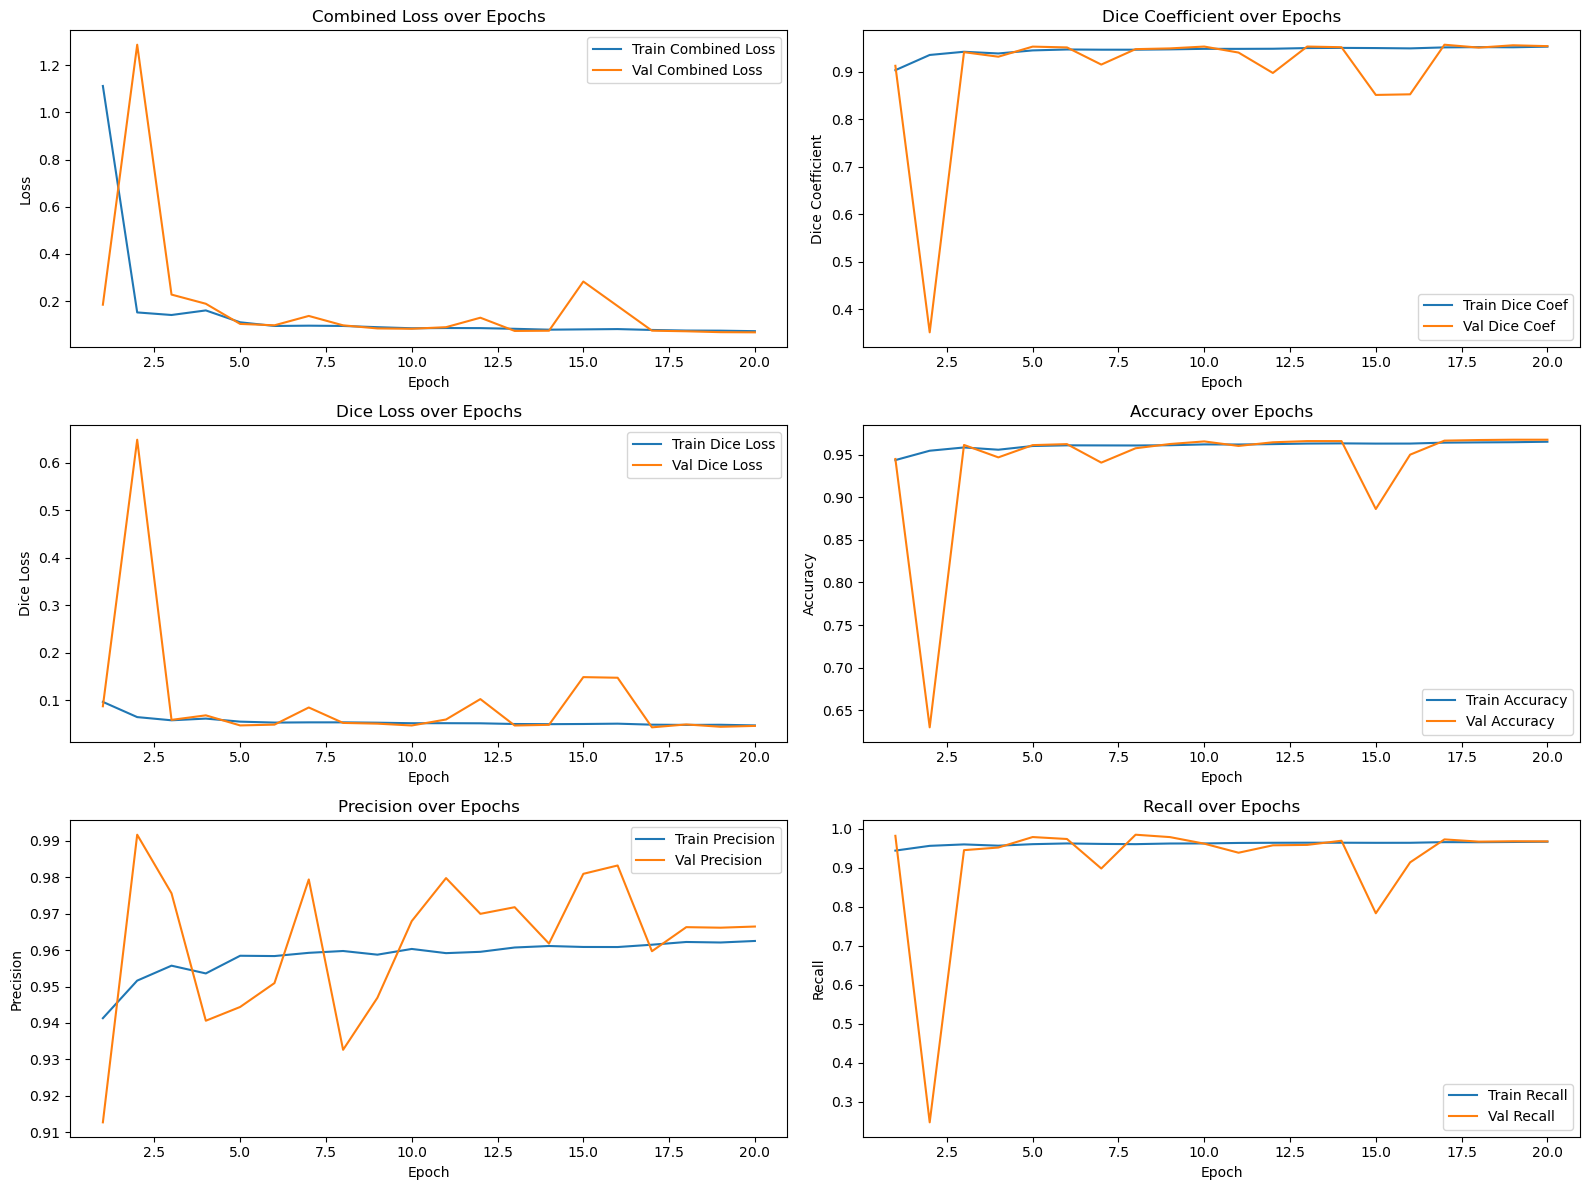


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_04_2025-03-10-18-53\Model_Data
63/63 [==============================] - 15s 237ms/step - loss: 0.0672 - accuracy: 0.9675 - precision: 0.9664 - recall: 0.9681 - dice_coef: 0.9553


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_04
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/b3e7a3c680c947db892291fa66d7b419
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                  : (0.9435644149780273, 0.9651100039482117)
COMET INFO:     batch_accuracy [880]           : (0.48697710037231445, 0.9837195873260498)
COMET INFO:     batch_dice_coef [880]          : (0.4182294011116028, 0.9714749455451965)
COMET INFO:     batch_loss [880]               : (0.040480636060237885, 47.20848846435547)
COMET INFO:     batch_precision [880]          : (0.4231233298778534, 0.9948591589927673)
COMET INFO:     batch_recall [

In [5]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.5, 0.25, 0.25)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_04"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 35.0% low, 50.0% mid, 15.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 35.0% low, 50.0% mid, 15.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 35.0% low, 50.0% mid, 15.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_33 (Conv2D)             (None, 512, 512, 16  432     

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/c5304a78879f4d32a2bcaecee6b30e5e

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.0520 - accuracy: 0.9453 - precision_1: 0.9283 - recall_1: 0.9328 - dice_coef: 0.8713   
Epoch 1: val_loss improved from inf to 0.19485, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 179s 400ms/step - loss: 1.0520 - accuracy: 0.9453 - precision_1: 0.9283 - recall_1: 0.9328 - dice_coef: 0.8713 - val_loss: 0.1949 - val_accuracy: 0.9447 - val_precision_1: 0.9522 - val_recall_1: 0.9051 - val_dice_coef: 0.8963
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1565 - accuracy: 0.9521 - precision_1: 0.9388 - recall_1: 0.9395 - dice_coef: 0.9152  
Epoch 2: val_loss improved from 0.19485 to 0.15799, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras
Epoch 2

C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\unet2.py:253: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2,0].legend()
C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\unet2.py:263: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2,1].legend()


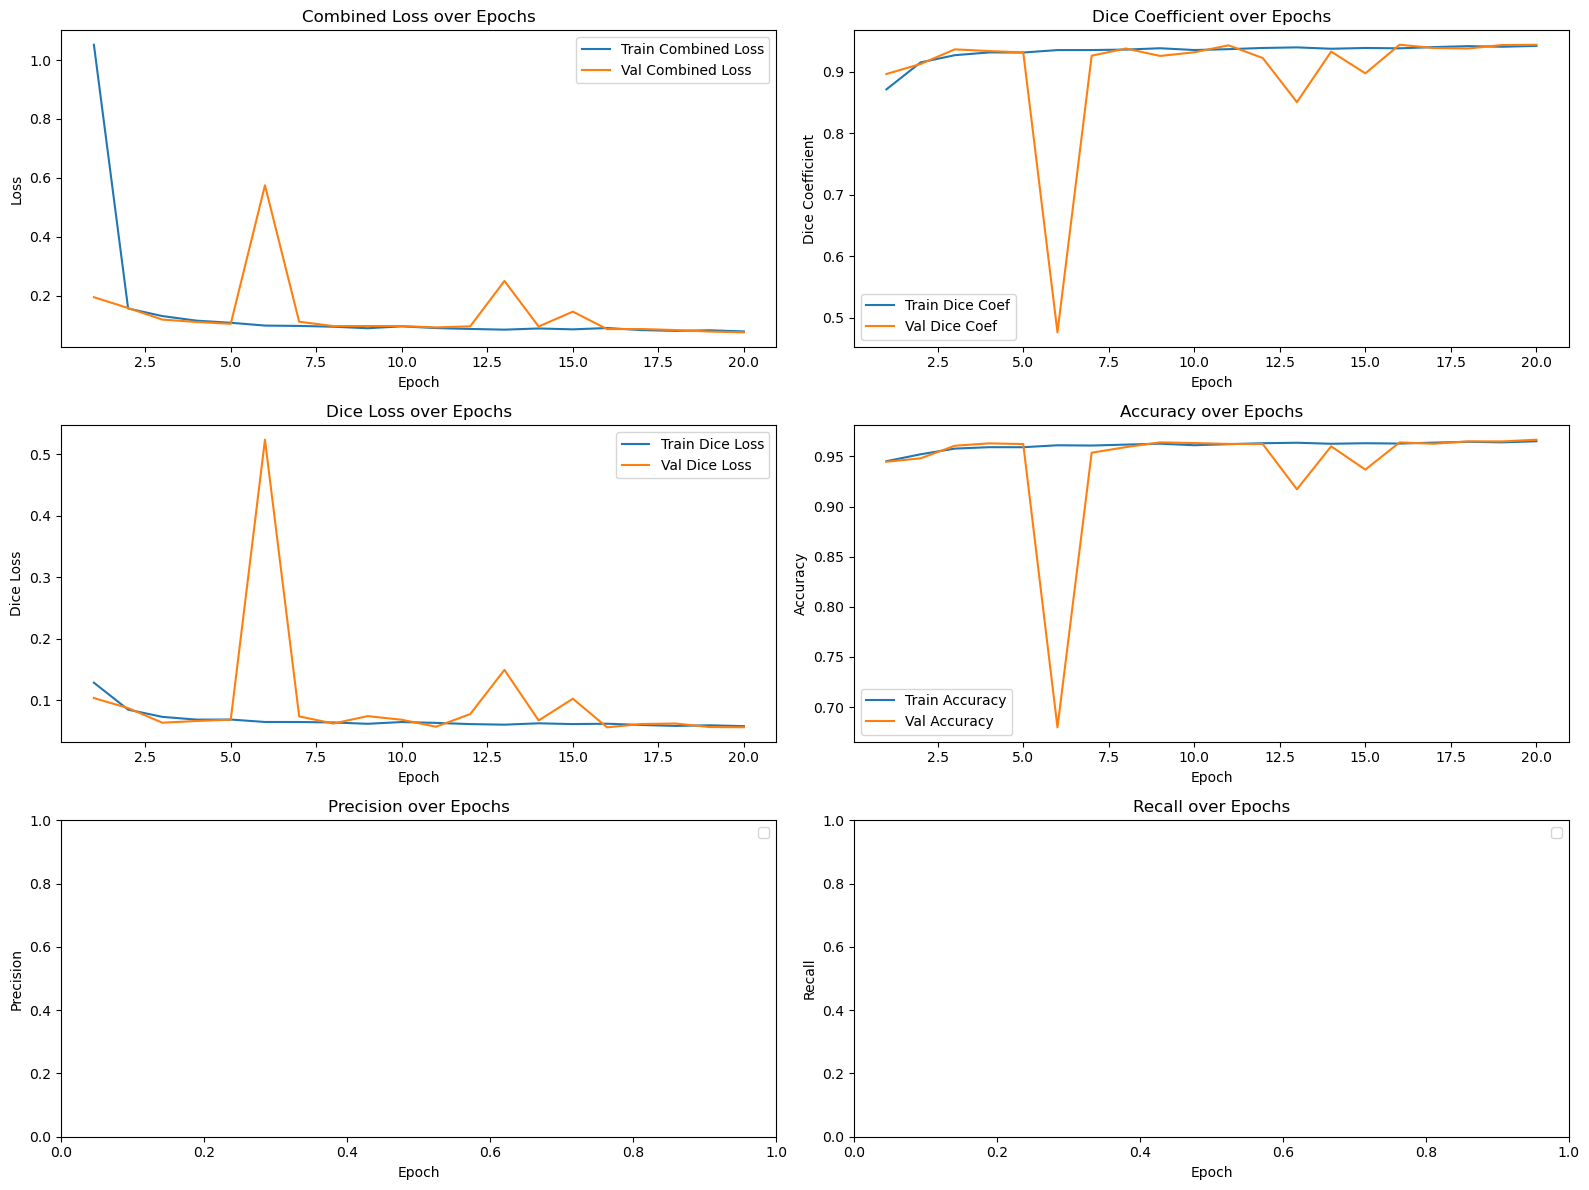


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_04.1_2025-03-10-19-50\Model_Data
63/63 [==============================] - 11s 166ms/step - loss: 0.0716 - accuracy: 0.9679 - precision_1: 0.9538 - recall_1: 0.9663 - dice_coef: 0.9469


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_04.1
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/c5304a78879f4d32a2bcaecee6b30e5e
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.9452547430992126, 0.9651548266410828)
COMET INFO:     batch_accuracy [880]             : (0.5842757225036621, 0.9768412113189697)
COMET INFO:     batch_dice_coef [880]            : (0.38001129031181335, 0.9626938700675964)
COMET INFO:     batch_loss [880]                

In [6]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.5, 0.35, 0.15)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_04.1"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 15.0% low, 50.0% mid, 35.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 15.0% low, 50.0% mid, 35.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 15.0% low, 50.0% mid, 35.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 512, 512, 16  432       

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/daa3ed34bf324c53aaf0ff6c1645c539

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging
COMET INFO: Ignoring automatic log_parameter('verbose') because 'keras:verbose' is in COMET_LOGGING_PARAMETERS_IGNORE


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.0720 - accuracy: 0.9437 - precision: 0.9510 - recall: 0.9531 - dice_coef: 0.9158   
Epoch 1: val_loss improved from inf to 0.29759, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 177s 374ms/step - loss: 1.0720 - accuracy: 0.9437 - precision: 0.9510 - recall: 0.9531 - dice_coef: 0.9158 - val_loss: 0.2976 - val_accuracy: 0.8807 - val_precision: 0.8376 - val_recall: 0.9909 - val_dice_coef: 0.8778
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1460 - accuracy: 0.9547 - precision: 0.9600 - recall: 0.9629 - dice_coef: 0.9451  
Epoch 2: val_loss improved from 0.29759 to 0.18925, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras
Epoch 2: learning_rate 

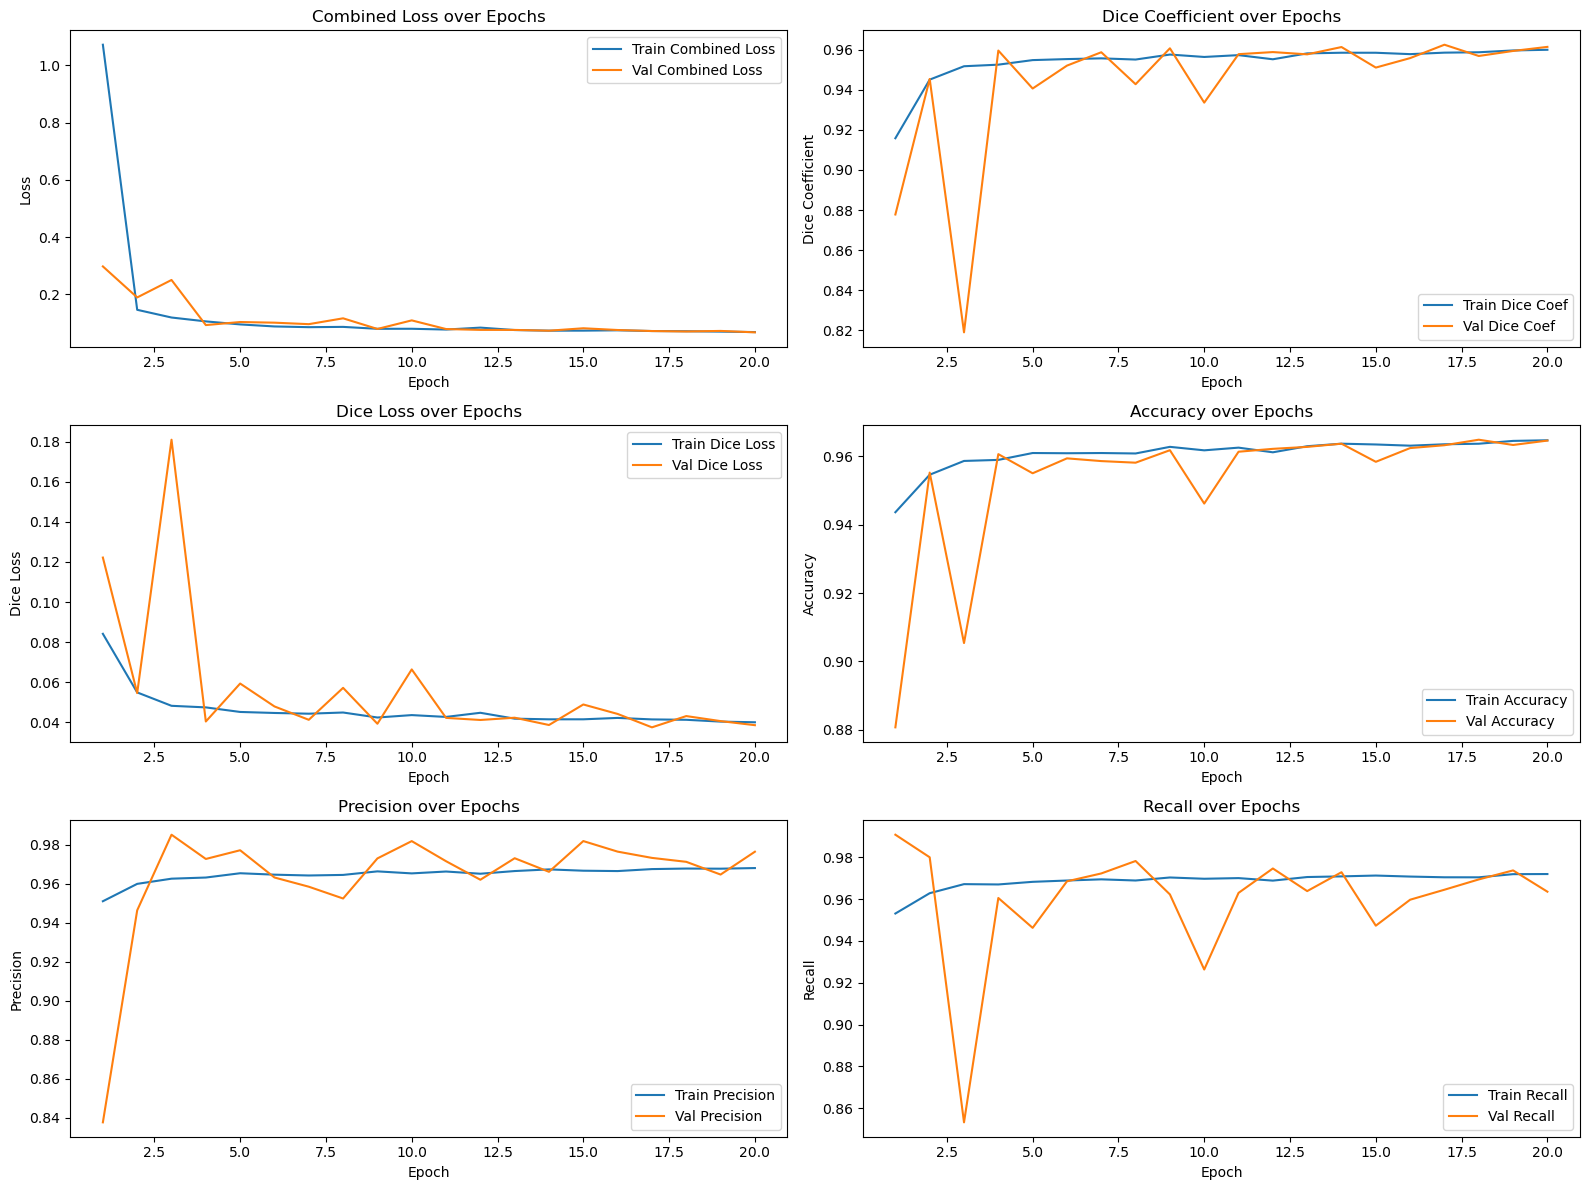


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_04.2_2025-03-10-22-00\Model_Data
63/63 [==============================] - 11s 165ms/step - loss: 0.0706 - accuracy: 0.9631 - precision: 0.9780 - recall: 0.9585 - dice_coef: 0.9588


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_04.2
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/daa3ed34bf324c53aaf0ff6c1645c539
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                  : (0.9436851143836975, 0.9647472500801086)
COMET INFO:     batch_accuracy [880]           : (0.4350864887237549, 0.9796195030212402)
COMET INFO:     batch_dice_coef [880]          : (0.4854882061481476, 0.9751120209693909)
COMET INFO:     batch_loss [880]               : (0.04616915434598923, 47.14089584350586)
COMET INFO:     batch_precision [880]          : (0.4289757013320923, 0.9821797013282776)
COMET INFO:     batch_recall [

In [5]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.5, 0.15, 0.35)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_04.2"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 30.0% low, 40.0% mid, 30.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 30.0% low, 40.0% mid, 30.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 30.0% low, 40.0% mid, 30.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_33 (Conv2D)             (None, 512, 512, 16  432     

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/1282c0b099d642c58cbb8fc389ee2fa8

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.3275 - accuracy: 0.9485 - precision_1: 0.9474 - recall_1: 0.9476 - dice_coef: 0.9070   
Epoch 1: val_loss improved from inf to 0.25118, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 179s 400ms/step - loss: 1.3275 - accuracy: 0.9485 - precision_1: 0.9474 - recall_1: 0.9476 - dice_coef: 0.9070 - val_loss: 0.2512 - val_accuracy: 0.9240 - val_precision_1: 0.8733 - val_recall_1: 0.9881 - val_dice_coef: 0.9116
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1326 - accuracy: 0.9592 - precision_1: 0.9584 - recall_1: 0.9584 - dice_coef: 0.9401  
Epoch 2: val_loss improved from 0.25118 to 0.16318, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras
Epoch 2

C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\unet2.py:253: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2,0].legend()
C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\unet2.py:263: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2,1].legend()


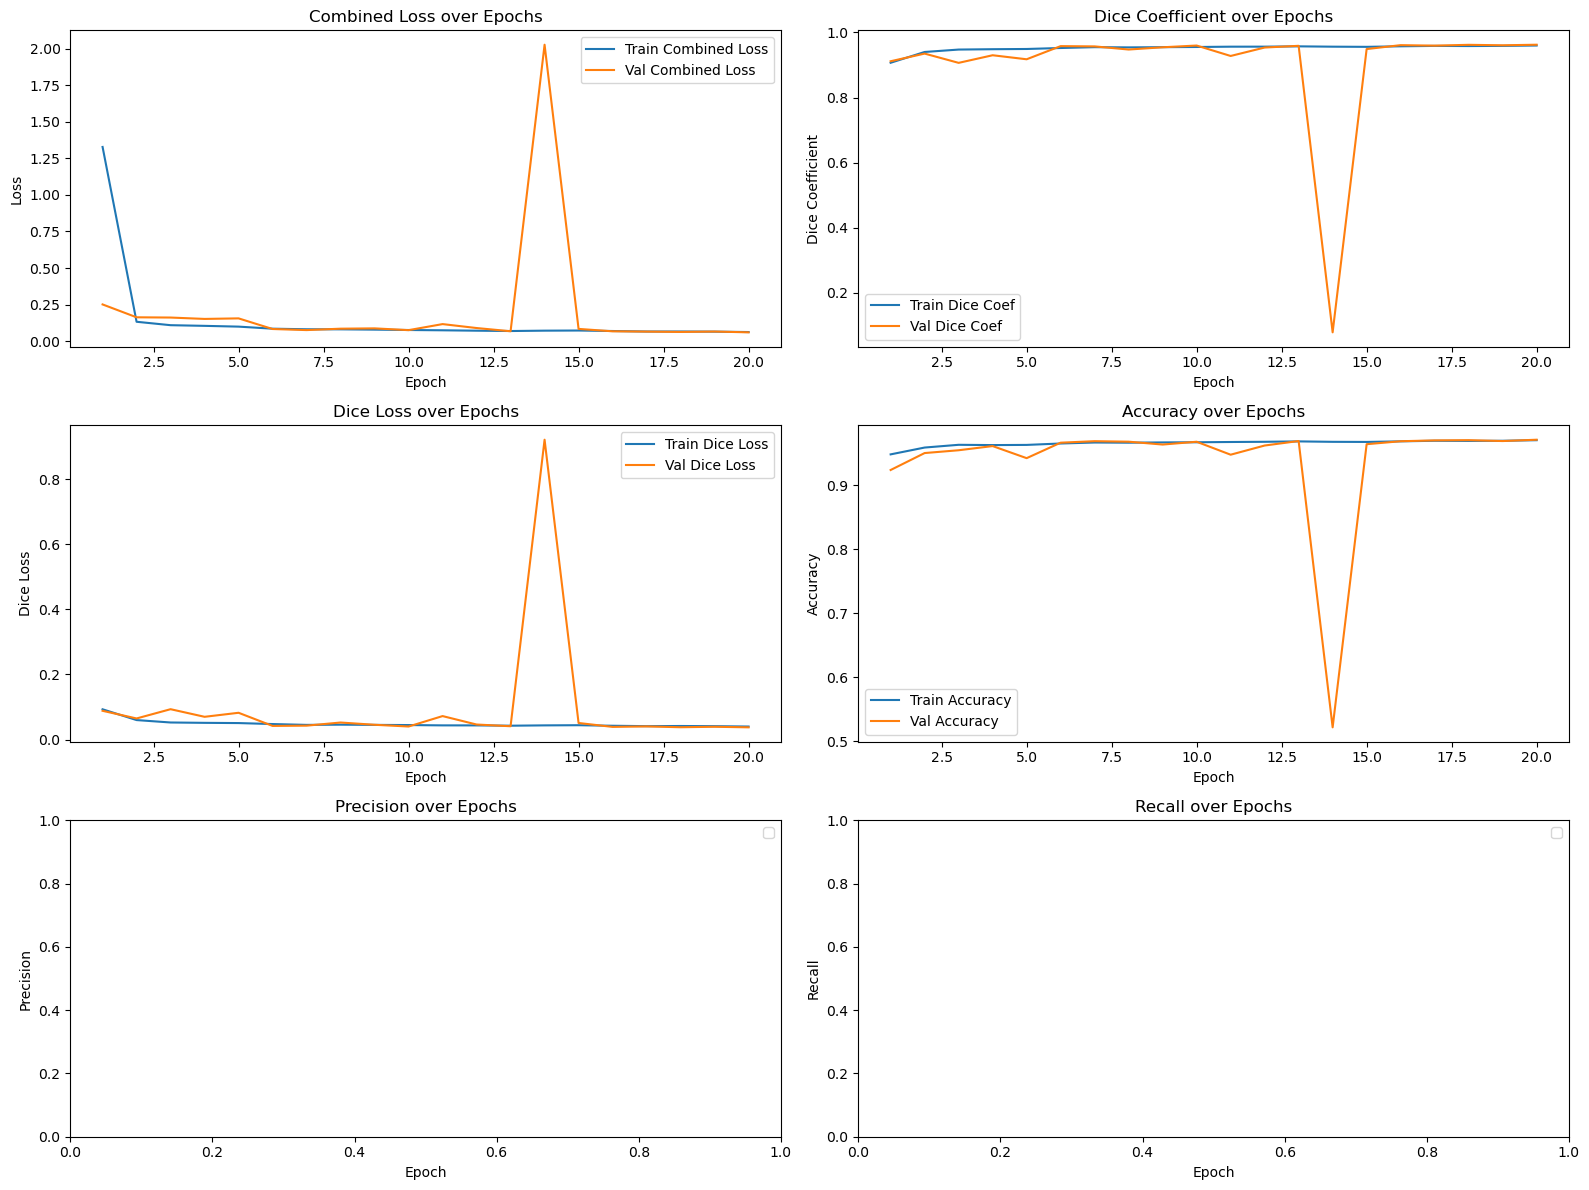


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_04.3_2025-03-10-22-56\Model_Data
63/63 [==============================] - 15s 231ms/step - loss: 0.0583 - accuracy: 0.9725 - precision_1: 0.9718 - recall_1: 0.9729 - dice_coef: 0.9627


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_04.3
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/1282c0b099d642c58cbb8fc389ee2fa8
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.9484766721725464, 0.9706511497497559)
COMET INFO:     batch_accuracy [880]             : (0.6884415149688721, 0.986358642578125)
COMET INFO:     batch_dice_coef [880]            : (0.49413421750068665, 0.9793317914009094)
COMET INFO:     batch_loss [880]                 

In [6]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.4, 0.30, 0.30)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_04.3"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 40.0% low, 40.0% mid, 20.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 40.0% low, 40.0% mid, 20.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 40.0% low, 40.0% mid, 20.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_66 (Conv2D)             (None, 512, 512, 16  432     

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/27ec06e07847401392772acc92ba1c05

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.1988 - accuracy: 0.9513 - precision_2: 0.9359 - recall_2: 0.9408 - dice_coef: 0.8874   
Epoch 1: val_loss improved from inf to 0.24591, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 167s 374ms/step - loss: 1.1988 - accuracy: 0.9513 - precision_2: 0.9359 - recall_2: 0.9408 - dice_coef: 0.8874 - val_loss: 0.2459 - val_accuracy: 0.9155 - val_precision_2: 0.9419 - val_recall_2: 0.8365 - val_dice_coef: 0.8357
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1930 - accuracy: 0.9625 - precision_2: 0.9512 - recall_2: 0.9536 - dice_coef: 0.9316  
Epoch 2: val_loss improved from 0.24591 to 0.20529, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras
Epoch 2

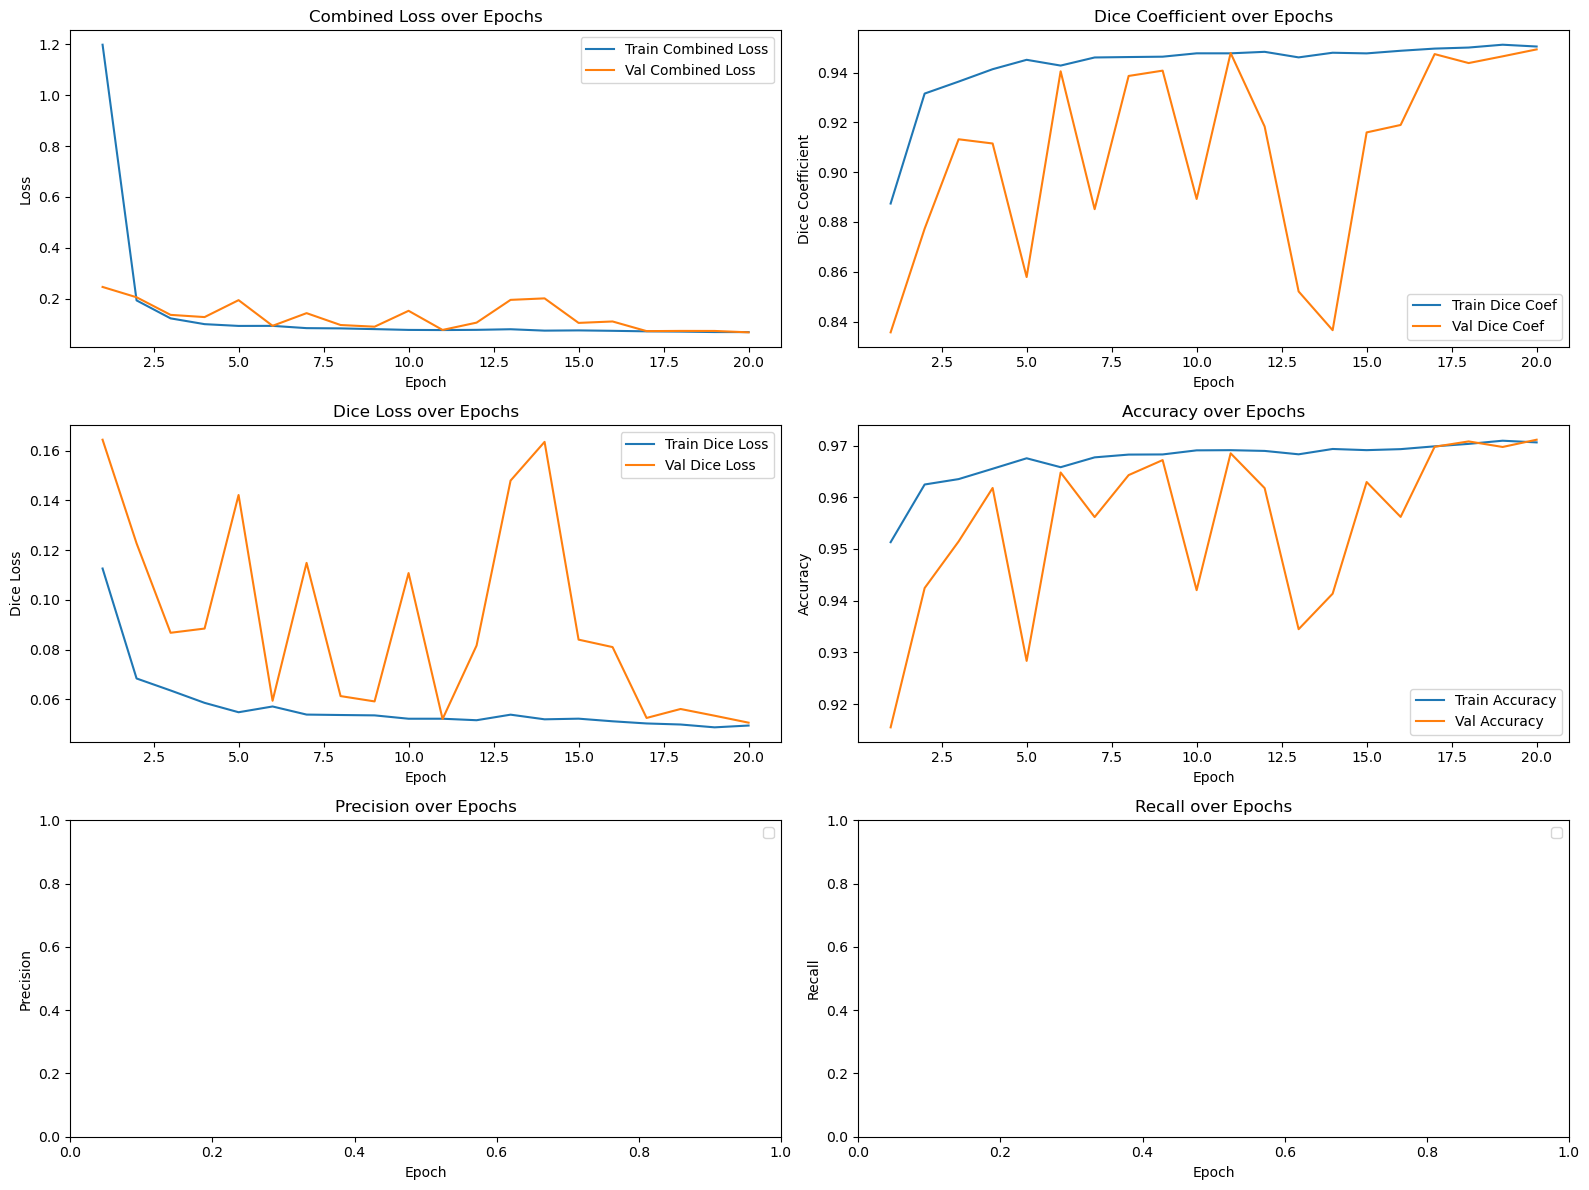


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_04.4_2025-03-10-23-53\Model_Data
63/63 [==============================] - 15s 230ms/step - loss: 0.0642 - accuracy: 0.9724 - precision_2: 0.9699 - recall_2: 0.9613 - dice_coef: 0.9522


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_04.4
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/27ec06e07847401392772acc92ba1c05
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.9513145685195923, 0.9709429740905762)
COMET INFO:     batch_accuracy [880]             : (0.5599408149719238, 0.9820055961608887)
COMET INFO:     batch_dice_coef [880]            : (0.48744985461235046, 0.9728184938430786)
COMET INFO:     batch_loss [880]                

In [7]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.4, 0.40, 0.20)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_04.4"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 20.0% low, 40.0% mid, 40.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 20.0% low, 40.0% mid, 40.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 20.0% low, 40.0% mid, 40.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_99 (Conv2D)             (None, 512, 512, 16  432     

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/2c33384863a84fc586fb1713a504c32a

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.1112 - accuracy: 0.9446 - precision_3: 0.9520 - recall_3: 0.9537 - dice_coef: 0.9096   
Epoch 1: val_loss improved from inf to 0.14640, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 167s 374ms/step - loss: 1.1112 - accuracy: 0.9446 - precision_3: 0.9520 - recall_3: 0.9537 - dice_coef: 0.9096 - val_loss: 0.1464 - val_accuracy: 0.9551 - val_precision_3: 0.9622 - val_recall_3: 0.9613 - val_dice_coef: 0.9377
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1330 - accuracy: 0.9574 - precision_3: 0.9650 - recall_3: 0.9623 - dice_coef: 0.9474  
Epoch 2: val_loss did not improve from 0.14640
Epoch 2: learning_rate = 0.000954
438/438 [==============================] - 163s 372ms/step - loss: 0.1330 - accuracy: 0.9574 - precision_3: 0.9650 - re

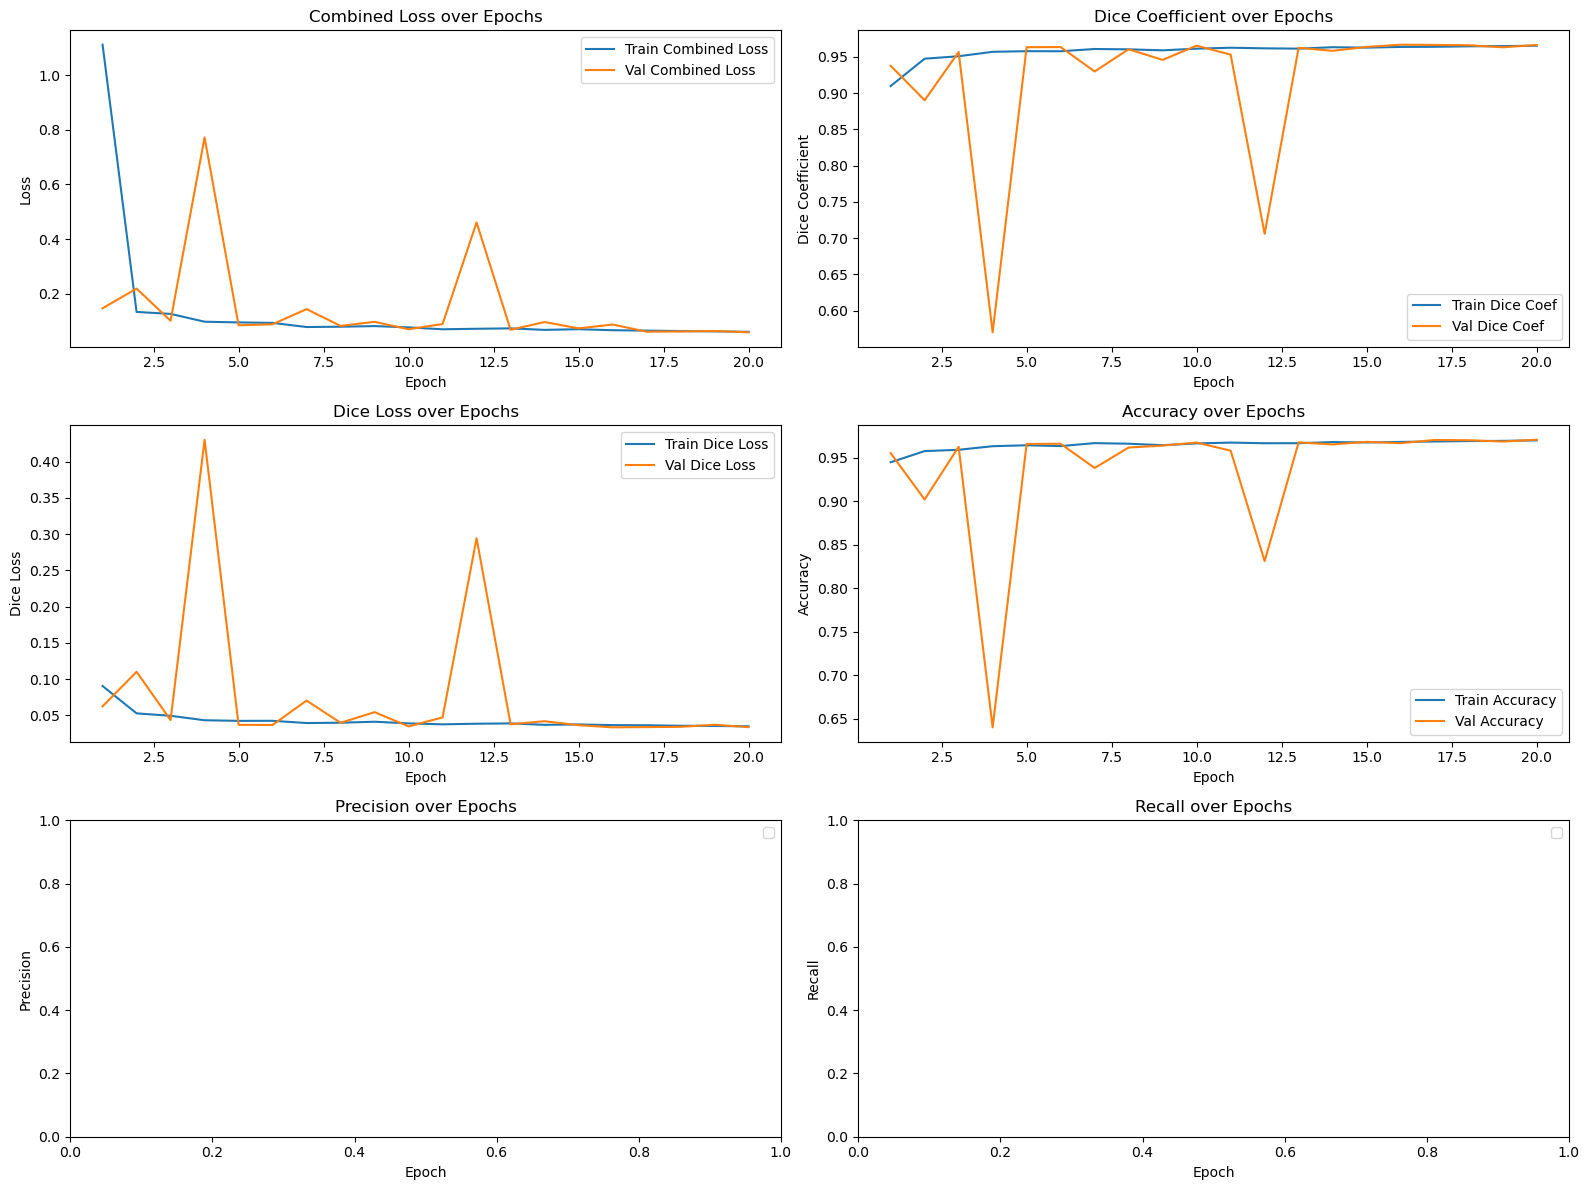


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_04.5_2025-03-11-00-50\Model_Data
63/63 [==============================] - 11s 174ms/step - loss: 0.0574 - accuracy: 0.9705 - precision_3: 0.9781 - recall_3: 0.9721 - dice_coef: 0.9667


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_04.5
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/2c33384863a84fc586fb1713a504c32a
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.9445527195930481, 0.969696044921875)
COMET INFO:     batch_accuracy [880]             : (0.6714694499969482, 0.9875996112823486)
COMET INFO:     batch_dice_coef [880]            : (0.6735392212867737, 0.9857943654060364)
COMET INFO:     batch_loss [880]                 :

In [8]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.4, 0.20, 0.40)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_04.5"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 20.0% low, 60.0% mid, 20.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 20.0% low, 60.0% mid, 20.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 20.0% low, 60.0% mid, 20.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_132 (Conv2D)            (None, 512, 512, 16  432     

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/1aa9ba70b5d84ca1891a8af614855849

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.0722 - accuracy: 0.9414 - precision_4: 0.9372 - recall_4: 0.9439 - dice_coef: 0.8927   
Epoch 1: val_loss improved from inf to 0.32109, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 167s 374ms/step - loss: 1.0722 - accuracy: 0.9414 - precision_4: 0.9372 - recall_4: 0.9439 - dice_coef: 0.8927 - val_loss: 0.3211 - val_accuracy: 0.9224 - val_precision_4: 0.9794 - val_recall_4: 0.8596 - val_dice_coef: 0.8963
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1419 - accuracy: 0.9520 - precision_4: 0.9489 - recall_4: 0.9537 - dice_coef: 0.9321  
Epoch 2: val_loss improved from 0.32109 to 0.18081, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras
Epoch 2

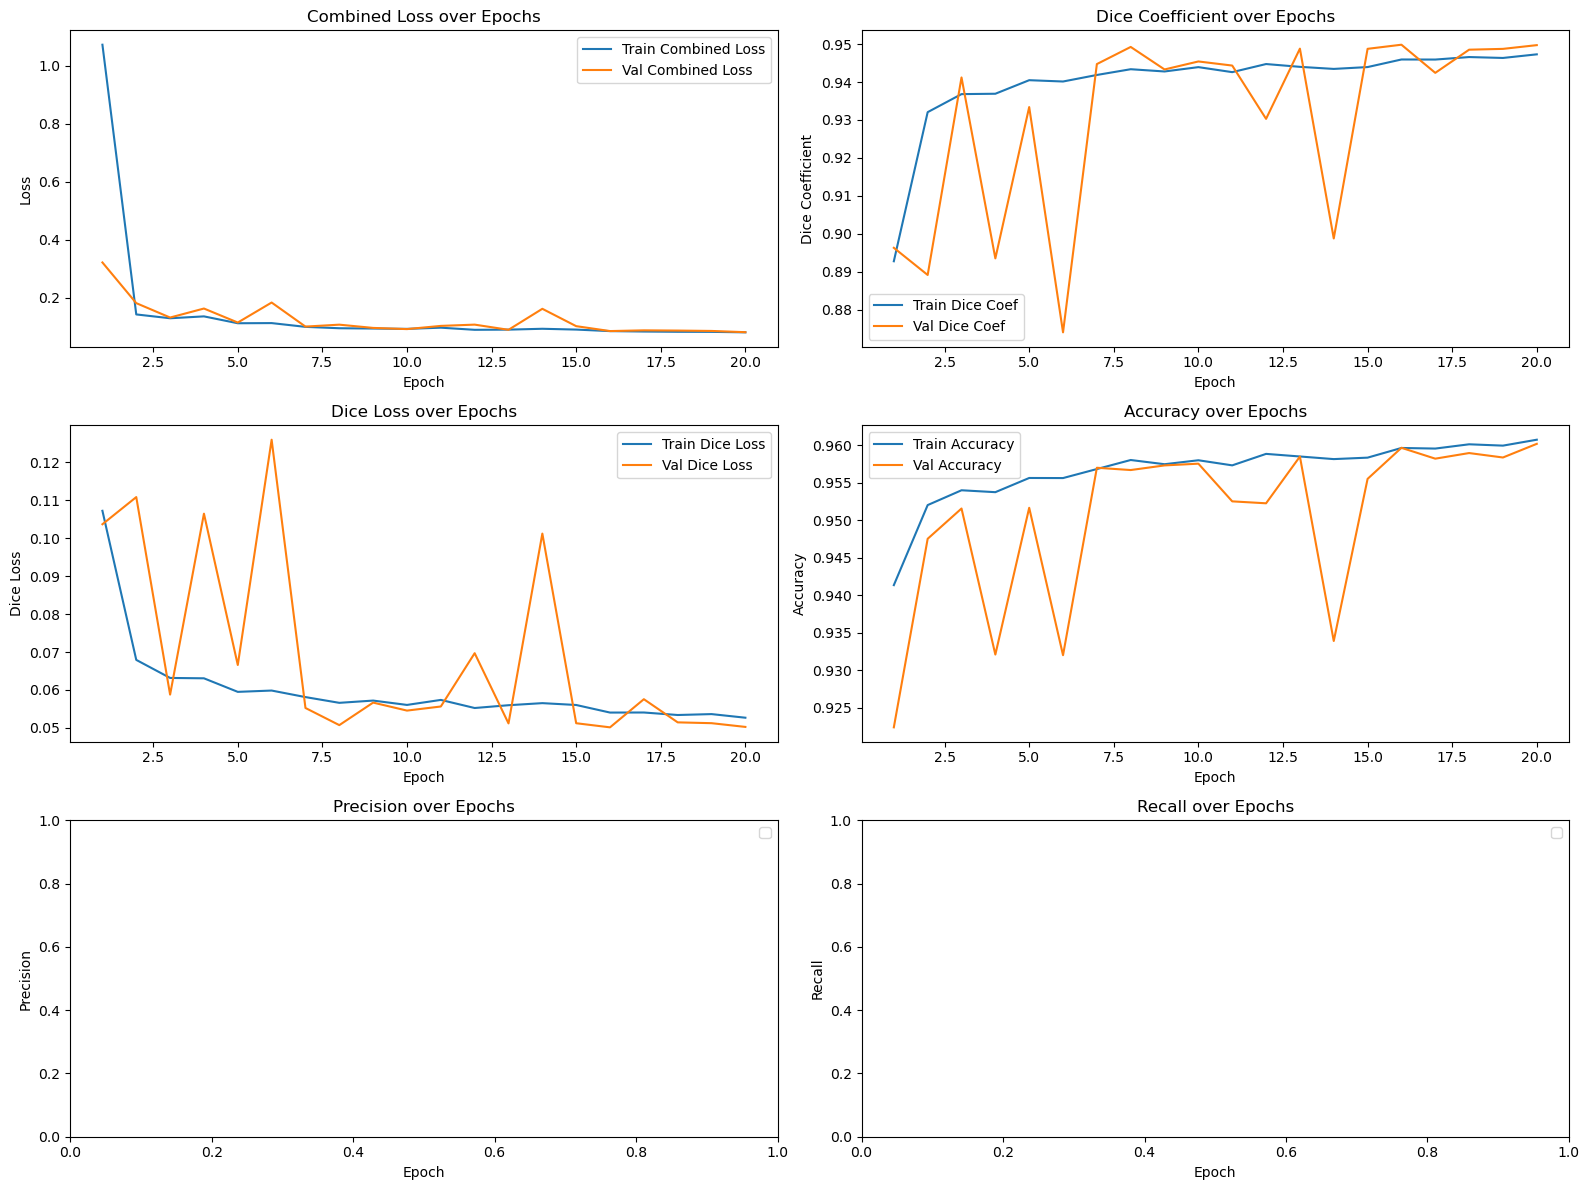


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_04.6_2025-03-11-01-46\Model_Data
63/63 [==============================] - 11s 164ms/step - loss: 0.0723 - accuracy: 0.9645 - precision_4: 0.9648 - recall_4: 0.9623 - dice_coef: 0.9535


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_04.6
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/1aa9ba70b5d84ca1891a8af614855849
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.941362202167511, 0.9607470035552979)
COMET INFO:     batch_accuracy [880]             : (0.30283331871032715, 0.985175371170044)
COMET INFO:     batch_dice_coef [880]            : (0.34038713574409485, 0.9710136651992798)
COMET INFO:     batch_loss [880]                 

In [9]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.6, 0.20, 0.20)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_04.6"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 30.0% low, 60.0% mid, 10.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 30.0% low, 60.0% mid, 10.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 30.0% low, 60.0% mid, 10.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_165 (Conv2D)            (None, 512, 512, 16  432     

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/490cfe25b9274c35b6eb0276519e6240

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.1038 - accuracy: 0.9433 - precision_5: 0.9218 - recall_5: 0.9357 - dice_coef: 0.8742   
Epoch 1: val_loss improved from inf to 0.18531, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 167s 374ms/step - loss: 1.1038 - accuracy: 0.9433 - precision_5: 0.9218 - recall_5: 0.9357 - dice_coef: 0.8742 - val_loss: 0.1853 - val_accuracy: 0.9491 - val_precision_5: 0.9272 - val_recall_5: 0.9448 - val_dice_coef: 0.8888
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1548 - accuracy: 0.9526 - precision_5: 0.9376 - recall_5: 0.9425 - dice_coef: 0.9169  
Epoch 2: val_loss improved from 0.18531 to 0.14068, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras
Epoch 2

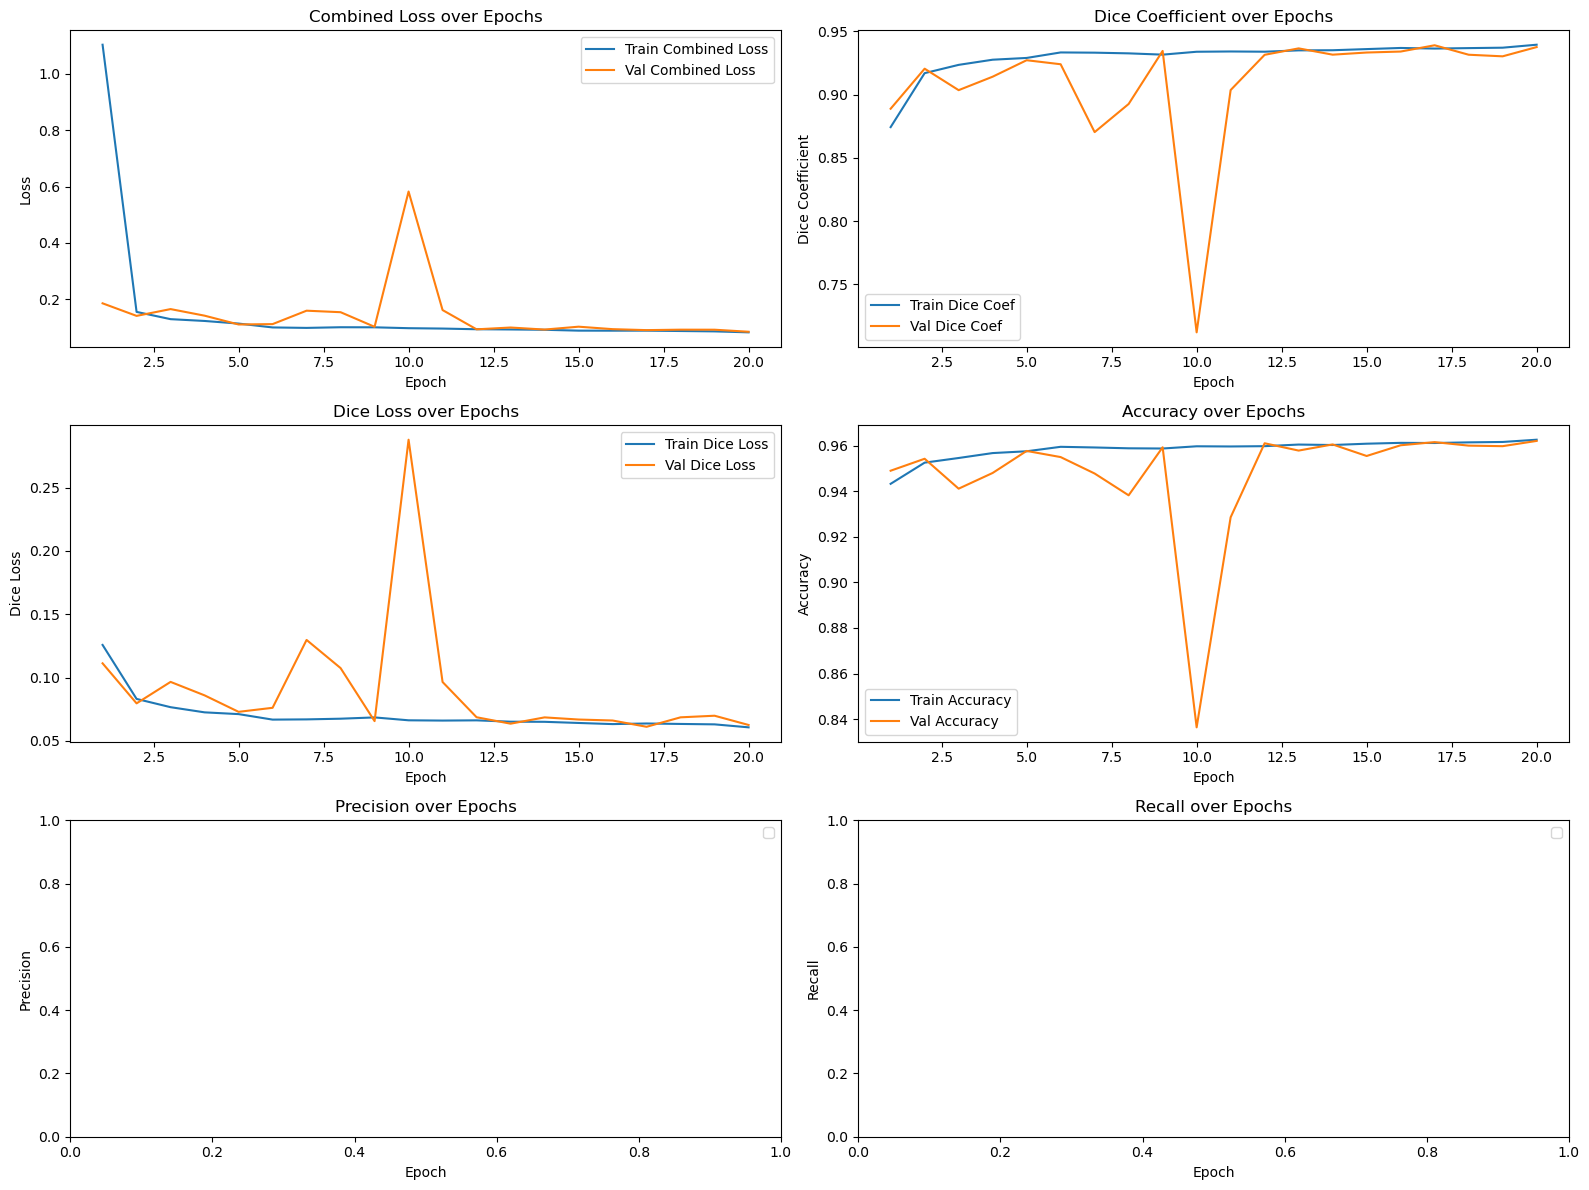


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_04.7_2025-03-11-02-42\Model_Data
63/63 [==============================] - 10s 161ms/step - loss: 0.0824 - accuracy: 0.9630 - precision_5: 0.9634 - recall_5: 0.9403 - dice_coef: 0.9378


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_04.7
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/490cfe25b9274c35b6eb0276519e6240
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.9433267116546631, 0.9626989960670471)
COMET INFO:     batch_accuracy [880]             : (0.5614504814147949, 0.9757261276245117)
COMET INFO:     batch_dice_coef [880]            : (0.4819491505622864, 0.9605625867843628)
COMET INFO:     batch_loss [880]                 

In [10]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.6, 0.30, 0.10)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_04.7"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 10.0% low, 60.0% mid, 30.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 10.0% low, 60.0% mid, 30.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 10.0% low, 60.0% mid, 30.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_6"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_7 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_198 (Conv2D)            (None, 512, 512, 16  432     

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/fc8123dd61a64e94a63ede6fb459a9f7

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.0458 - accuracy: 0.9433 - precision_6: 0.9439 - recall_6: 0.9607 - dice_coef: 0.9054   
Epoch 1: val_loss improved from inf to 0.16854, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 168s 375ms/step - loss: 1.0458 - accuracy: 0.9433 - precision_6: 0.9439 - recall_6: 0.9607 - dice_coef: 0.9054 - val_loss: 0.1685 - val_accuracy: 0.9345 - val_precision_6: 0.9142 - val_recall_6: 0.9805 - val_dice_coef: 0.9217
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1503 - accuracy: 0.9501 - precision_6: 0.9533 - recall_6: 0.9623 - dice_coef: 0.9395  
Epoch 2: val_loss did not improve from 0.16854
Epoch 2: learning_rate = 0.000954
438/438 [==============================] - 164s 373ms/step - loss: 0.1503 - accuracy: 0.9501 - precision_6: 0.9533 - re

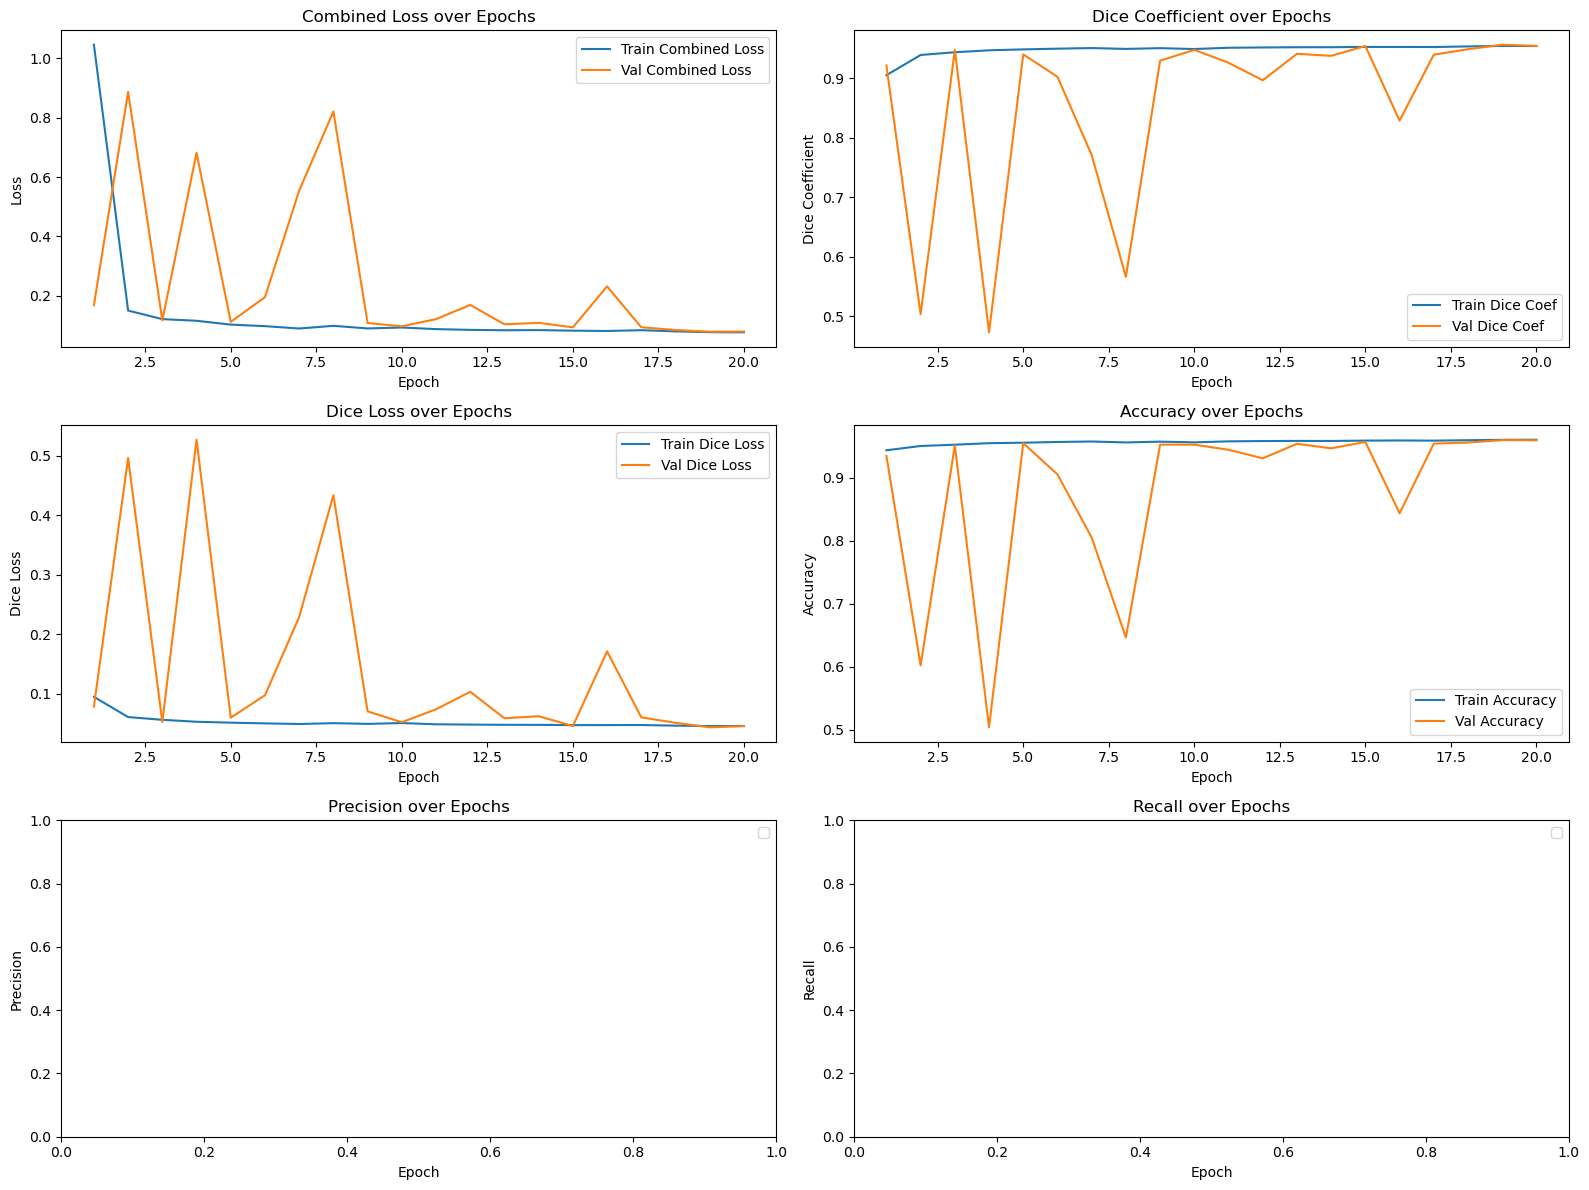


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_04.8_2025-03-11-03-38\Model_Data
63/63 [==============================] - 12s 187ms/step - loss: 0.0736 - accuracy: 0.9621 - precision_6: 0.9764 - recall_6: 0.9582 - dice_coef: 0.9577


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_04.8
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/fc8123dd61a64e94a63ede6fb459a9f7
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.9433299899101257, 0.960038959980011)
COMET INFO:     batch_accuracy [880]             : (0.6486287117004395, 0.9721002578735352)
COMET INFO:     batch_dice_coef [880]            : (0.6351046562194824, 0.9685900807380676)
COMET INFO:     batch_loss [880]                 :

In [11]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.6, 0.10, 0.30)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_04.8"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)

In [4]:
#DATA SPLIT
folder_path = r"C:\Users\jaydb\Snowpack_Project\Tiled_Output"
sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy"]
snow_vs_notsnow_ratio_distribution = (0.7, 0.3) 

# Aggregate tile pairs from all provided sites.
all_tile_pairs = aggregate_tile_pairs(sites, folder_path)
print(f"Total aggregated tile pairs: {len(all_tile_pairs)}")
    
# Bin tile pairs into low, mid, and high categories.
low_bin, mid_bin, high_bin = bin_tile_pairs(all_tile_pairs, snow_vs_notsnow_ratio_distribution)
print(f"Tiles with {snow_vs_notsnow_ratio_distribution[1] * 100}% or less snow pixels (low): {len(low_bin)}")
print(f"Tiles with {snow_vs_notsnow_ratio_distribution[1] * 100}% to {snow_vs_notsnow_ratio_distribution[0] * 100}% snow pixels (mid): {len(mid_bin)}")
print(f"Tiles with {snow_vs_notsnow_ratio_distribution[0] * 100}% or more snow pixels (high): {len(high_bin)}")

Total aggregated tile pairs: 118039
Tiles with 30.0% or less snow pixels (low): 88458
Tiles with 30.0% to 70.0% snow pixels (mid): 7348
Tiles with 70.0% or more snow pixels (high): 22233



Sampling training with 25.0% low, 50.0% mid, 25.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 25.0% low, 50.0% mid, 25.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 25.0% low, 50.0% mid, 25.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_7"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_8 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_231 (Conv2D)            (None, 512, 512, 16  432     

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/31ad35ca9ddb49a49a6cfc96a3dce387

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.1649 - accuracy: 0.9415 - precision_7: 0.9425 - recall_7: 0.9376 - dice_coef: 0.8807   
Epoch 1: val_loss improved from inf to 0.23787, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 167s 374ms/step - loss: 1.1649 - accuracy: 0.9415 - precision_7: 0.9425 - recall_7: 0.9376 - dice_coef: 0.8807 - val_loss: 0.2379 - val_accuracy: 0.9516 - val_precision_7: 0.9728 - val_recall_7: 0.9266 - val_dice_coef: 0.9047
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1656 - accuracy: 0.9496 - precision_7: 0.9465 - recall_7: 0.9507 - dice_coef: 0.9258  
Epoch 2: val_loss did not improve from 0.23787
Epoch 2: learning_rate = 0.000954
438/438 [==============================] - 163s 372ms/step - loss: 0.1656 - accuracy: 0.9496 - precision_7: 0.9465 - re

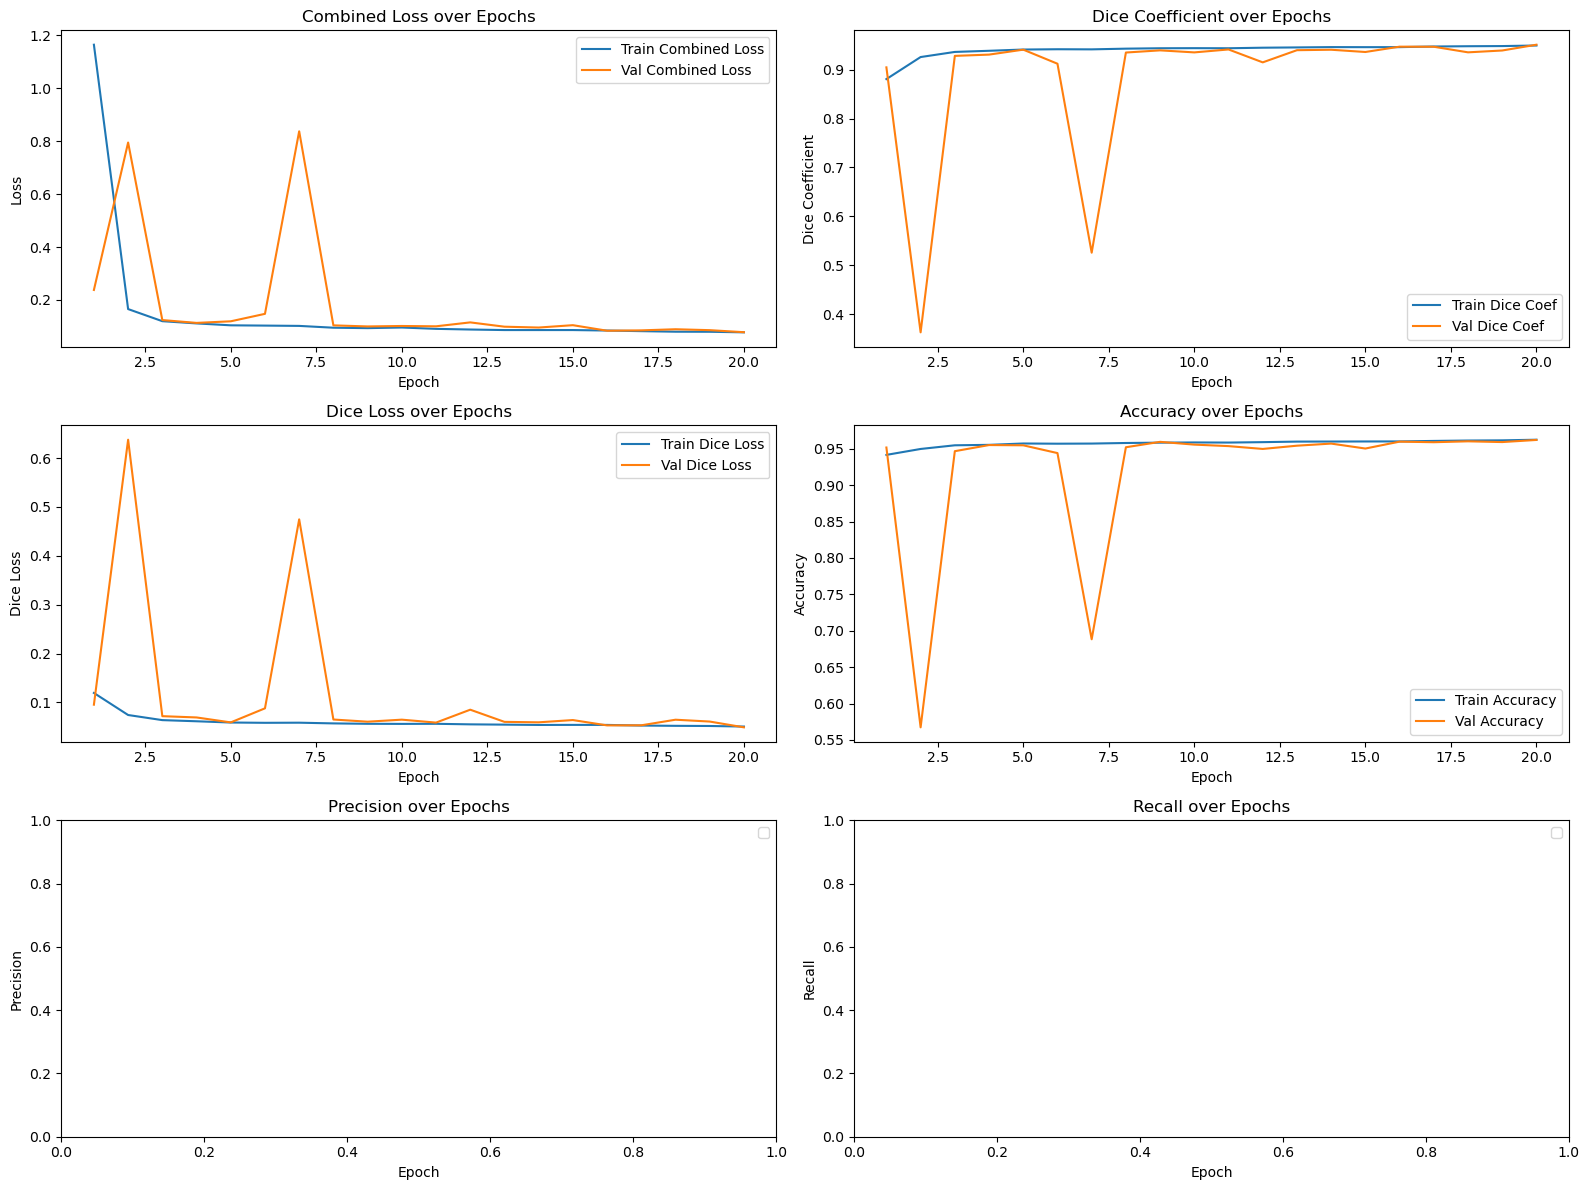


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_05_2025-03-11-04-44\Model_Data
63/63 [==============================] - 11s 174ms/step - loss: 0.0816 - accuracy: 0.9597 - precision_7: 0.9477 - recall_7: 0.9708 - dice_coef: 0.9488


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_05
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/31ad35ca9ddb49a49a6cfc96a3dce387
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.9414839148521423, 0.9623210430145264)
COMET INFO:     batch_accuracy [880]             : (0.5739142894744873, 0.9815831184387207)
COMET INFO:     batch_dice_coef [880]            : (0.3750999867916107, 0.9640284180641174)
COMET INFO:     batch_loss [880]                 : 

In [13]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.5, 0.25, 0.25)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_05"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 35.0% low, 50.0% mid, 15.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 35.0% low, 50.0% mid, 15.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 35.0% low, 50.0% mid, 15.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_8"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_9 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_264 (Conv2D)            (None, 512, 512, 16  432     

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/0b7d84def06f49619b658f8a0d7cdab9

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.1880 - accuracy: 0.9460 - precision_8: 0.9301 - recall_8: 0.9336 - dice_coef: 0.8977   
Epoch 1: val_loss improved from inf to 0.18845, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 167s 373ms/step - loss: 1.1880 - accuracy: 0.9460 - precision_8: 0.9301 - recall_8: 0.9336 - dice_coef: 0.8977 - val_loss: 0.1885 - val_accuracy: 0.9494 - val_precision_8: 0.9134 - val_recall_8: 0.9637 - val_dice_coef: 0.8691
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1607 - accuracy: 0.9528 - precision_8: 0.9359 - recall_8: 0.9453 - dice_coef: 0.9188  
Epoch 2: val_loss improved from 0.18845 to 0.14243, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras
Epoch 2

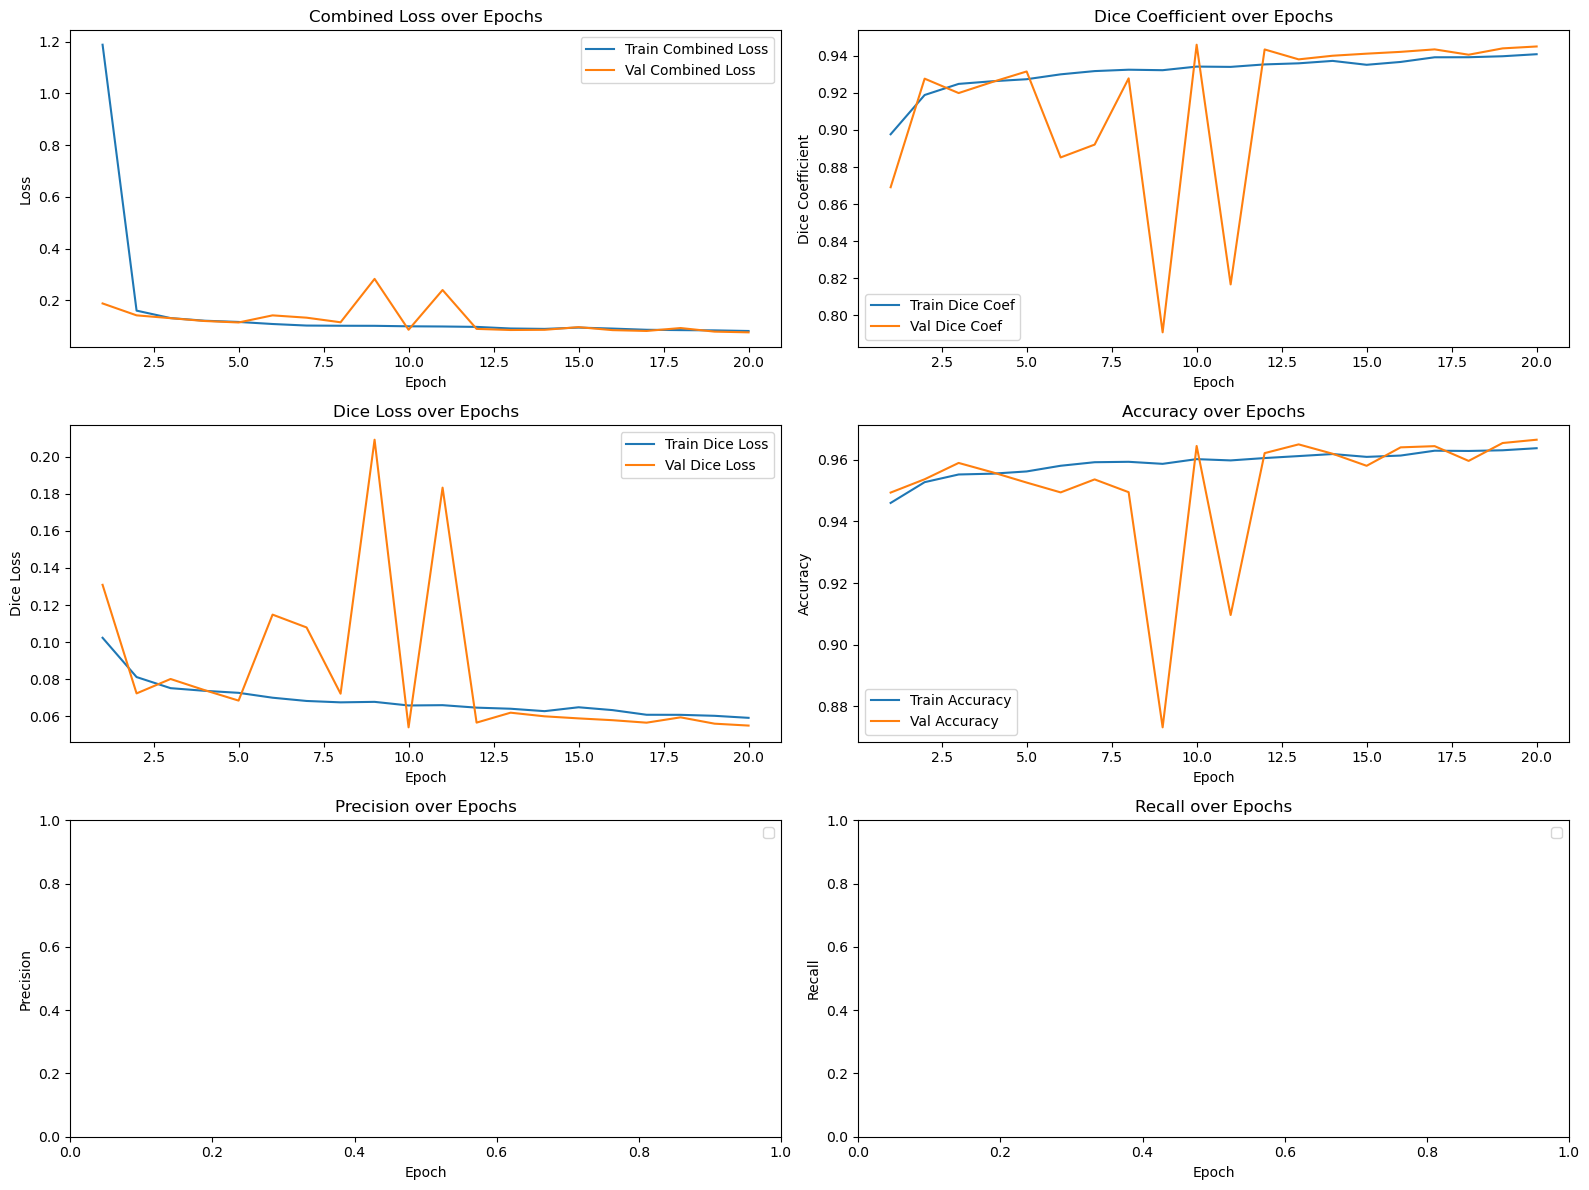


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_05.1_2025-03-11-05-40\Model_Data
63/63 [==============================] - 13s 211ms/step - loss: 0.0810 - accuracy: 0.9644 - precision_8: 0.9528 - recall_8: 0.9559 - dice_coef: 0.9412


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_05.1
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/0b7d84def06f49619b658f8a0d7cdab9
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.9460188746452332, 0.9637994170188904)
COMET INFO:     batch_accuracy [880]             : (0.587348222732544, 0.9708974361419678)
COMET INFO:     batch_dice_coef [880]            : (0.4773414134979248, 0.9542399048805237)
COMET INFO:     batch_loss [880]                 :

In [14]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.5, 0.35, 0.15)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_05.1"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 15.0% low, 50.0% mid, 35.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 15.0% low, 50.0% mid, 35.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 15.0% low, 50.0% mid, 35.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_9"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_10 (InputLayer)          [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_297 (Conv2D)            (None, 512, 512, 16  432     

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/d1b961d9f1c24053b3ab14ec8dedf4e2

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.0680 - accuracy: 0.9400 - precision_9: 0.9474 - recall_9: 0.9498 - dice_coef: 0.9141   
Epoch 1: val_loss improved from inf to 0.44657, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 166s 372ms/step - loss: 1.0680 - accuracy: 0.9400 - precision_9: 0.9474 - recall_9: 0.9498 - dice_coef: 0.9141 - val_loss: 0.4466 - val_accuracy: 0.8718 - val_precision_9: 0.8300 - val_recall_9: 0.9811 - val_dice_coef: 0.8641
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1439 - accuracy: 0.9500 - precision_9: 0.9544 - recall_9: 0.9602 - dice_coef: 0.9401  
Epoch 2: val_loss improved from 0.44657 to 0.26100, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras
Epoch 2

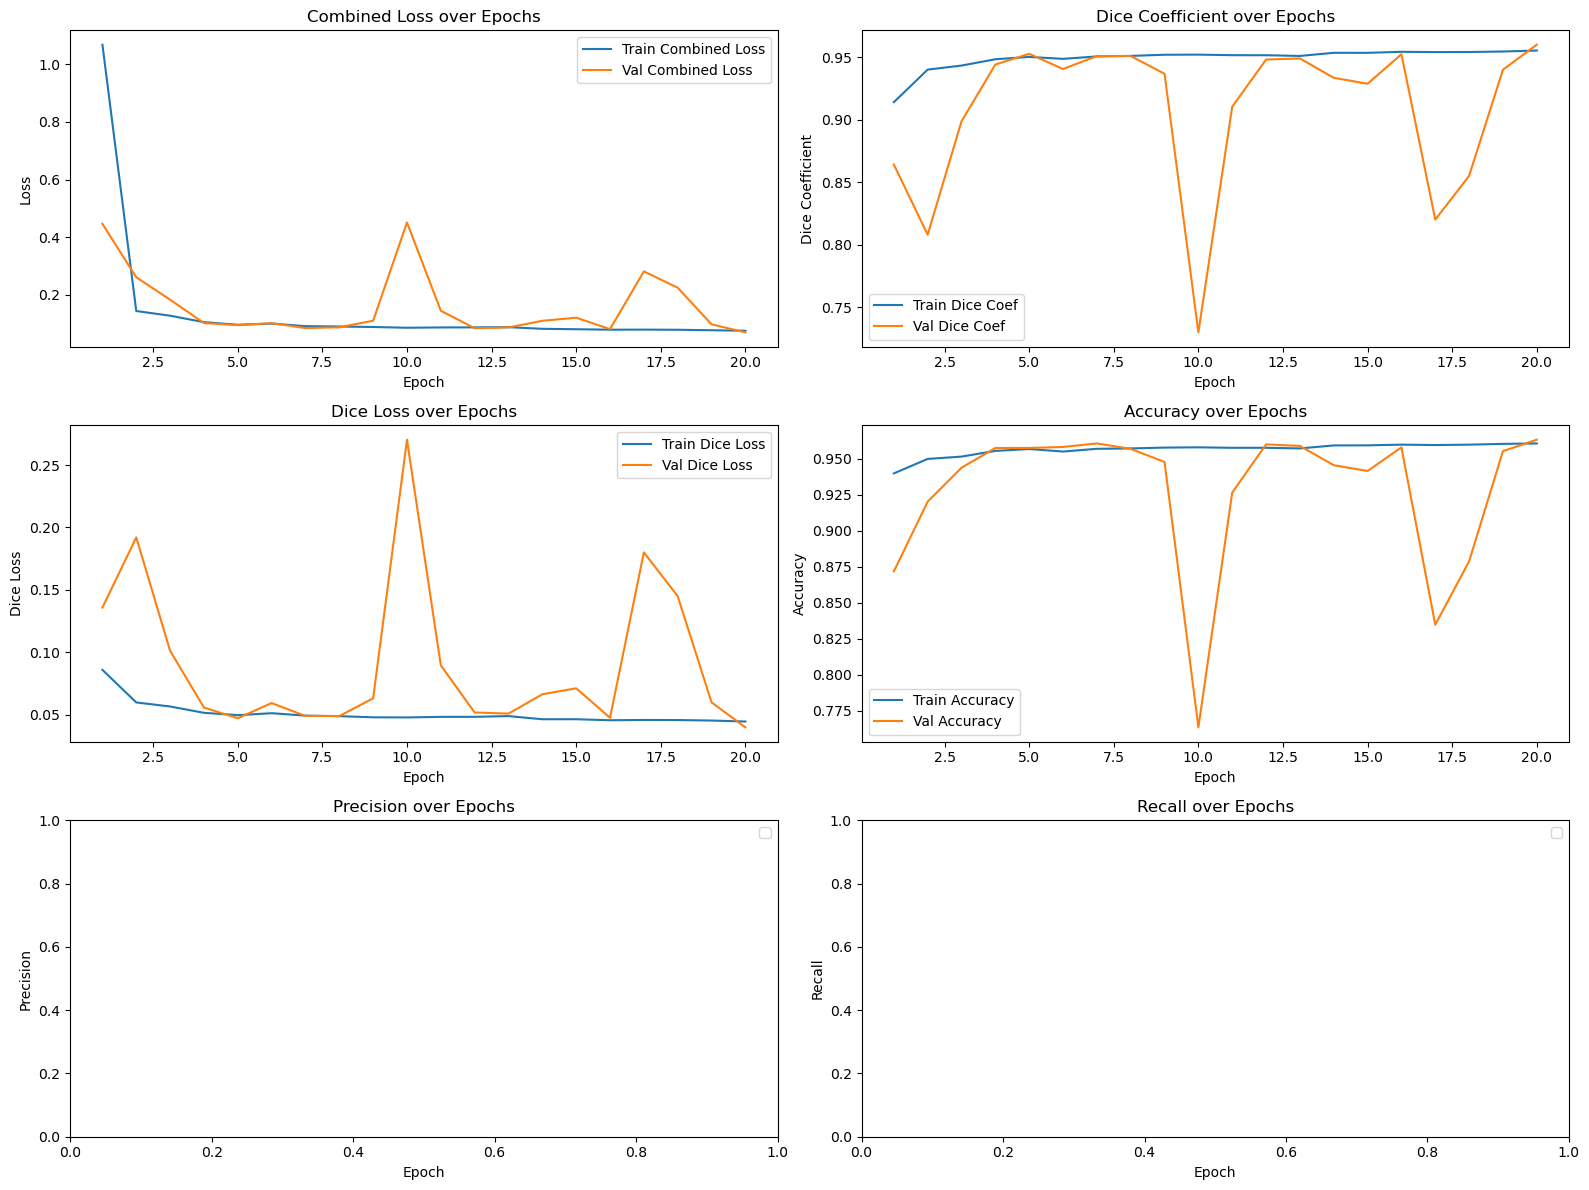


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_05.2_2025-03-11-06-36\Model_Data
63/63 [==============================] - 10s 153ms/step - loss: 0.0745 - accuracy: 0.9607 - precision_9: 0.9662 - recall_9: 0.9661 - dice_coef: 0.9572


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_05.2
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/d1b961d9f1c24053b3ab14ec8dedf4e2
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.9399714469909668, 0.9608149528503418)
COMET INFO:     batch_accuracy [880]             : (0.6154017448425293, 0.9836642742156982)
COMET INFO:     batch_dice_coef [880]            : (0.5100915431976318, 0.9813280701637268)
COMET INFO:     batch_loss [880]                 

In [15]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.5, 0.15, 0.35)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_05.2"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 30.0% low, 40.0% mid, 30.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 30.0% low, 40.0% mid, 30.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 30.0% low, 40.0% mid, 30.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_10"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_11 (InputLayer)          [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_330 (Conv2D)            (None, 512, 512, 16  432    

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/f951829218e54026af0953843fdaf524

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.1082 - accuracy: 0.9464 - precision_10: 0.9457 - recall_10: 0.9441 - dice_coef: 0.9026   
Epoch 1: val_loss improved from inf to 0.16864, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 167s 374ms/step - loss: 1.1082 - accuracy: 0.9464 - precision_10: 0.9457 - recall_10: 0.9441 - dice_coef: 0.9026 - val_loss: 0.1686 - val_accuracy: 0.9624 - val_precision_10: 0.9598 - val_recall_10: 0.9637 - val_dice_coef: 0.8927
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1339 - accuracy: 0.9567 - precision_10: 0.9531 - recall_10: 0.9582 - dice_coef: 0.9372  
Epoch 2: val_loss did not improve from 0.16864
Epoch 2: learning_rate = 0.000954
438/438 [==============================] - 161s 368ms/step - loss: 0.1339 - accuracy: 0.9567 - precision_10: 0.

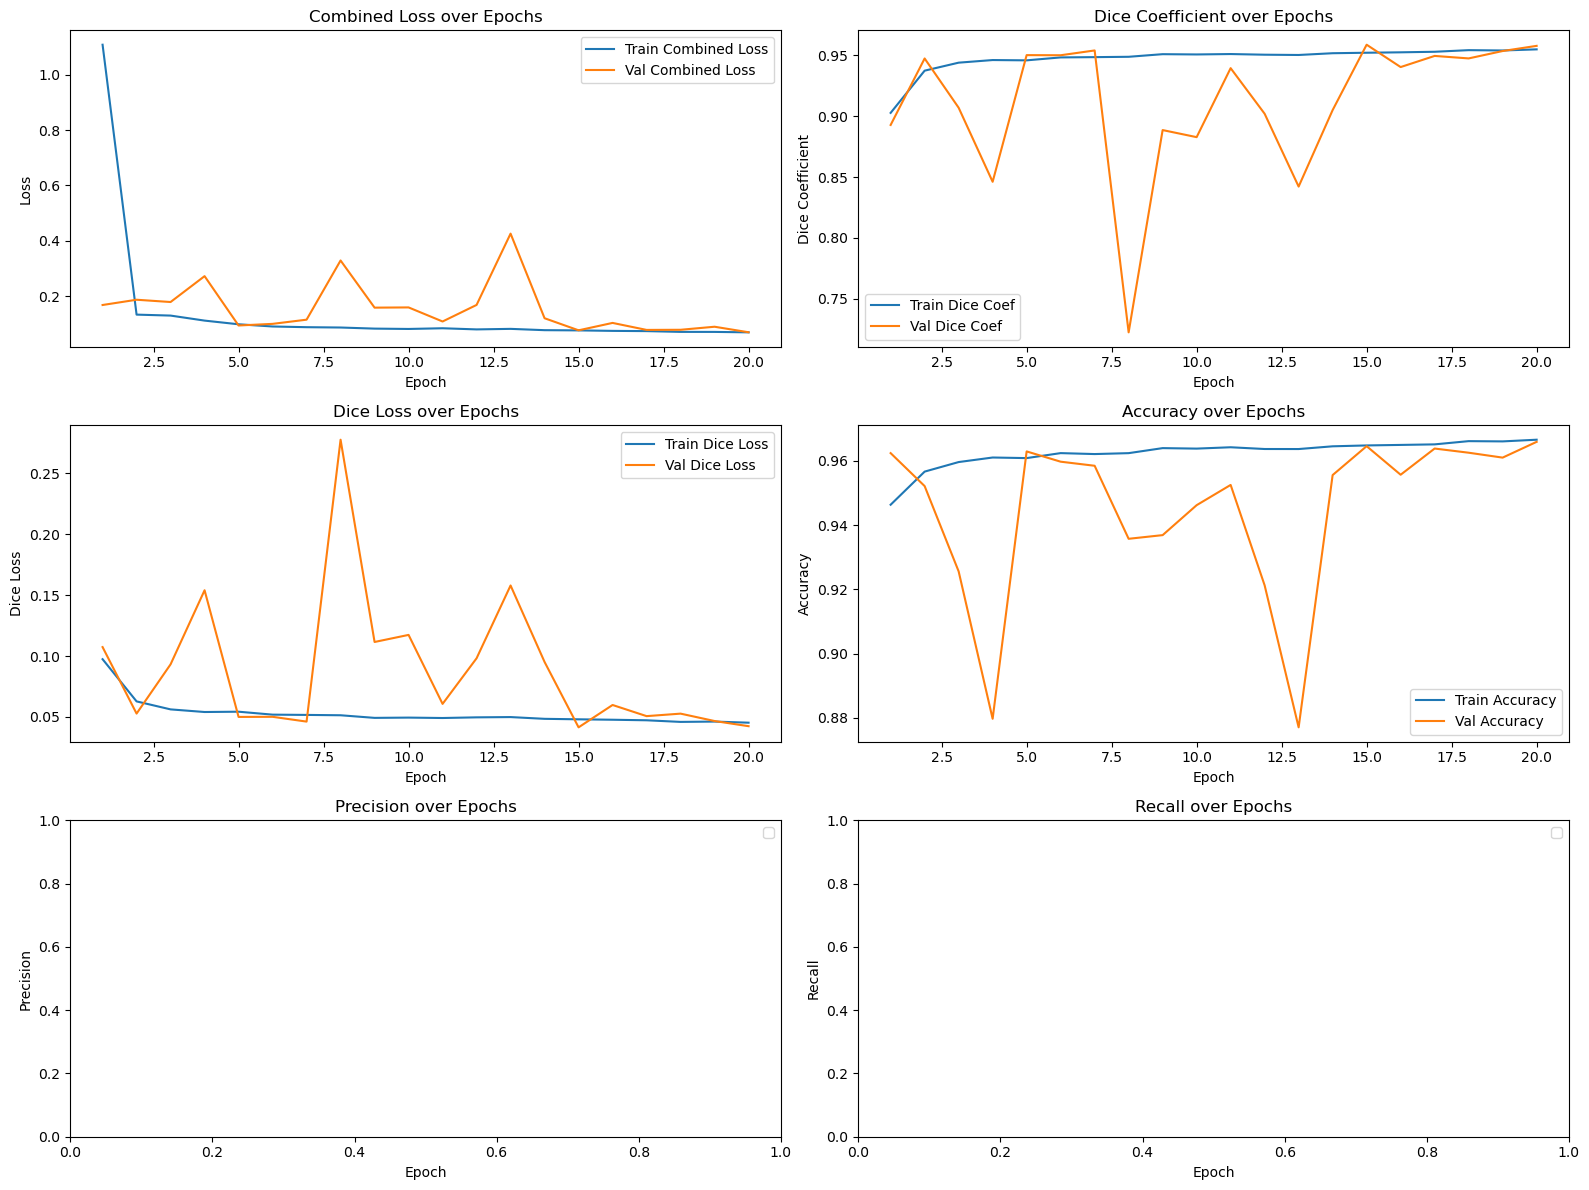


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_05.3_2025-03-11-07-32\Model_Data
63/63 [==============================] - 10s 162ms/step - loss: 0.0657 - accuracy: 0.9685 - precision_10: 0.9627 - recall_10: 0.9735 - dice_coef: 0.9603


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_05.3
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/f951829218e54026af0953843fdaf524
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                     : (0.9463726878166199, 0.9666152596473694)
COMET INFO:     batch_accuracy [880]              : (0.6774170398712158, 0.9762918949127197)
COMET INFO:     batch_dice_coef [880]             : (0.3659917414188385, 0.9689399003982544)
COMET INFO:     batch_loss [880]              

In [16]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.4, 0.30, 0.30)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_05.3"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 40.0% low, 40.0% mid, 20.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 40.0% low, 40.0% mid, 20.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 40.0% low, 40.0% mid, 20.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_11"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_12 (InputLayer)          [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_363 (Conv2D)            (None, 512, 512, 16  432    

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/3c5f17bbf1854001b44ec97bfffbafff

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.0940 - accuracy: 0.9441 - precision_11: 0.9246 - recall_11: 0.9342 - dice_coef: 0.8744   
Epoch 1: val_loss improved from inf to 0.27608, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 165s 368ms/step - loss: 1.0940 - accuracy: 0.9441 - precision_11: 0.9246 - recall_11: 0.9342 - dice_coef: 0.8744 - val_loss: 0.2761 - val_accuracy: 0.9154 - val_precision_11: 0.8280 - val_recall_11: 0.9904 - val_dice_coef: 0.8802
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1584 - accuracy: 0.9576 - precision_11: 0.9464 - recall_11: 0.9459 - dice_coef: 0.9240  
Epoch 2: val_loss improved from 0.27608 to 0.18106, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras

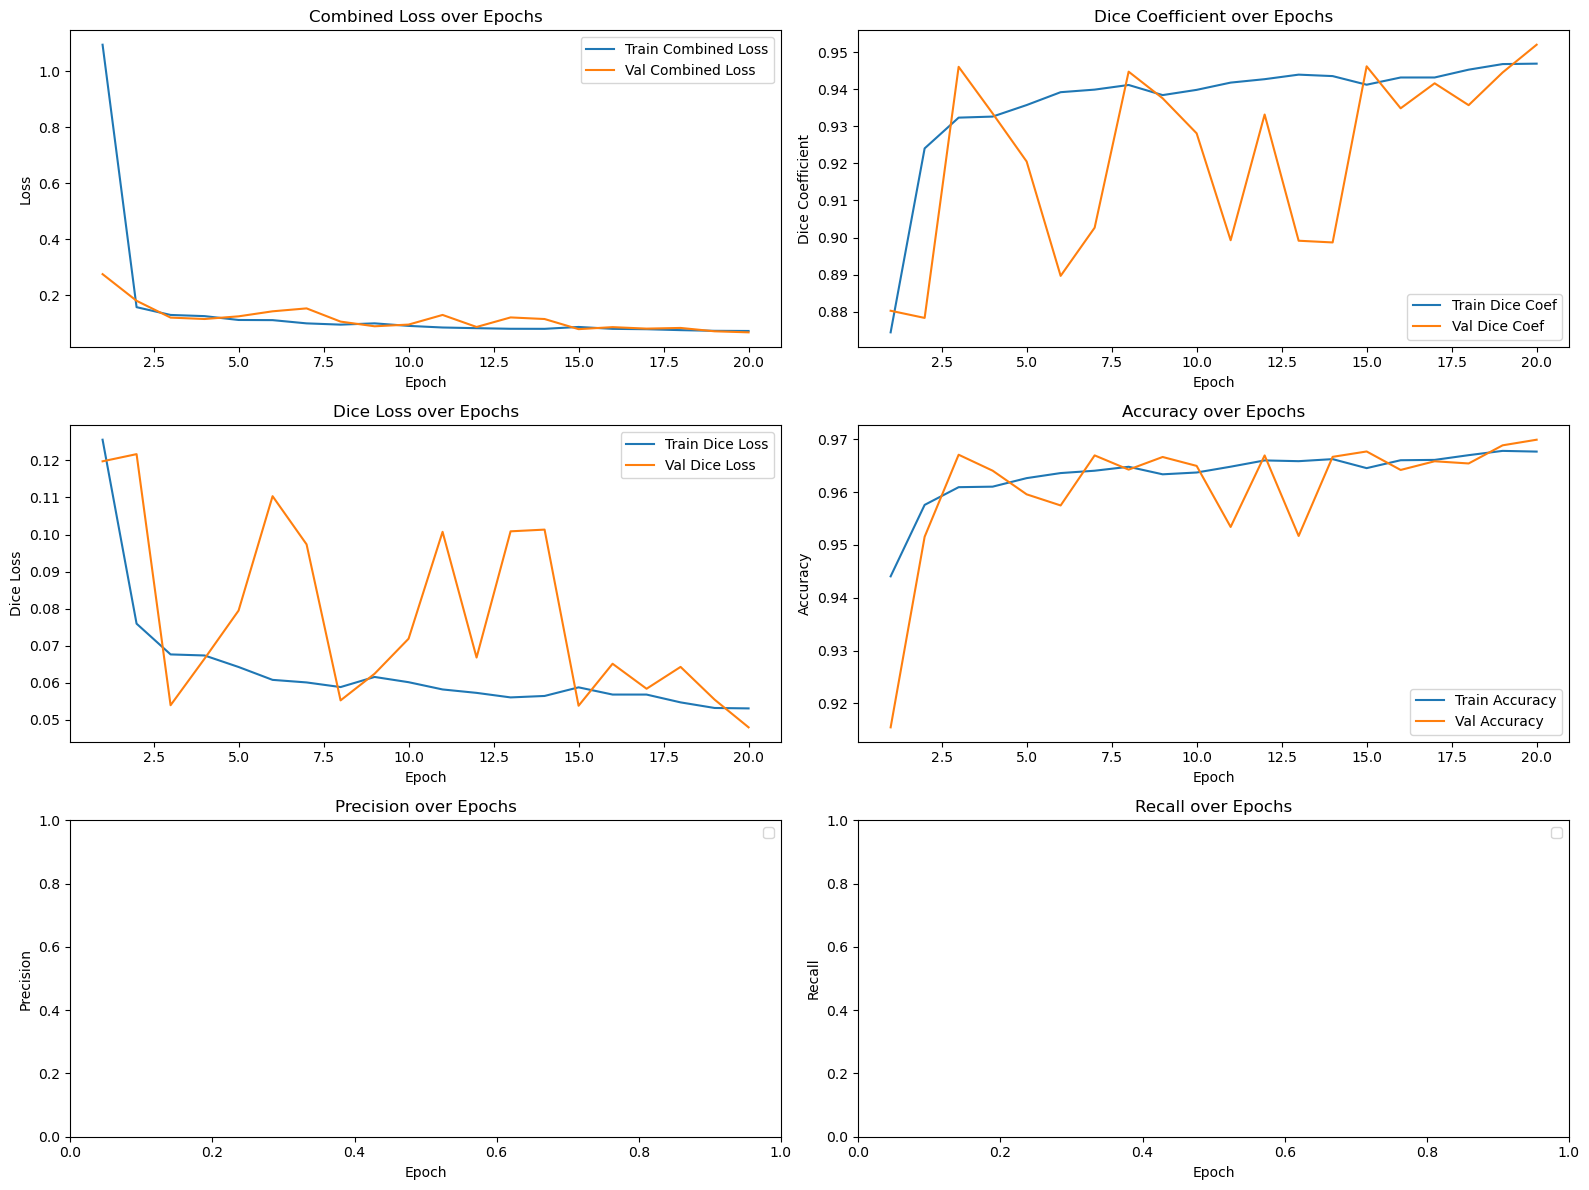


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_05.4_2025-03-11-08-28\Model_Data
63/63 [==============================] - 15s 240ms/step - loss: 0.0693 - accuracy: 0.9698 - precision_11: 0.9610 - recall_11: 0.9625 - dice_coef: 0.9512


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_05.4
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/3c5f17bbf1854001b44ec97bfffbafff
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                     : (0.9440578818321228, 0.9678372144699097)
COMET INFO:     batch_accuracy [880]              : (0.37293076515197754, 0.9845302104949951)
COMET INFO:     batch_dice_coef [880]             : (0.27905911207199097, 0.9722393751144409)
COMET INFO:     batch_loss [880]            

In [17]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.4, 0.40, 0.20)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_05.4"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 20.0% low, 40.0% mid, 40.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 20.0% low, 40.0% mid, 40.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 20.0% low, 40.0% mid, 40.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_12"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_13 (InputLayer)          [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_396 (Conv2D)            (None, 512, 512, 16  432    

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/bcbed014553047c6ae96fdd1fee0c9a5

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.1511 - accuracy: 0.9454 - precision_12: 0.9541 - recall_12: 0.9520 - dice_coef: 0.8990   
Epoch 1: val_loss improved from inf to 0.22503, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 180s 404ms/step - loss: 1.1511 - accuracy: 0.9454 - precision_12: 0.9541 - recall_12: 0.9520 - dice_coef: 0.8990 - val_loss: 0.2250 - val_accuracy: 0.9109 - val_precision_12: 0.8752 - val_recall_12: 0.9878 - val_dice_coef: 0.8878
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1460 - accuracy: 0.9536 - precision_12: 0.9576 - recall_12: 0.9630 - dice_coef: 0.9417  
Epoch 2: val_loss improved from 0.22503 to 0.16198, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras

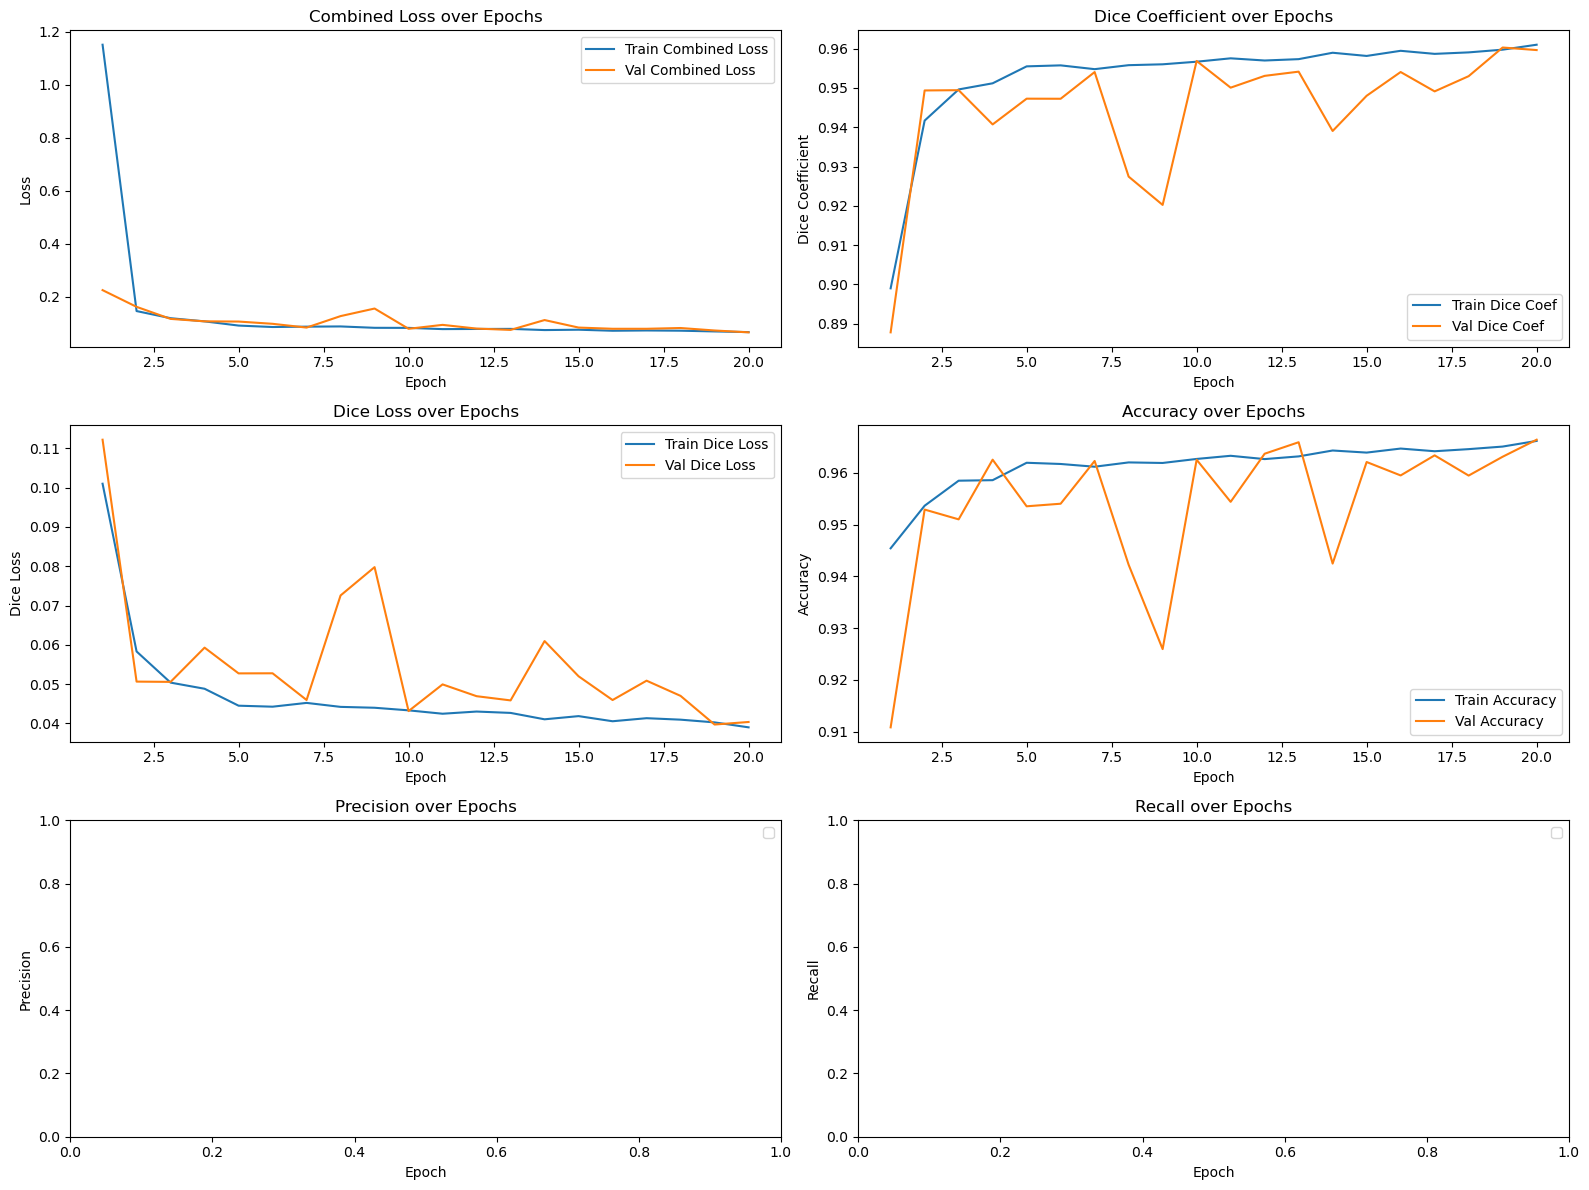


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_05.5_2025-03-11-09-25\Model_Data
63/63 [==============================] - 15s 238ms/step - loss: 0.0637 - accuracy: 0.9679 - precision_12: 0.9645 - recall_12: 0.9815 - dice_coef: 0.9617


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_05.5
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/bcbed014553047c6ae96fdd1fee0c9a5
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                     : (0.9454103112220764, 0.9661366939544678)
COMET INFO:     batch_accuracy [880]              : (0.3597862720489502, 0.9812731742858887)
COMET INFO:     batch_dice_coef [880]             : (0.34742501378059387, 0.9738988876342773)
COMET INFO:     batch_loss [880]             

In [18]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.4, 0.20, 0.40)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_05.5"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 20.0% low, 60.0% mid, 20.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 20.0% low, 60.0% mid, 20.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 20.0% low, 60.0% mid, 20.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_13"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_14 (InputLayer)          [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_429 (Conv2D)            (None, 512, 512, 16  432    

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/d9dd213207b041da934f07a2841d1095

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.1107 - accuracy: 0.9376 - precision_13: 0.9347 - recall_13: 0.9384 - dice_coef: 0.9042   
Epoch 1: val_loss improved from inf to 0.22125, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 181s 406ms/step - loss: 1.1107 - accuracy: 0.9376 - precision_13: 0.9347 - recall_13: 0.9384 - dice_coef: 0.9042 - val_loss: 0.2212 - val_accuracy: 0.9265 - val_precision_13: 0.8859 - val_recall_13: 0.9752 - val_dice_coef: 0.8755
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1438 - accuracy: 0.9495 - precision_13: 0.9465 - recall_13: 0.9506 - dice_coef: 0.9298  
Epoch 2: val_loss improved from 0.22125 to 0.14235, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras

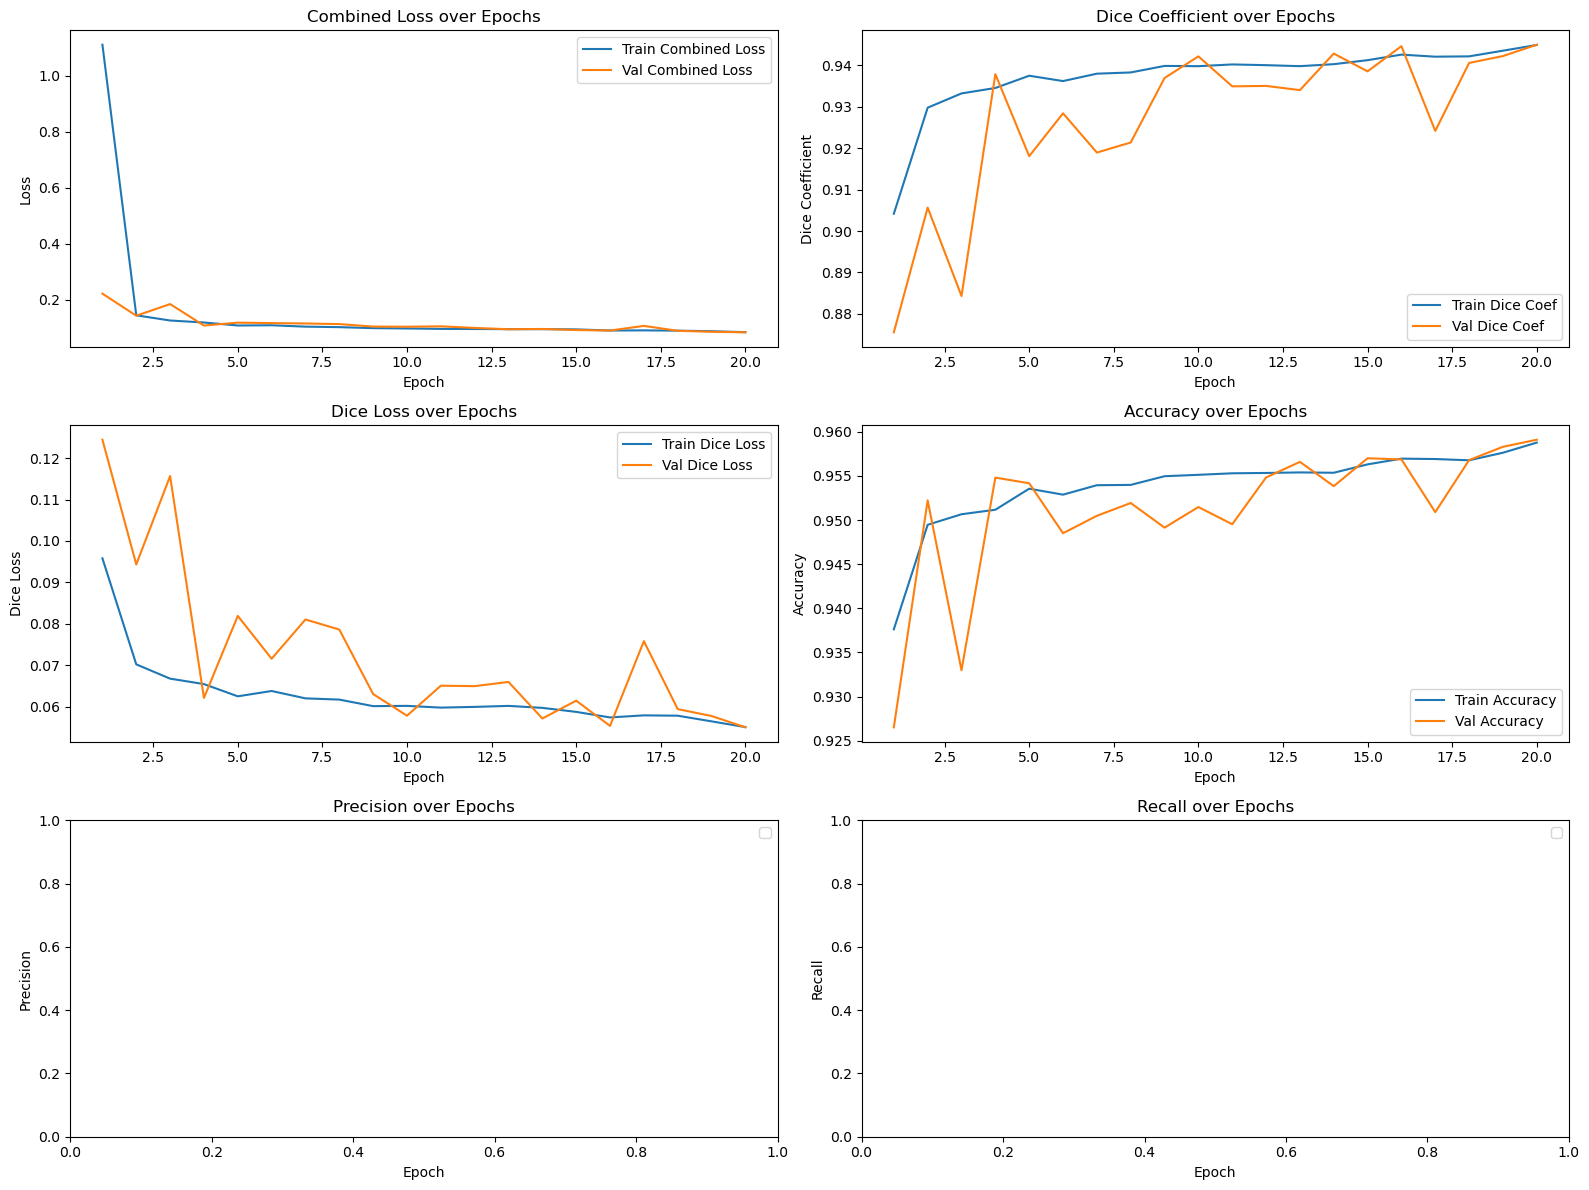


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_05.6_2025-03-11-10-26\Model_Data
63/63 [==============================] - 15s 228ms/step - loss: 0.0841 - accuracy: 0.9587 - precision_13: 0.9577 - recall_13: 0.9579 - dice_coef: 0.9451


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_05.6
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/d9dd213207b041da934f07a2841d1095
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                     : (0.9376175999641418, 0.9587790369987488)
COMET INFO:     batch_accuracy [880]              : (0.44098520278930664, 0.9751043319702148)
COMET INFO:     batch_dice_coef [880]             : (0.45736199617385864, 0.9681659936904907)
COMET INFO:     batch_loss [880]            

In [19]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.6, 0.20, 0.20)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_05.6"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 30.0% low, 60.0% mid, 10.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 30.0% low, 60.0% mid, 10.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 30.0% low, 60.0% mid, 10.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 512, 512, 16  432       

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/4ec5249170564a0c890f1ef6bf1f3510

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging
COMET INFO: Ignoring automatic log_parameter('verbose') because 'keras:verbose' is in COMET_LOGGING_PARAMETERS_IGNORE


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.0534 - accuracy: 0.9427 - precision: 0.9200 - recall: 0.9367 - dice_coef: 0.8784   
Epoch 1: val_loss improved from inf to 0.16657, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 182s 384ms/step - loss: 1.0534 - accuracy: 0.9427 - precision: 0.9200 - recall: 0.9367 - dice_coef: 0.8784 - val_loss: 0.1666 - val_accuracy: 0.9517 - val_precision: 0.9234 - val_recall: 0.9571 - val_dice_coef: 0.9018
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1526 - accuracy: 0.9524 - precision: 0.9361 - recall: 0.9443 - dice_coef: 0.9191  
Epoch 2: val_loss did not improve from 0.16657
Epoch 2: learning_rate = 0.000954
438/438 [==============================] - 168s 384ms/step - loss: 0.1526 - accuracy: 0.9524 - precision: 0.9361 - recall: 0.9443 - dic

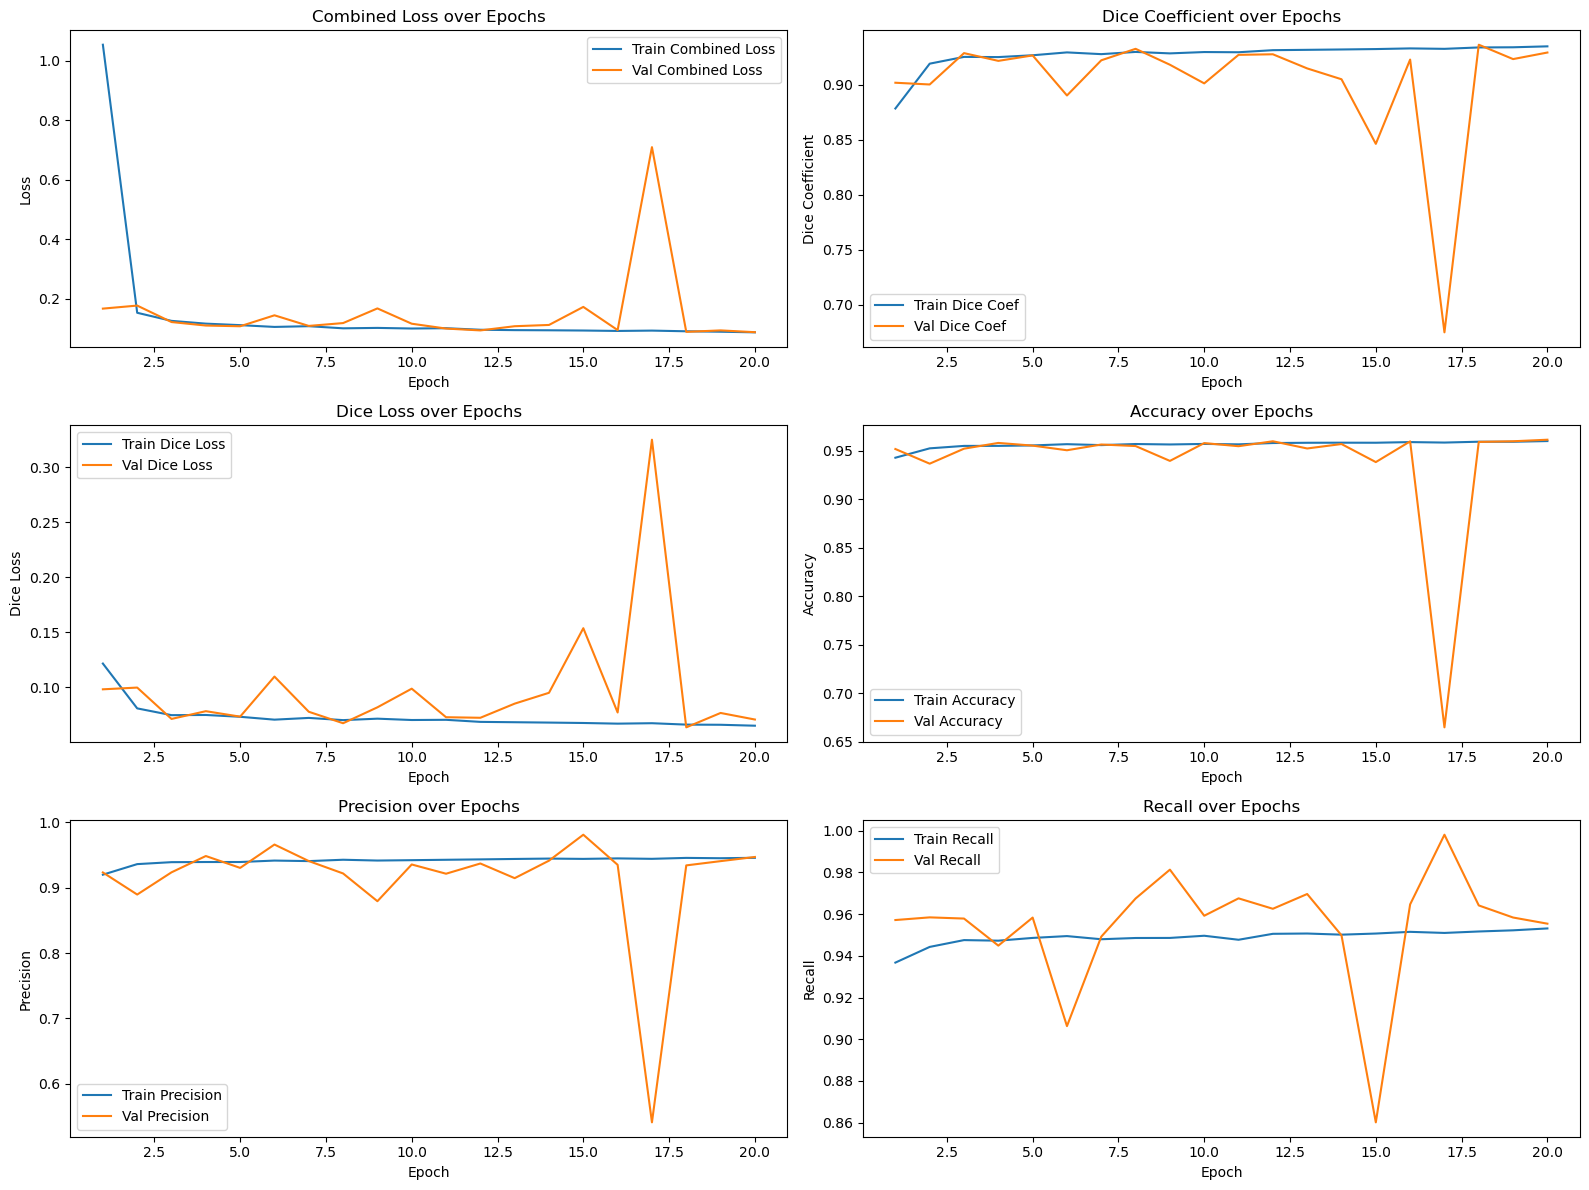


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_05.7_2025-03-11-16-31\Model_Data
63/63 [==============================] - 12s 189ms/step - loss: 0.0876 - accuracy: 0.9611 - precision: 0.9505 - recall: 0.9521 - dice_coef: 0.9299


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_05.7
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/4ec5249170564a0c890f1ef6bf1f3510
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                  : (0.9427054524421692, 0.959865927696228)
COMET INFO:     batch_accuracy [880]           : (0.6456198692321777, 0.9788358211517334)
COMET INFO:     batch_dice_coef [880]          : (0.3569078743457794, 0.9591342210769653)
COMET INFO:     batch_loss [880]               : (0.05154161900281906, 47.11180114746094)
COMET INFO:     batch_precision [880]          : (0.32160547375679016, 0.9853693246841431)
COMET INFO:     batch_recall [

In [5]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.6, 0.30, 0.10)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_05.7"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 10.0% low, 60.0% mid, 30.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 10.0% low, 60.0% mid, 30.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 10.0% low, 60.0% mid, 30.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_33 (Conv2D)             (None, 512, 512, 16  432     

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/2d95a62e0eef4c8b8d923e1731b0912a

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.0934 - accuracy: 0.9419 - precision_1: 0.9499 - recall_1: 0.9506 - dice_coef: 0.9169   
Epoch 1: val_loss improved from inf to 0.17167, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 179s 402ms/step - loss: 1.0934 - accuracy: 0.9419 - precision_1: 0.9499 - recall_1: 0.9506 - dice_coef: 0.9169 - val_loss: 0.1717 - val_accuracy: 0.9398 - val_precision_1: 0.9318 - val_recall_1: 0.9673 - val_dice_coef: 0.9317
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1411 - accuracy: 0.9495 - precision_1: 0.9544 - recall_1: 0.9594 - dice_coef: 0.9400  
Epoch 2: val_loss did not improve from 0.17167
Epoch 2: learning_rate = 0.000954
438/438 [==============================] - 176s 402ms/step - loss: 0.1411 - accuracy: 0.9495 - precision_1: 0.9544 - re

C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\unet2.py:253: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2,0].legend()
C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\unet2.py:263: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2,1].legend()


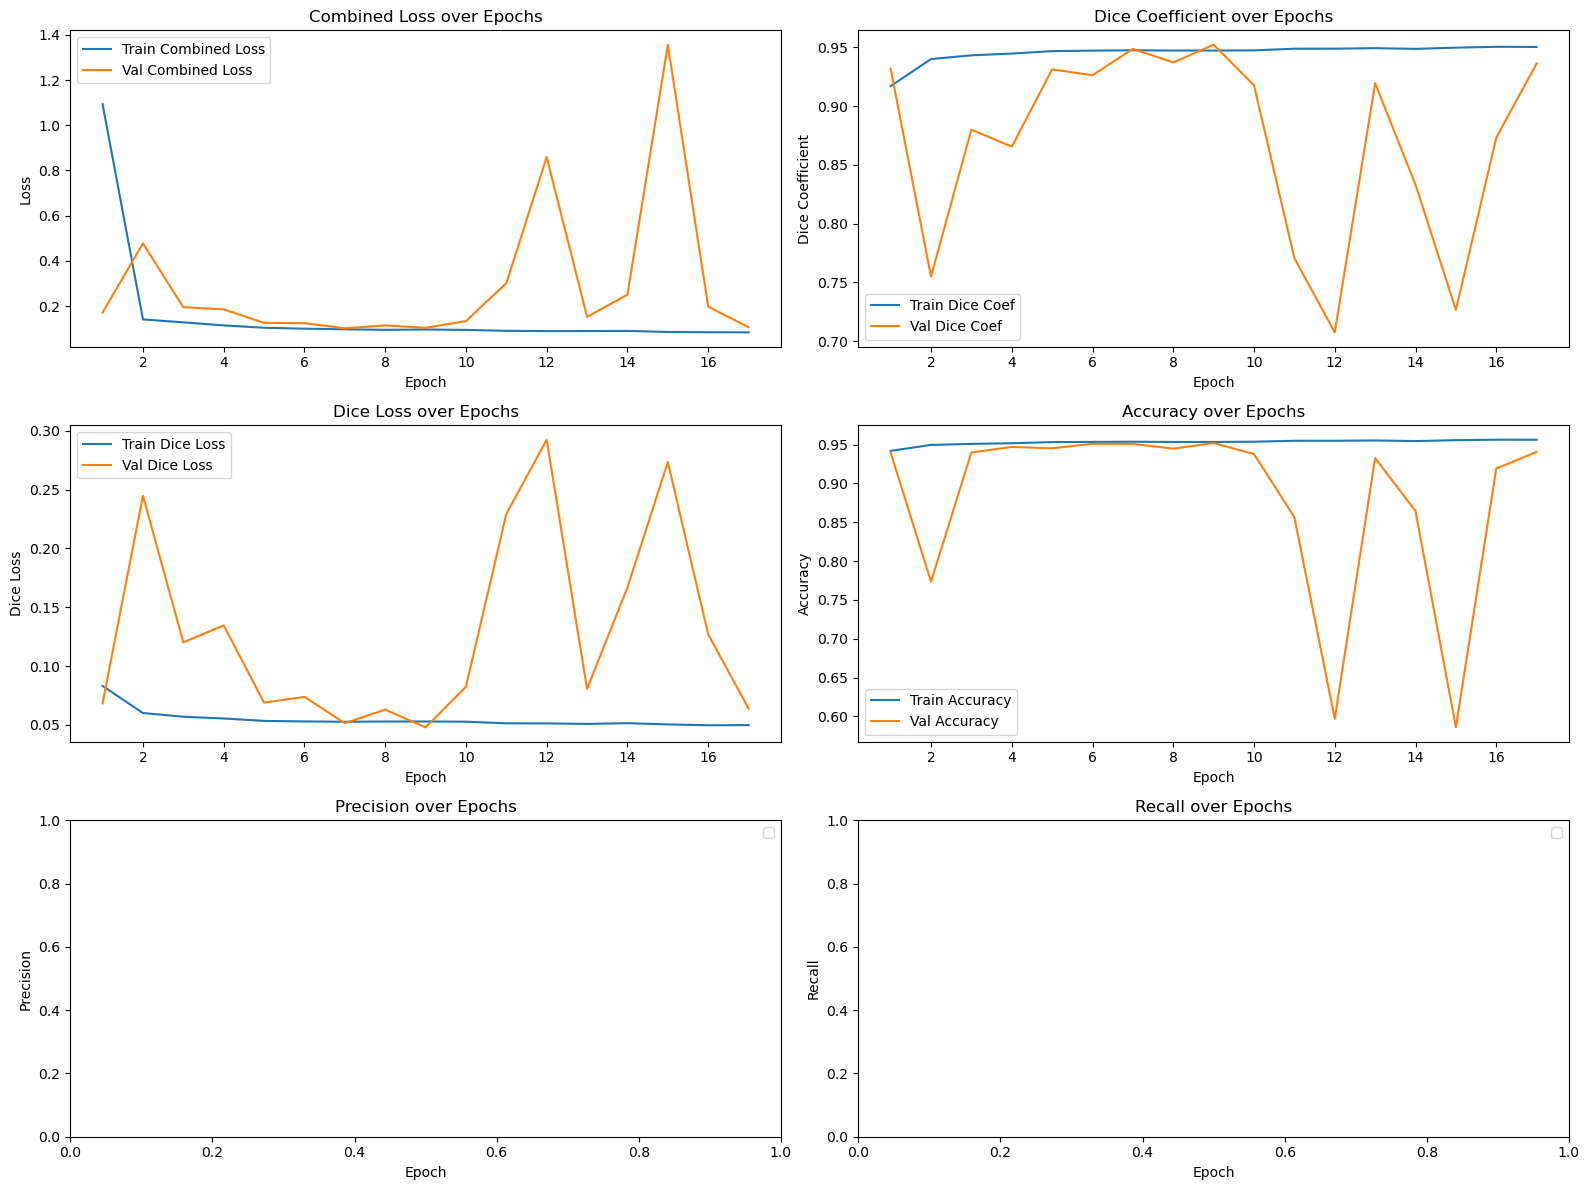


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_05.8_2025-03-11-17-30\Model_Data
63/63 [==============================] - 15s 234ms/step - loss: 0.1032 - accuracy: 0.9508 - precision_1: 0.9754 - recall_1: 0.9398 - dice_coef: 0.9486


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_05.8
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/2d95a62e0eef4c8b8d923e1731b0912a
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [17]                    : (0.9419012665748596, 0.9562311172485352)
COMET INFO:     batch_accuracy [748]             : (0.44494104385375977, 0.9680705070495605)
COMET INFO:     batch_dice_coef [748]            : (0.44567131996154785, 0.965053379535675)
COMET INFO:     batch_loss [748]                

In [6]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.6, 0.10, 0.30)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_05.8"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)

In [7]:
#DATA SPLIT
folder_path = r"C:\Users\jaydb\Snowpack_Project\Tiled_Output"
sites = ["DeerCreekTrail", "EastRiverTrail", "Elkton", "JuddFalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy"]
snow_vs_notsnow_ratio_distribution = (0.9, 0.1) 

# Aggregate tile pairs from all provided sites.
all_tile_pairs = aggregate_tile_pairs(sites, folder_path)
print(f"Total aggregated tile pairs: {len(all_tile_pairs)}")
    
# Bin tile pairs into low, mid, and high categories.
low_bin, mid_bin, high_bin = bin_tile_pairs(all_tile_pairs, snow_vs_notsnow_ratio_distribution)
print(f"Tiles with {snow_vs_notsnow_ratio_distribution[1] * 100}% or less snow pixels (low): {len(low_bin)}")
print(f"Tiles with {snow_vs_notsnow_ratio_distribution[1] * 100}% to {snow_vs_notsnow_ratio_distribution[0] * 100}% snow pixels (mid): {len(mid_bin)}")
print(f"Tiles with {snow_vs_notsnow_ratio_distribution[0] * 100}% or more snow pixels (high): {len(high_bin)}")

Total aggregated tile pairs: 118039
Tiles with 10.0% or less snow pixels (low): 83335
Tiles with 10.0% to 90.0% snow pixels (mid): 16846
Tiles with 90.0% or more snow pixels (high): 17858



Sampling training with 25.0% low, 50.0% mid, 25.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 25.0% low, 50.0% mid, 25.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 25.0% low, 50.0% mid, 25.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_66 (Conv2D)             (None, 512, 512, 16  432     

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/26268dbbc57e480e9f2c271a6748eb29

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.0861 - accuracy: 0.9436 - precision_2: 0.9370 - recall_2: 0.9495 - dice_coef: 0.8904   
Epoch 1: val_loss improved from inf to 0.16433, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 174s 389ms/step - loss: 1.0861 - accuracy: 0.9436 - precision_2: 0.9370 - recall_2: 0.9495 - dice_coef: 0.8904 - val_loss: 0.1643 - val_accuracy: 0.9473 - val_precision_2: 0.9335 - val_recall_2: 0.9609 - val_dice_coef: 0.9198
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1476 - accuracy: 0.9576 - precision_2: 0.9544 - recall_2: 0.9600 - dice_coef: 0.9368  
Epoch 2: val_loss improved from 0.16433 to 0.16038, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras
Epoch 2

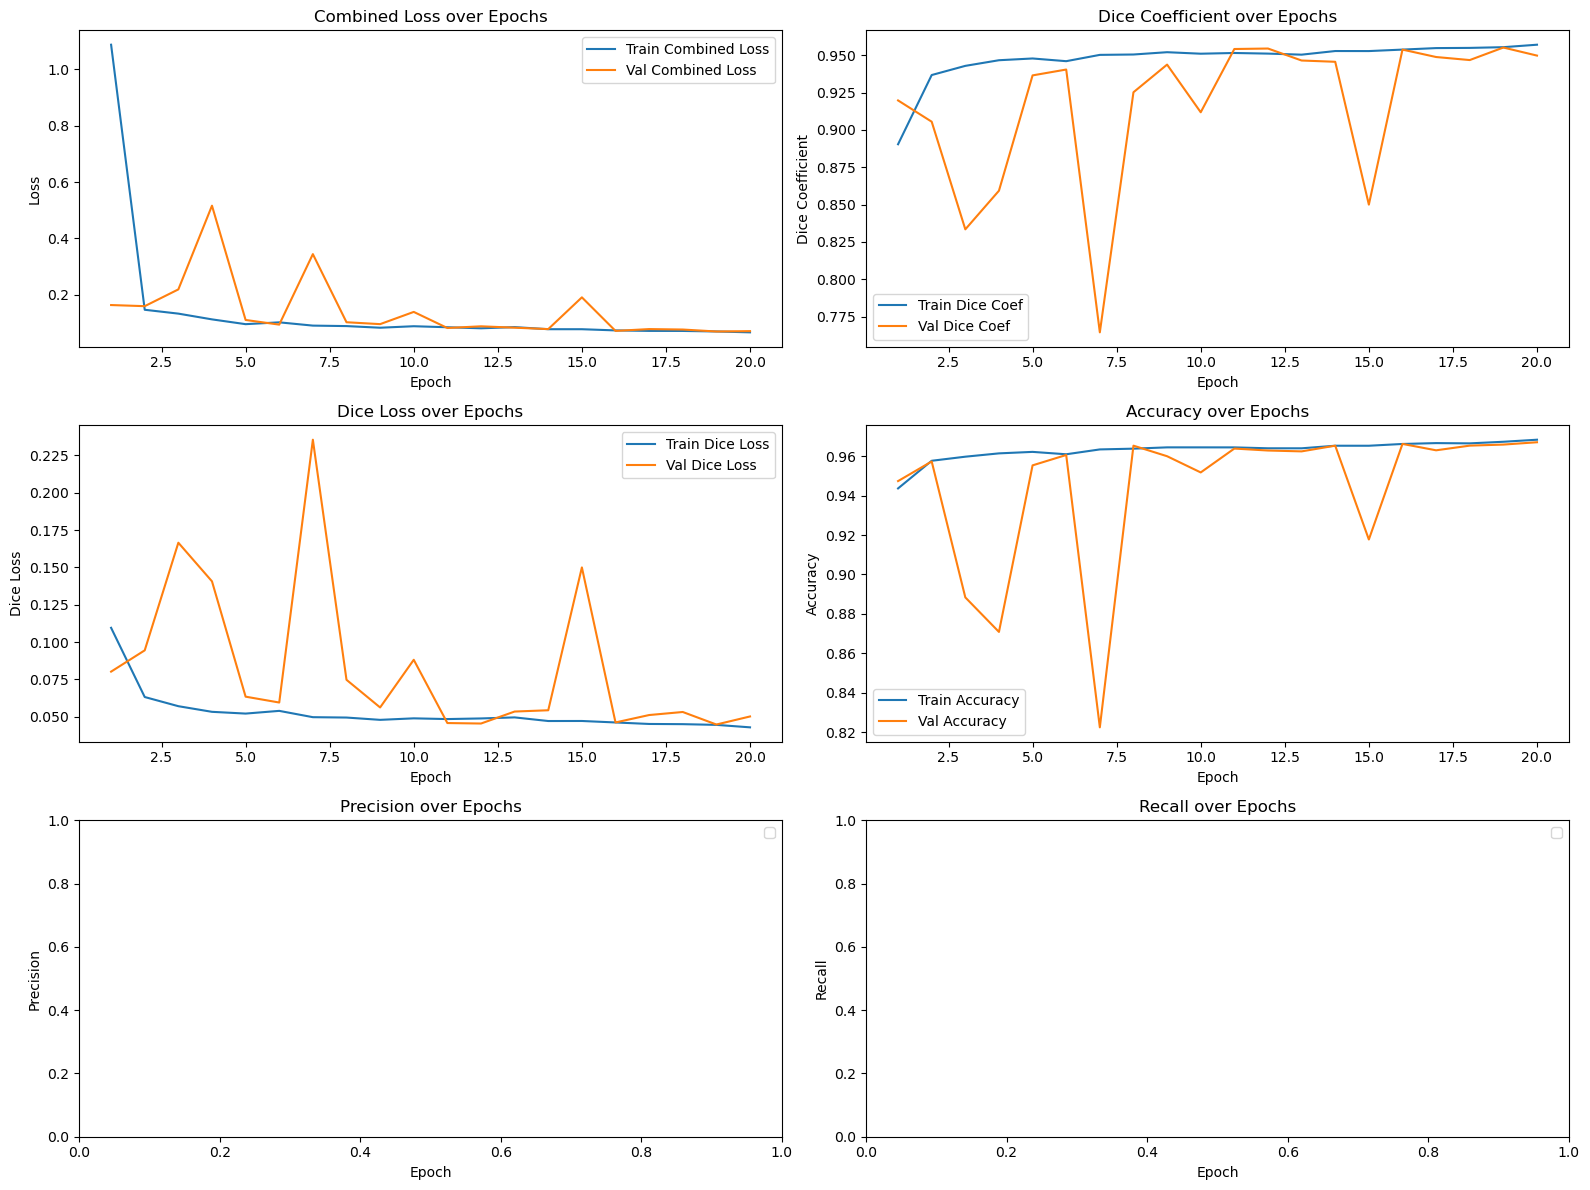


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_06_2025-03-11-18-29\Model_Data
63/63 [==============================] - 11s 166ms/step - loss: 0.0643 - accuracy: 0.9711 - precision_2: 0.9742 - recall_2: 0.9651 - dice_coef: 0.9552


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_06
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/26268dbbc57e480e9f2c271a6748eb29
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.9436273574829102, 0.9683106541633606)
COMET INFO:     batch_accuracy [880]             : (0.5082037448883057, 0.9804689884185791)
COMET INFO:     batch_dice_coef [880]            : (0.6306260228157043, 0.9696648716926575)
COMET INFO:     batch_loss [880]                 : 

In [8]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.5, 0.25, 0.25)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_06"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 35.0% low, 50.0% mid, 15.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 35.0% low, 50.0% mid, 15.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 35.0% low, 50.0% mid, 15.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_99 (Conv2D)             (None, 512, 512, 16  432     

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/1783e4cda94140d7ad54cb23611c990f

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.0819 - accuracy: 0.9451 - precision_3: 0.9279 - recall_3: 0.9335 - dice_coef: 0.8775   
Epoch 1: val_loss improved from inf to 0.22410, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 168s 377ms/step - loss: 1.0819 - accuracy: 0.9451 - precision_3: 0.9279 - recall_3: 0.9335 - dice_coef: 0.8775 - val_loss: 0.2241 - val_accuracy: 0.9402 - val_precision_3: 0.8792 - val_recall_3: 0.9819 - val_dice_coef: 0.8687
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1481 - accuracy: 0.9587 - precision_3: 0.9445 - recall_3: 0.9512 - dice_coef: 0.9255  
Epoch 2: val_loss did not improve from 0.22410
Epoch 2: learning_rate = 0.000954
438/438 [==============================] - 164s 375ms/step - loss: 0.1481 - accuracy: 0.9587 - precision_3: 0.9445 - re

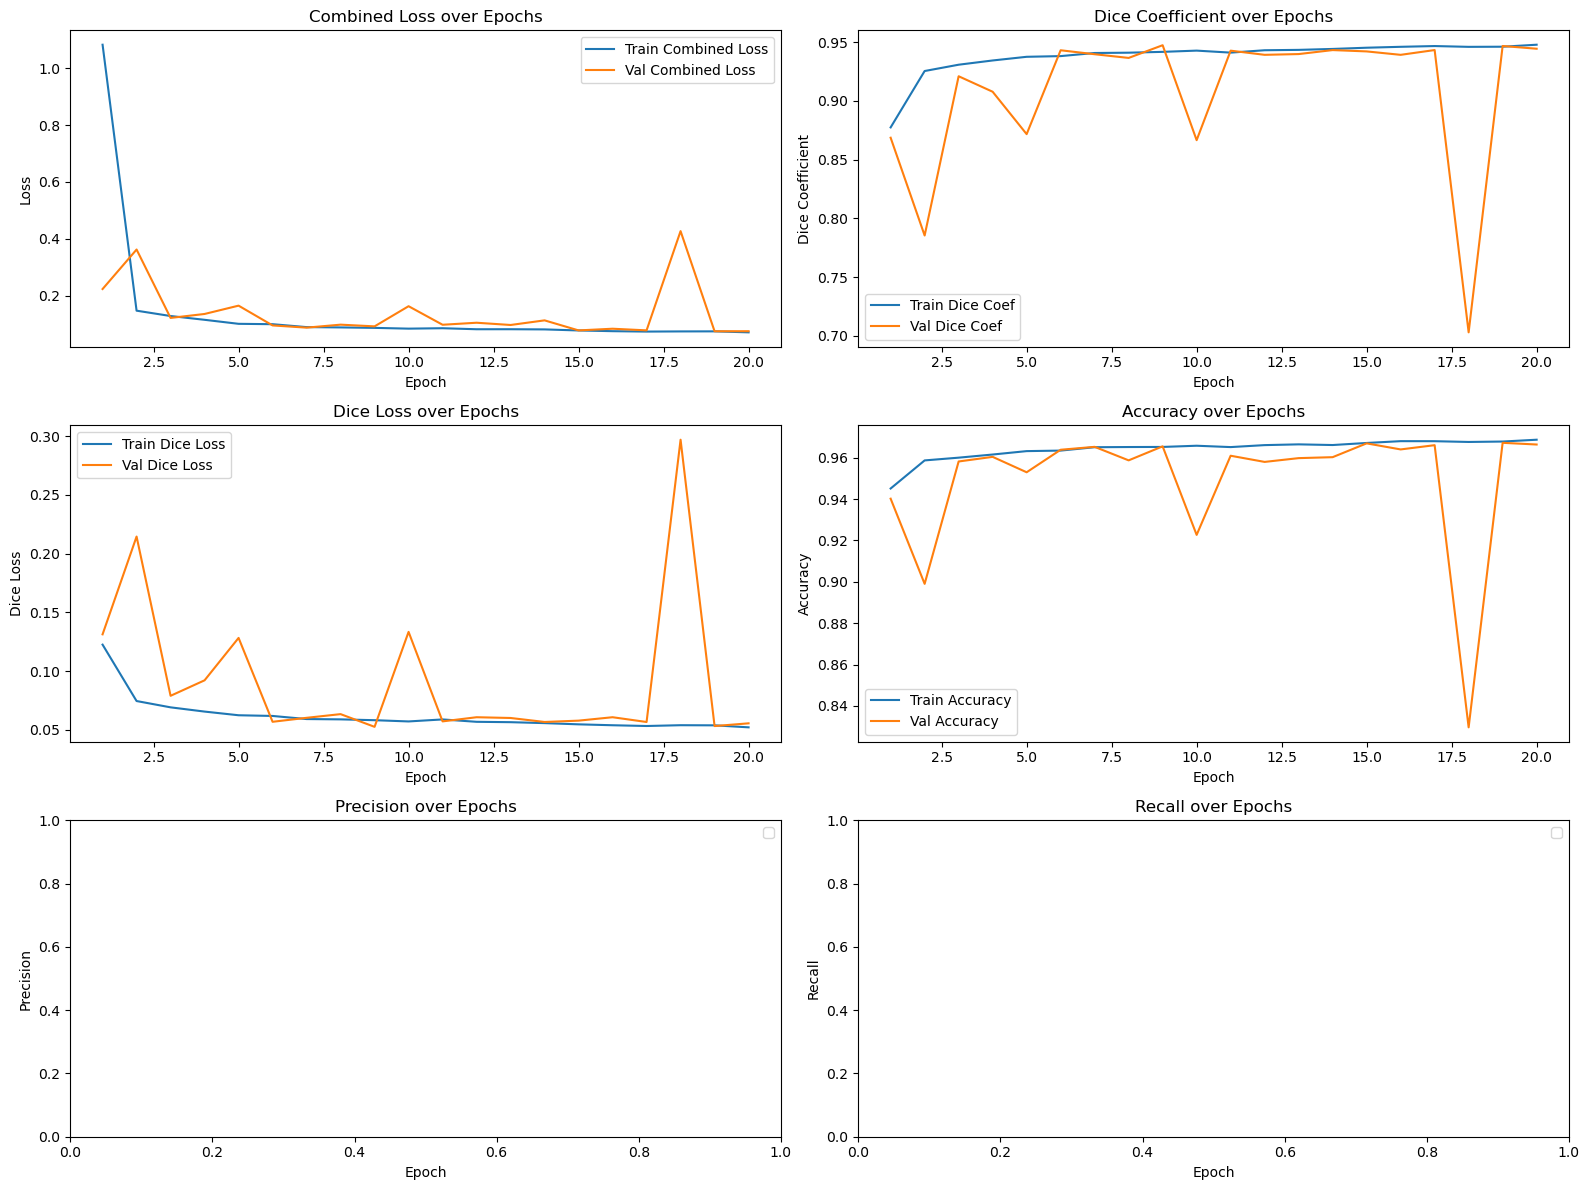


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_06.1_2025-03-11-19-27\Model_Data
63/63 [==============================] - 15s 233ms/step - loss: 0.0692 - accuracy: 0.9705 - precision_3: 0.9662 - recall_3: 0.9555 - dice_coef: 0.9481


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_06.1
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/1783e4cda94140d7ad54cb23611c990f
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.9451357126235962, 0.9687356948852539)
COMET INFO:     batch_accuracy [880]             : (0.48958849906921387, 0.9818811416625977)
COMET INFO:     batch_dice_coef [880]            : (0.502180278301239, 0.9714769721031189)
COMET INFO:     batch_loss [880]                 

In [9]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.5, 0.35, 0.15)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_06.1"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 15.0% low, 50.0% mid, 35.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 15.0% low, 50.0% mid, 35.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 15.0% low, 50.0% mid, 35.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_132 (Conv2D)            (None, 512, 512, 16  432     

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/ab0360b6fc554e989db6c40ec7b4cd9c

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.1419 - accuracy: 0.9457 - precision_4: 0.9520 - recall_4: 0.9564 - dice_coef: 0.9228   
Epoch 1: val_loss improved from inf to 0.22241, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 173s 386ms/step - loss: 1.1419 - accuracy: 0.9457 - precision_4: 0.9520 - recall_4: 0.9564 - dice_coef: 0.9228 - val_loss: 0.2224 - val_accuracy: 0.8993 - val_precision_4: 0.8568 - val_recall_4: 0.9949 - val_dice_coef: 0.9032
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1234 - accuracy: 0.9566 - precision_4: 0.9627 - recall_4: 0.9640 - dice_coef: 0.9477  
Epoch 2: val_loss improved from 0.22241 to 0.14690, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras
Epoch 2

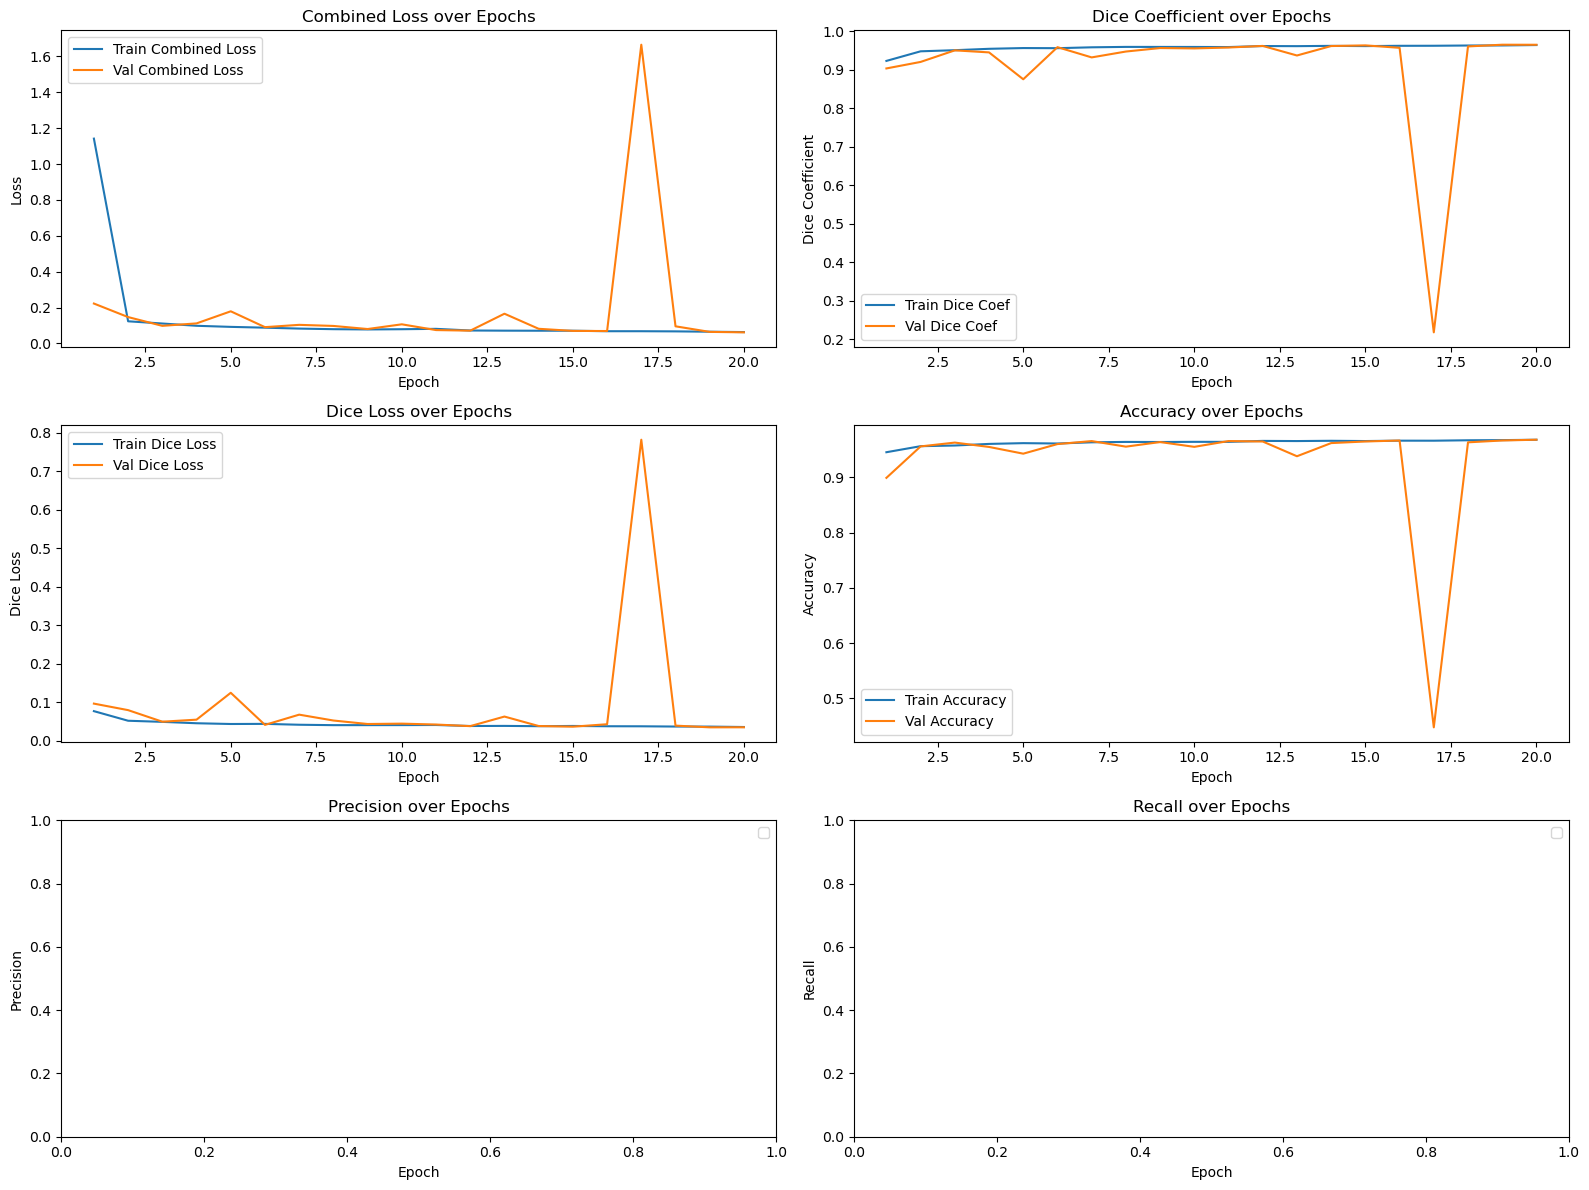


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_06.2_2025-03-11-20-25\Model_Data
63/63 [==============================] - 12s 184ms/step - loss: 0.0580 - accuracy: 0.9711 - precision_4: 0.9776 - recall_4: 0.9722 - dice_coef: 0.9670


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_06.2
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/ab0360b6fc554e989db6c40ec7b4cd9c
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.9456741213798523, 0.9682481288909912)
COMET INFO:     batch_accuracy [880]             : (0.4746367931365967, 0.984442949295044)
COMET INFO:     batch_dice_coef [880]            : (0.5754653215408325, 0.9795693755149841)
COMET INFO:     batch_loss [880]                 :

In [10]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.5, 0.15, 0.35)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_06.2"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 30.0% low, 40.0% mid, 30.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 30.0% low, 40.0% mid, 30.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 30.0% low, 40.0% mid, 30.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_165 (Conv2D)            (None, 512, 512, 16  432     

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/d406797397874888a5e629a58b33cfc8

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.2335 - accuracy: 0.9458 - precision_5: 0.9430 - recall_5: 0.9475 - dice_coef: 0.8882   
Epoch 1: val_loss improved from inf to 0.25938, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 172s 386ms/step - loss: 1.2335 - accuracy: 0.9458 - precision_5: 0.9430 - recall_5: 0.9475 - dice_coef: 0.8882 - val_loss: 0.2594 - val_accuracy: 0.9347 - val_precision_5: 0.8940 - val_recall_5: 0.9840 - val_dice_coef: 0.9244
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1439 - accuracy: 0.9623 - precision_5: 0.9605 - recall_5: 0.9632 - dice_coef: 0.9431  
Epoch 2: val_loss improved from 0.25938 to 0.11950, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras
Epoch 2

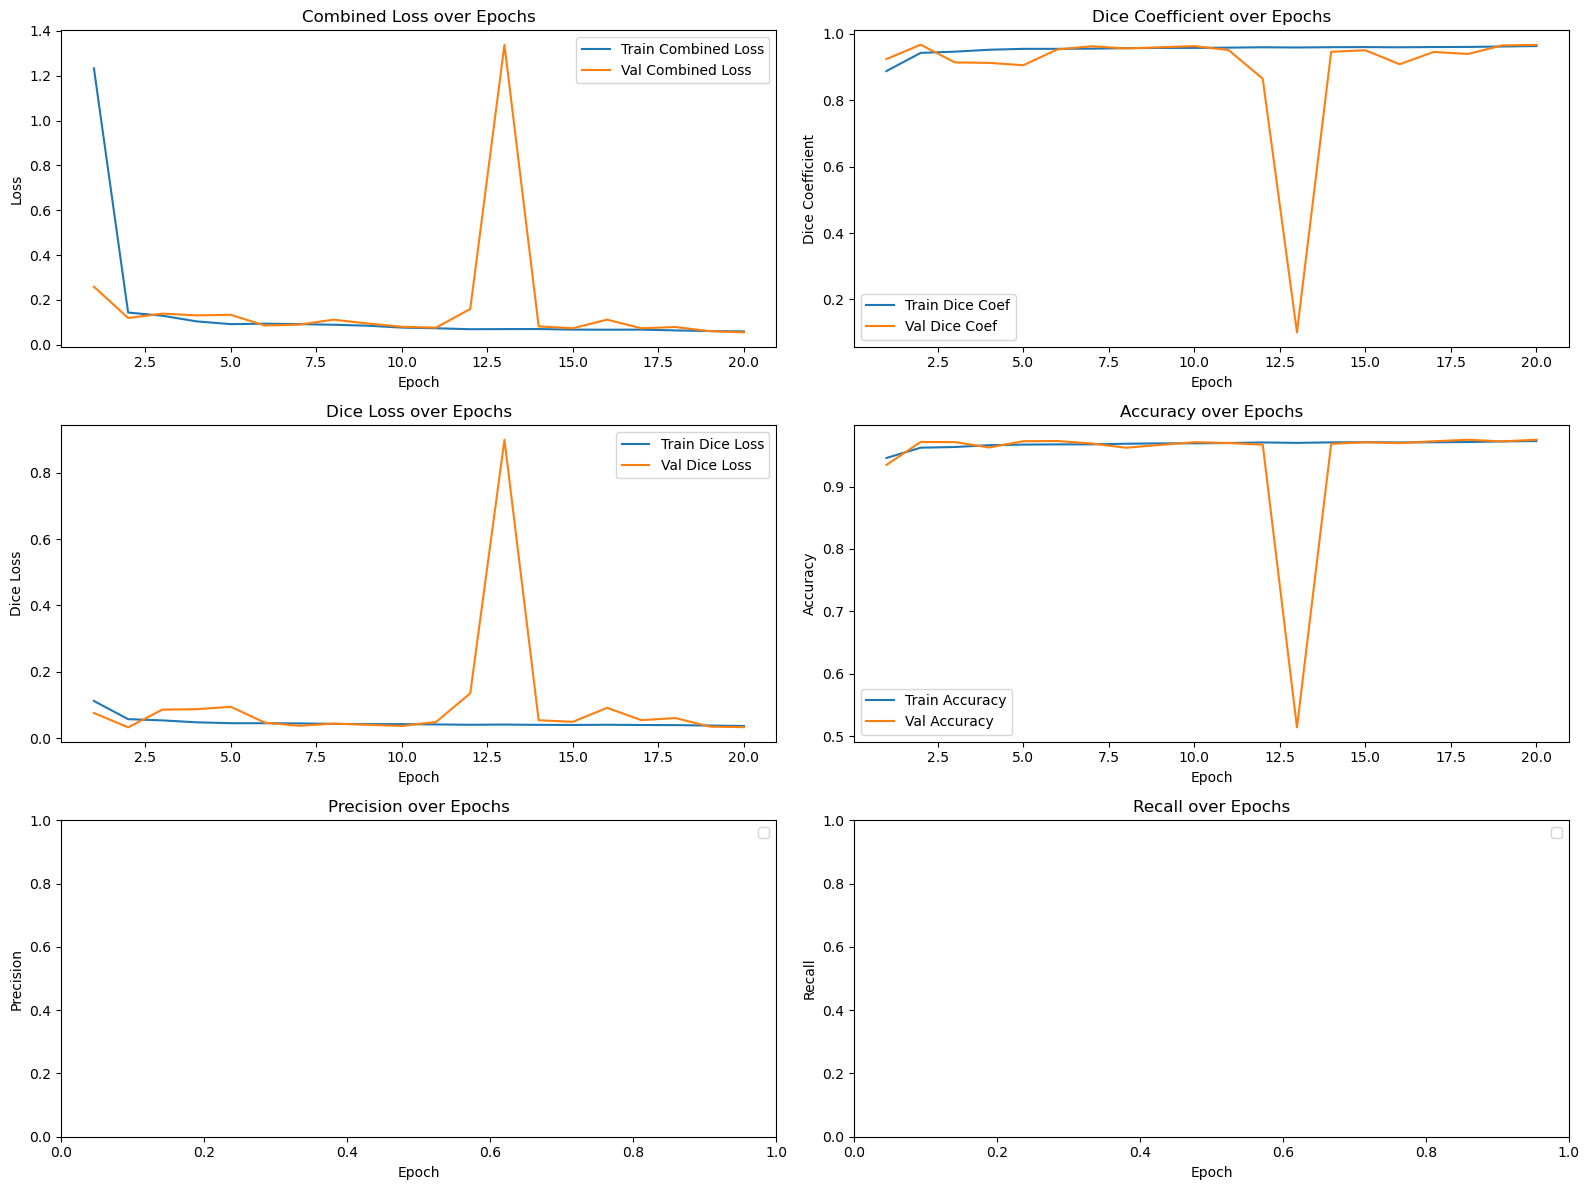


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_06.3_2025-03-11-21-23\Model_Data
63/63 [==============================] - 15s 230ms/step - loss: 0.0613 - accuracy: 0.9718 - precision_5: 0.9667 - recall_5: 0.9767 - dice_coef: 0.9622


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_06.3
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/d406797397874888a5e629a58b33cfc8
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.9457988142967224, 0.9729184508323669)
COMET INFO:     batch_accuracy [880]             : (0.47480058670043945, 0.9942469596862793)
COMET INFO:     batch_dice_coef [880]            : (0.4528639614582062, 0.9832707643508911)
COMET INFO:     batch_loss [880]                

In [11]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.4, 0.30, 0.30)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_06.3"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 40.0% low, 40.0% mid, 20.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 40.0% low, 40.0% mid, 20.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 40.0% low, 40.0% mid, 20.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_6"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_7 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_198 (Conv2D)            (None, 512, 512, 16  432     

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/dc6885775de8445ab1a8ac957c988dff

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.1082 - accuracy: 0.9514 - precision_6: 0.9363 - recall_6: 0.9410 - dice_coef: 0.8852   
Epoch 1: val_loss improved from inf to 0.16070, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 172s 385ms/step - loss: 1.1082 - accuracy: 0.9514 - precision_6: 0.9363 - recall_6: 0.9410 - dice_coef: 0.8852 - val_loss: 0.1607 - val_accuracy: 0.9606 - val_precision_6: 0.9302 - val_recall_6: 0.9728 - val_dice_coef: 0.8946
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1592 - accuracy: 0.9615 - precision_6: 0.9500 - recall_6: 0.9527 - dice_coef: 0.9295  
Epoch 2: val_loss improved from 0.16070 to 0.13762, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras
Epoch 2

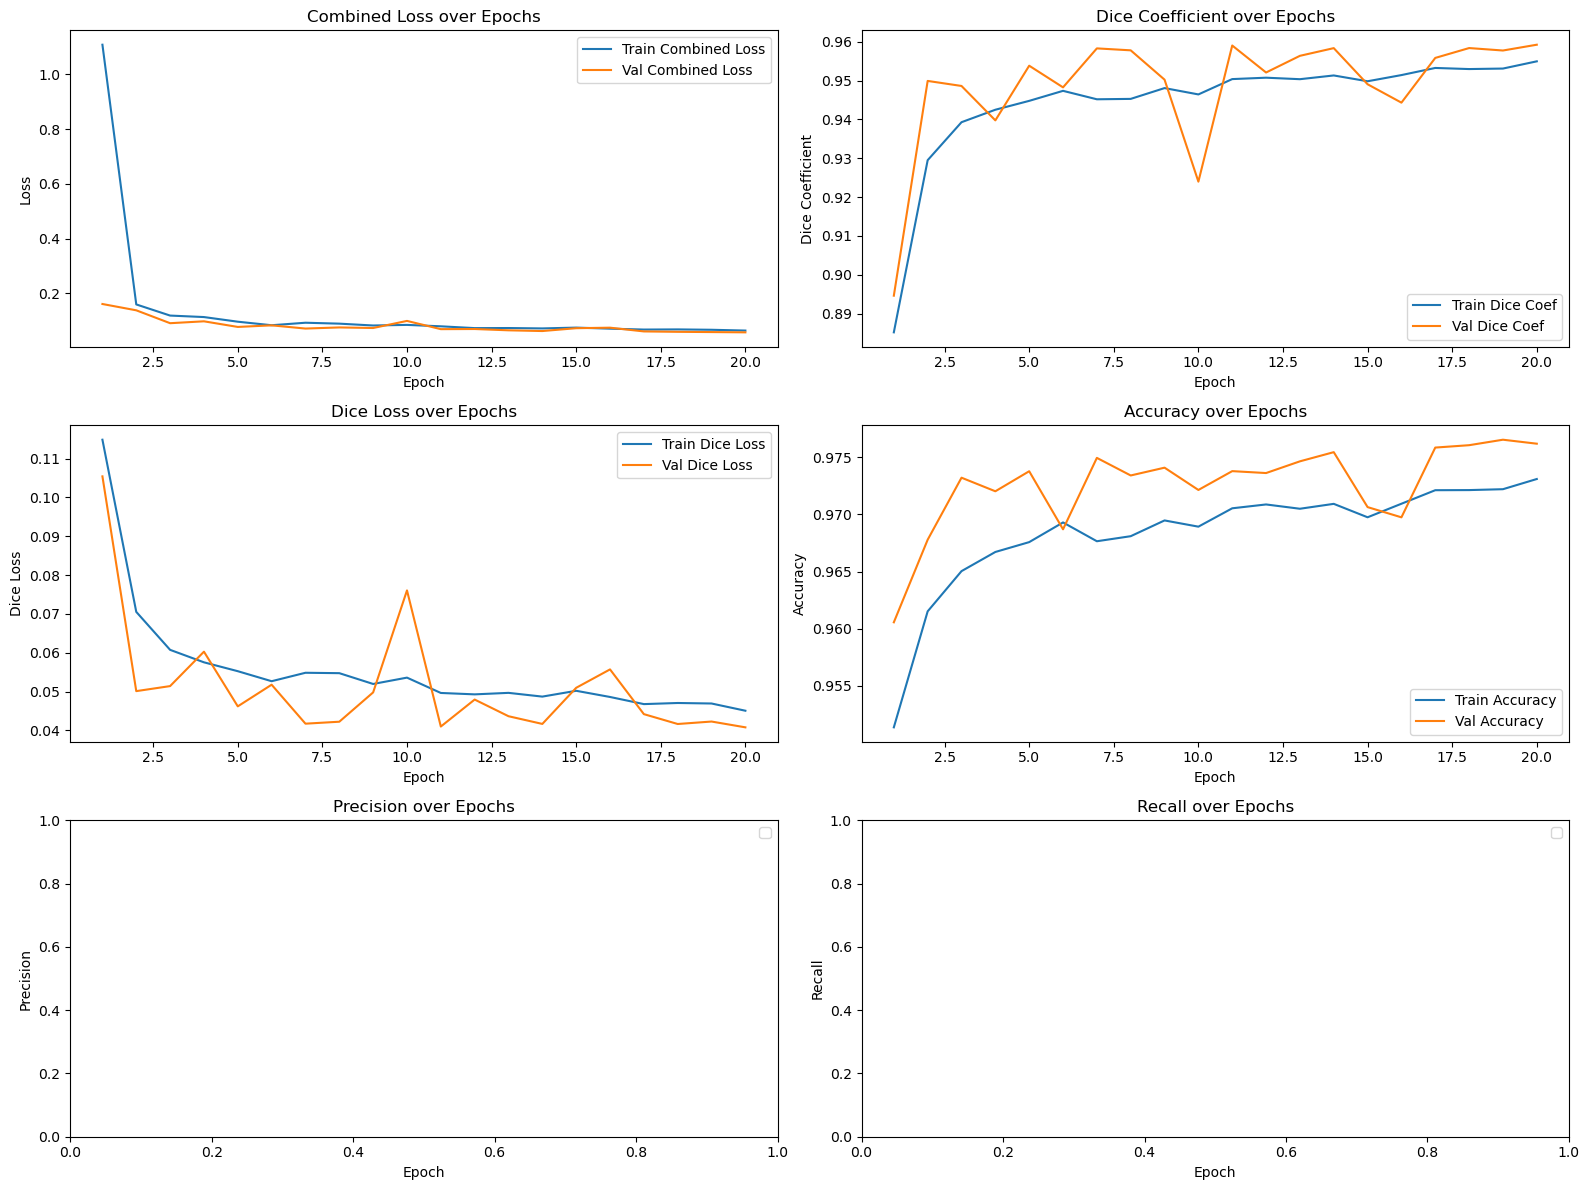


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_06.4_2025-03-11-22-21\Model_Data
63/63 [==============================] - 12s 187ms/step - loss: 0.0642 - accuracy: 0.9720 - precision_6: 0.9729 - recall_6: 0.9559 - dice_coef: 0.9532


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_06.4
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/dc6885775de8445ab1a8ac957c988dff
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.9513792991638184, 0.9730965495109558)
COMET INFO:     batch_accuracy [880]             : (0.4636352062225342, 0.9829542636871338)
COMET INFO:     batch_dice_coef [880]            : (0.45528969168663025, 0.9710140824317932)
COMET INFO:     batch_loss [880]                

In [12]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.4, 0.40, 0.20)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_06.4"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 20.0% low, 40.0% mid, 40.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 20.0% low, 40.0% mid, 40.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 20.0% low, 40.0% mid, 40.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_7"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_8 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_231 (Conv2D)            (None, 512, 512, 16  432     

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/acd15d4e2cf2409bb4e9e15d387202e5

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.1759 - accuracy: 0.9464 - precision_7: 0.9561 - recall_7: 0.9531 - dice_coef: 0.9108   
Epoch 1: val_loss improved from inf to 0.21674, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 172s 384ms/step - loss: 1.1759 - accuracy: 0.9464 - precision_7: 0.9561 - recall_7: 0.9531 - dice_coef: 0.9108 - val_loss: 0.2167 - val_accuracy: 0.9248 - val_precision_7: 0.8949 - val_recall_7: 0.9890 - val_dice_coef: 0.9081
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1345 - accuracy: 0.9588 - precision_7: 0.9639 - recall_7: 0.9667 - dice_coef: 0.9487  
Epoch 2: val_loss improved from 0.21674 to 0.10094, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras
Epoch 2

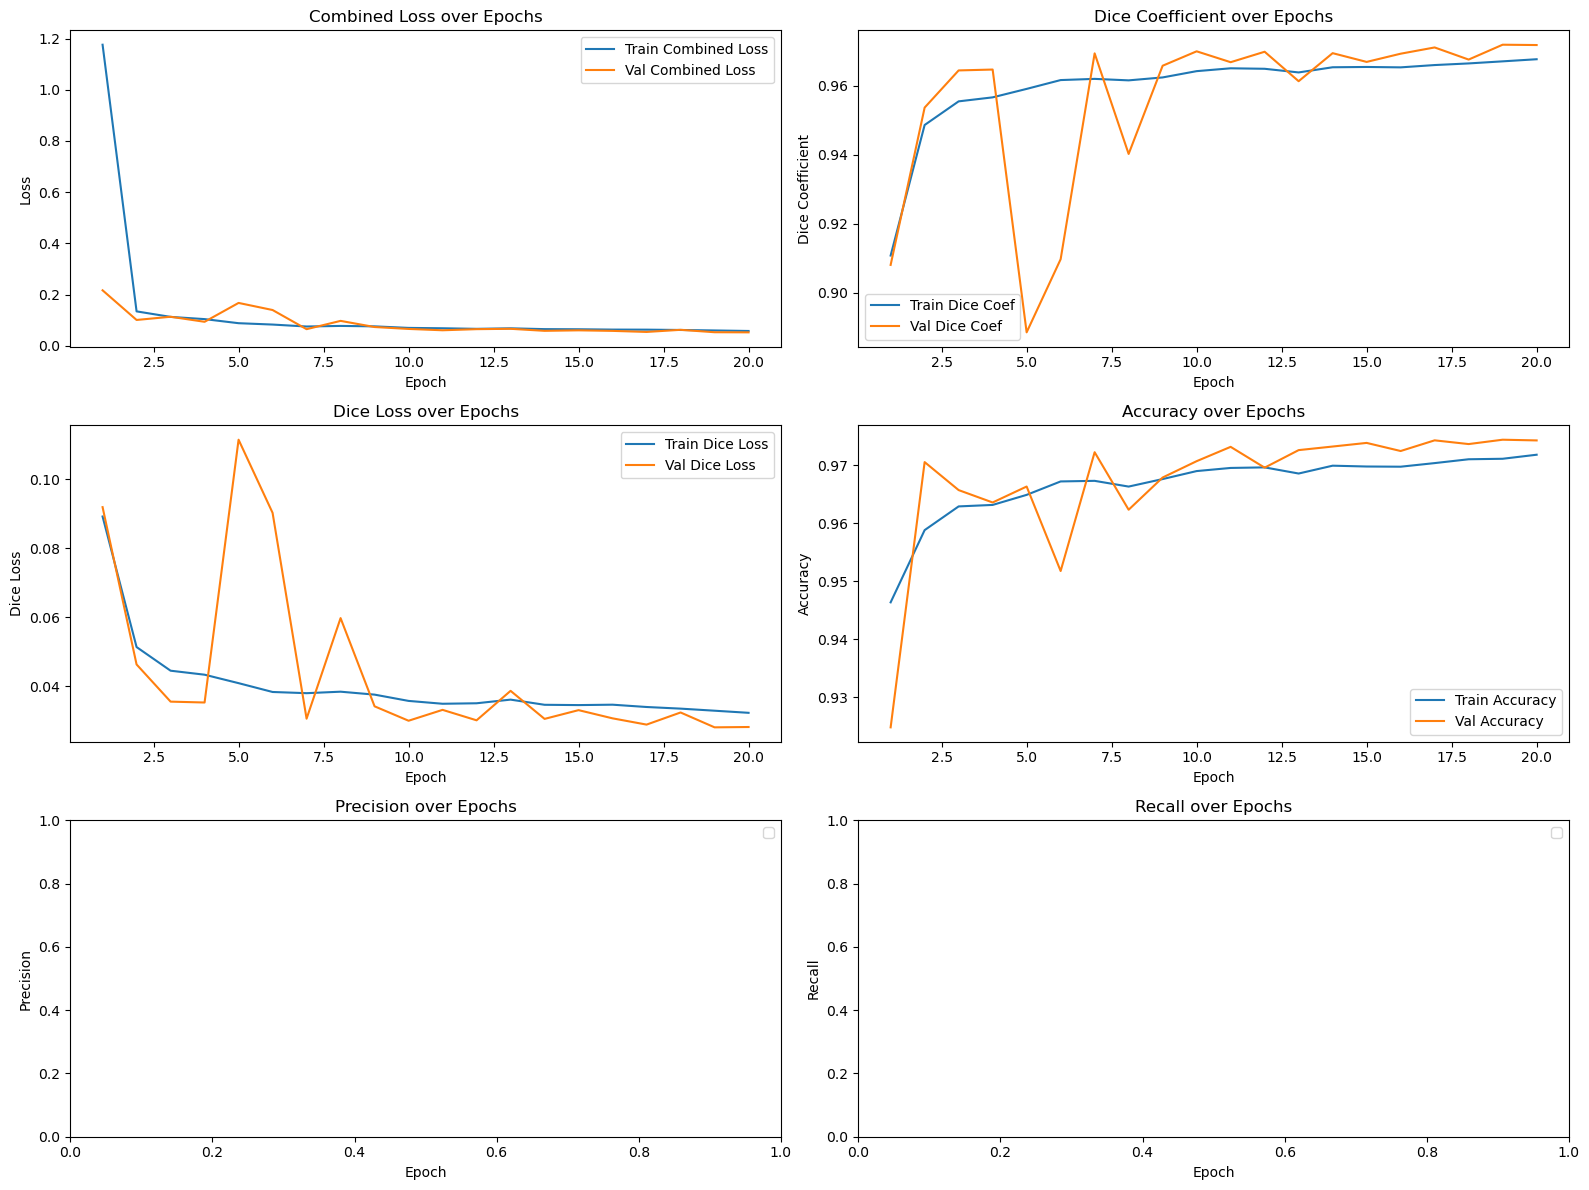


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_06.5_2025-03-11-23-19\Model_Data
63/63 [==============================] - 15s 235ms/step - loss: 0.0551 - accuracy: 0.9723 - precision_7: 0.9716 - recall_7: 0.9821 - dice_coef: 0.9699


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_06.5
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/acd15d4e2cf2409bb4e9e15d387202e5
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.9463695883750916, 0.9718055725097656)
COMET INFO:     batch_accuracy [880]             : (0.5510611534118652, 0.9880664348602295)
COMET INFO:     batch_dice_coef [880]            : (0.5467856526374817, 0.9807986617088318)
COMET INFO:     batch_loss [880]                 

In [13]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.4, 0.20, 0.40)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_06.5"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 20.0% low, 60.0% mid, 20.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 20.0% low, 60.0% mid, 20.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 20.0% low, 60.0% mid, 20.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_8"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_9 (InputLayer)           [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_264 (Conv2D)            (None, 512, 512, 16  432     

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/11937d1dea8449c19ad84c5cc7cce279

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.0867 - accuracy: 0.9365 - precision_8: 0.9233 - recall_8: 0.9500 - dice_coef: 0.8714   
Epoch 1: val_loss improved from inf to 0.75152, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 173s 386ms/step - loss: 1.0867 - accuracy: 0.9365 - precision_8: 0.9233 - recall_8: 0.9500 - dice_coef: 0.8714 - val_loss: 0.7515 - val_accuracy: 0.8515 - val_precision_8: 0.7639 - val_recall_8: 0.9980 - val_dice_coef: 0.8419
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1628 - accuracy: 0.9503 - precision_8: 0.9471 - recall_8: 0.9524 - dice_coef: 0.9256  
Epoch 2: val_loss did not improve from 0.75152
Epoch 2: learning_rate = 0.000954
438/438 [==============================] - 168s 384ms/step - loss: 0.1628 - accuracy: 0.9503 - precision_8: 0.9471 - re

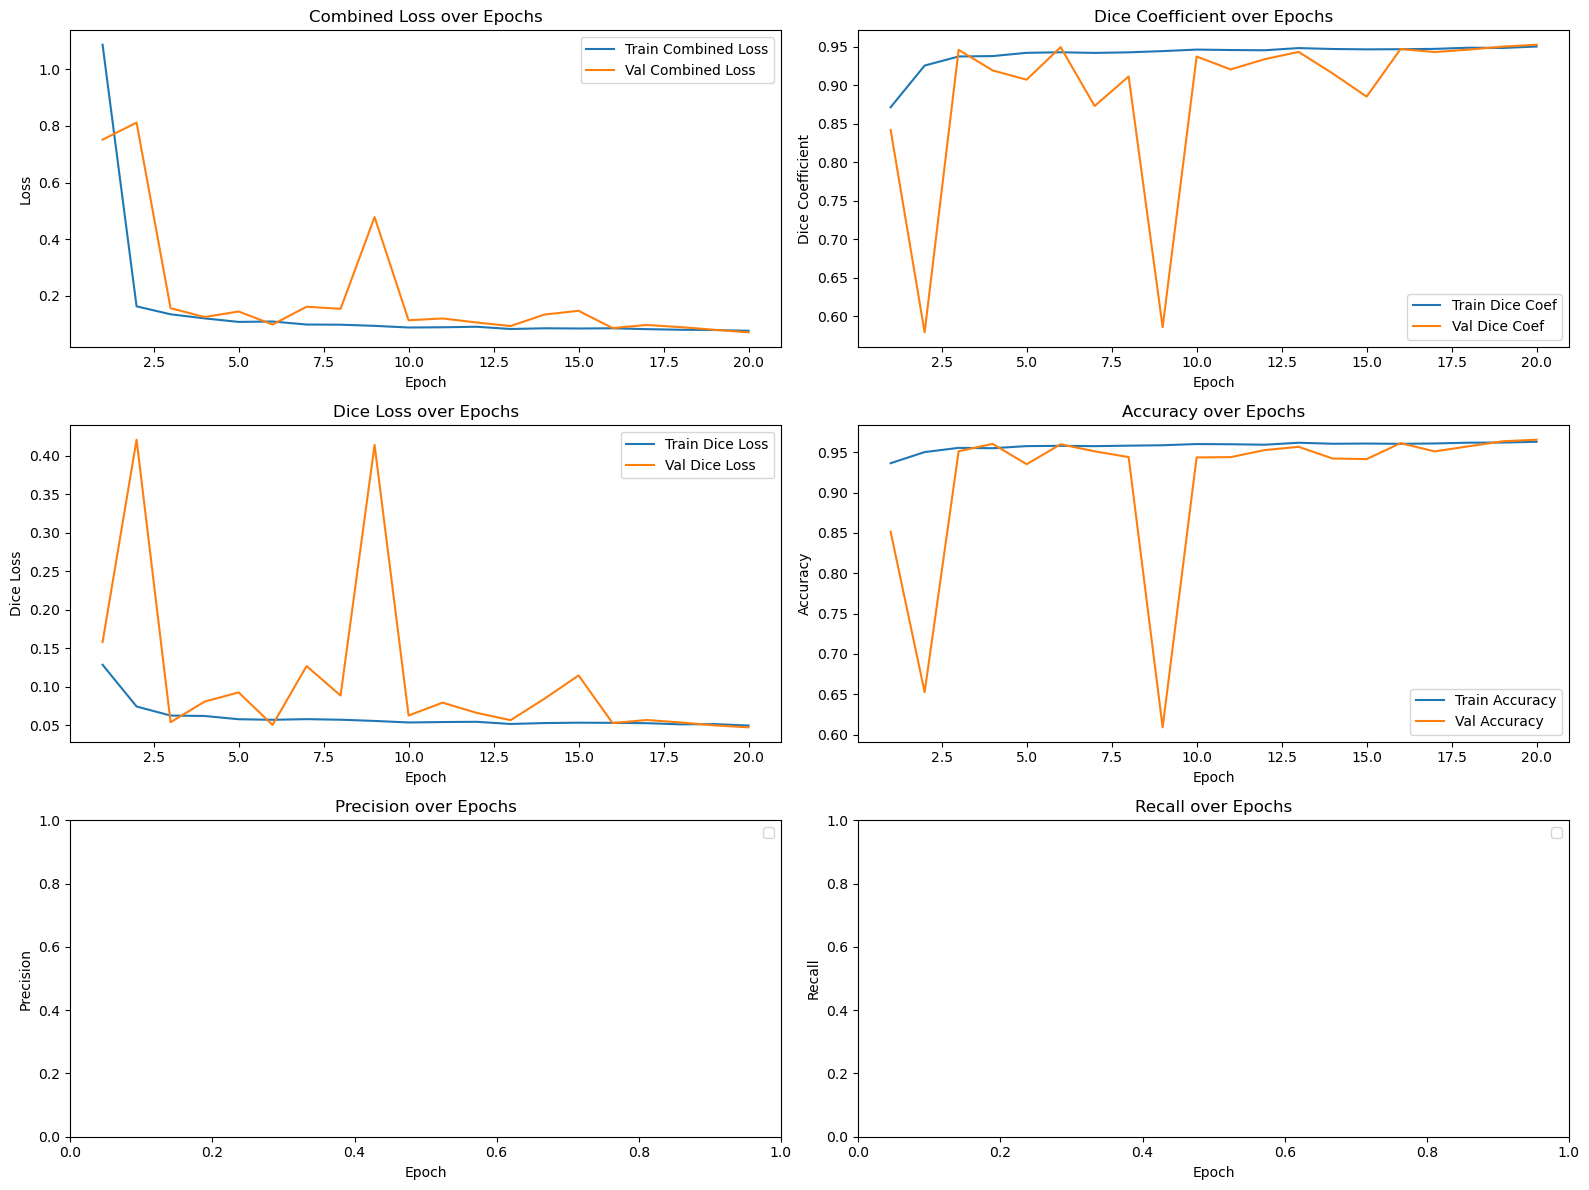


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_06.6_2025-03-12-00-17\Model_Data
63/63 [==============================] - 12s 187ms/step - loss: 0.0750 - accuracy: 0.9637 - precision_8: 0.9547 - recall_8: 0.9718 - dice_coef: 0.9500


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_06.6
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/11937d1dea8449c19ad84c5cc7cce279
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.9364981055259705, 0.9630606174468994)
COMET INFO:     batch_accuracy [880]             : (0.5392398834228516, 0.9702754020690918)
COMET INFO:     batch_dice_coef [880]            : (0.5918734669685364, 0.9595149755477905)
COMET INFO:     batch_loss [880]                 

In [14]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.6, 0.20, 0.20)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_06.6"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 30.0% low, 60.0% mid, 10.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 30.0% low, 60.0% mid, 10.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 30.0% low, 60.0% mid, 10.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_9"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_10 (InputLayer)          [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_297 (Conv2D)            (None, 512, 512, 16  432     

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/31677a6186c241a9945d0898f61d55b1

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.1170 - accuracy: 0.9432 - precision_9: 0.9210 - recall_9: 0.9361 - dice_coef: 0.8809   
Epoch 1: val_loss improved from inf to 0.15912, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 173s 387ms/step - loss: 1.1170 - accuracy: 0.9432 - precision_9: 0.9210 - recall_9: 0.9361 - dice_coef: 0.8809 - val_loss: 0.1591 - val_accuracy: 0.9609 - val_precision_9: 0.9624 - val_recall_9: 0.9337 - val_dice_coef: 0.8909
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1421 - accuracy: 0.9554 - precision_9: 0.9380 - recall_9: 0.9498 - dice_coef: 0.9204  
Epoch 2: val_loss improved from 0.15912 to 0.13381, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras
Epoch 2

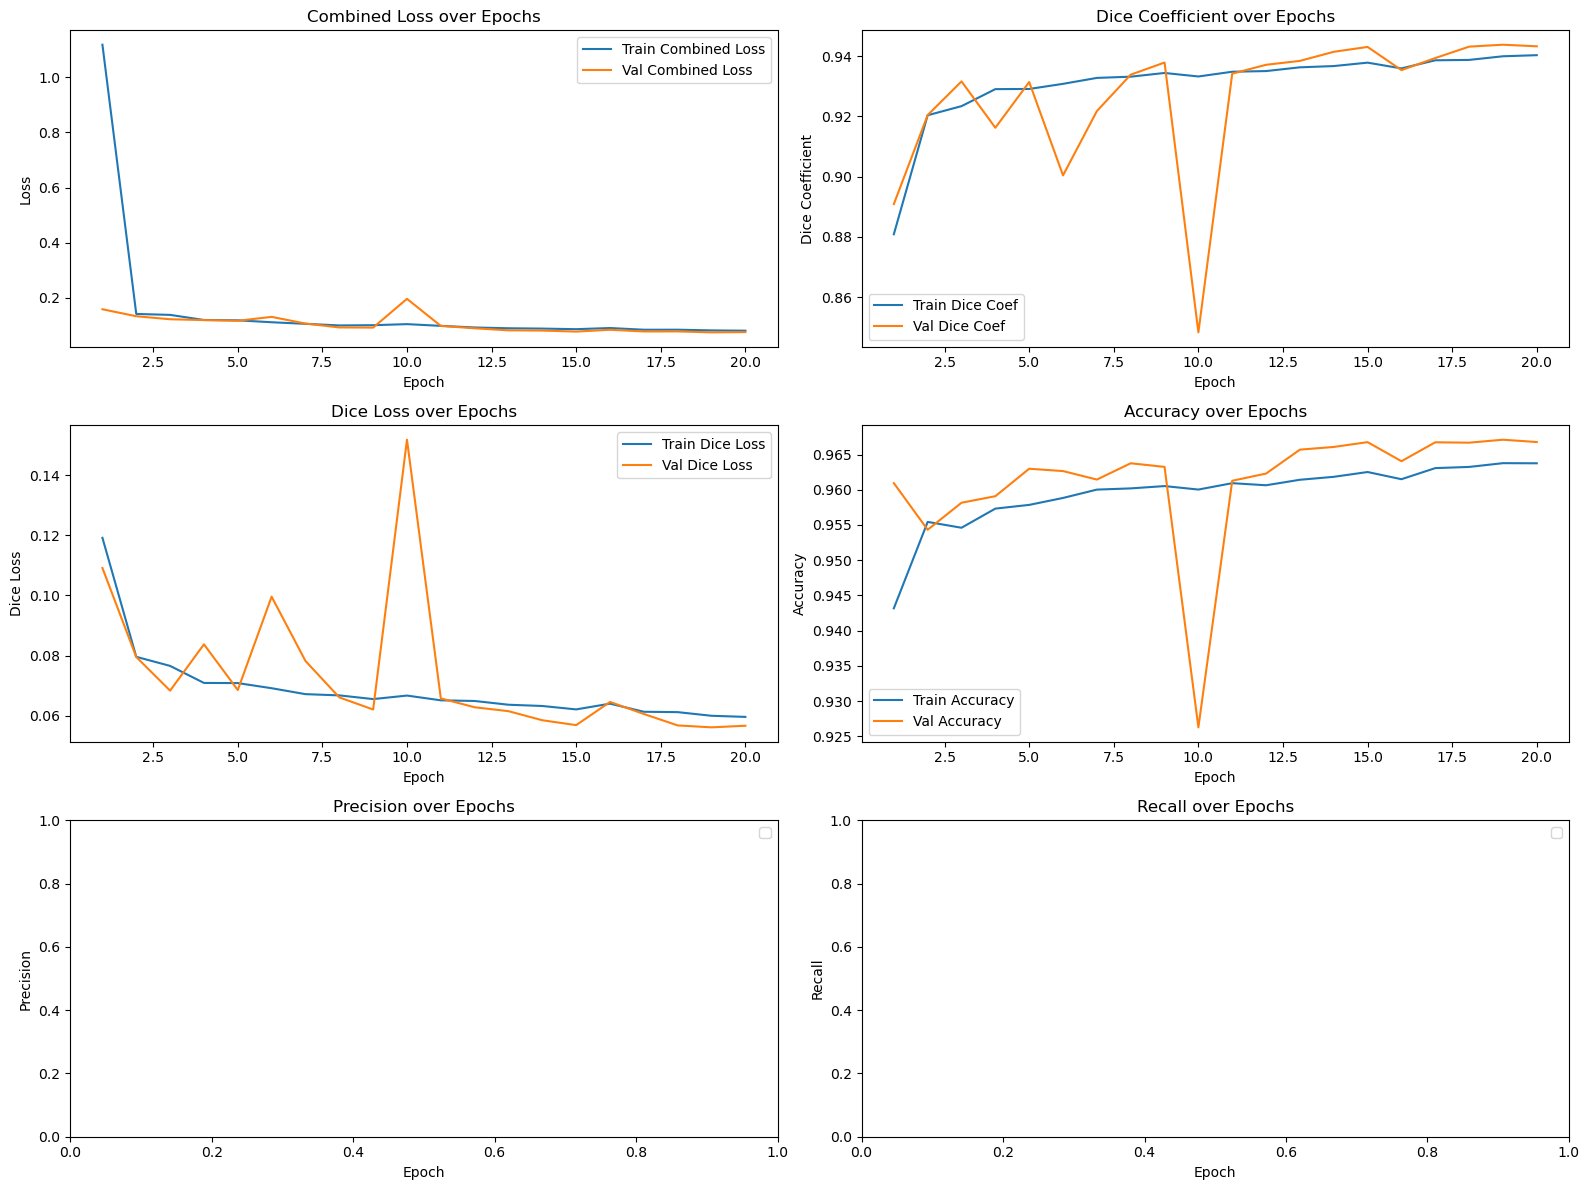


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_06.7_2025-03-12-01-15\Model_Data
63/63 [==============================] - 11s 170ms/step - loss: 0.0808 - accuracy: 0.9641 - precision_9: 0.9570 - recall_9: 0.9504 - dice_coef: 0.9406


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_06.7
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/31677a6186c241a9945d0898f61d55b1
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                    : (0.9431700110435486, 0.9637725949287415)
COMET INFO:     batch_accuracy [880]             : (0.47464776039123535, 0.982978343963623)
COMET INFO:     batch_dice_coef [880]            : (0.5029295086860657, 0.9655985832214355)
COMET INFO:     batch_loss [880]                 

In [15]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.6, 0.30, 0.10)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_06.7"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)


Sampling training with 10.0% low, 60.0% mid, 30.0% high tiles:
Total training tiles selected: 7000

Sampling validation with 10.0% low, 60.0% mid, 30.0% high tiles:
Total validation tiles selected: 2000

Sampling testing with 10.0% low, 60.0% mid, 30.0% high tiles:
Total testing tiles selected: 1000

Final counts:

Number of training pairs: 7000
Number of validation pairs: 2000
Number of testing pairs: 1000
Model summary:
Model: "model_10"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_11 (InputLayer)          [(None, 512, 512, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_330 (Conv2D)            (None, 512, 512, 16  432    

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/reversedpuppy/unet-snow-model/75a9ea3d2574410b902a89df8ce55709

COMET WARNING: tensorflow datasets are not currently supported for gradient and activation auto-logging


Training with batch size: 16
Number of epochs: 20
Steps per epoch (auto): 438
Validation steps (auto): 125
Epoch 1/20


COMET WARNING: Unknown error exporting current conda environment
COMET WARNING: Unknown error retrieving Conda package as an explicit file
COMET WARNING: Unknown error retrieving Conda information


438/438 [==============================] - ETA: 0s - loss: 1.1622 - accuracy: 0.9416 - precision_10: 0.9498 - recall_10: 0.9515 - dice_coef: 0.8958   
Epoch 1: val_loss improved from inf to 0.53877, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_01.keras
Epoch 1: learning_rate = 0.000977
438/438 [==============================] - 169s 378ms/step - loss: 1.1622 - accuracy: 0.9416 - precision_10: 0.9498 - recall_10: 0.9515 - dice_coef: 0.8958 - val_loss: 0.5388 - val_accuracy: 0.6677 - val_precision_10: 0.6348 - val_recall_10: 0.9996 - val_dice_coef: 0.7791
Epoch 2/20
438/438 [==============================] - ETA: 0s - loss: 0.1741 - accuracy: 0.9471 - precision_10: 0.9504 - recall_10: 0.9607 - dice_coef: 0.9353  
Epoch 2: val_loss improved from 0.53877 to 0.16194, saving model to C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\checkpoints\unet_epoch_02.keras

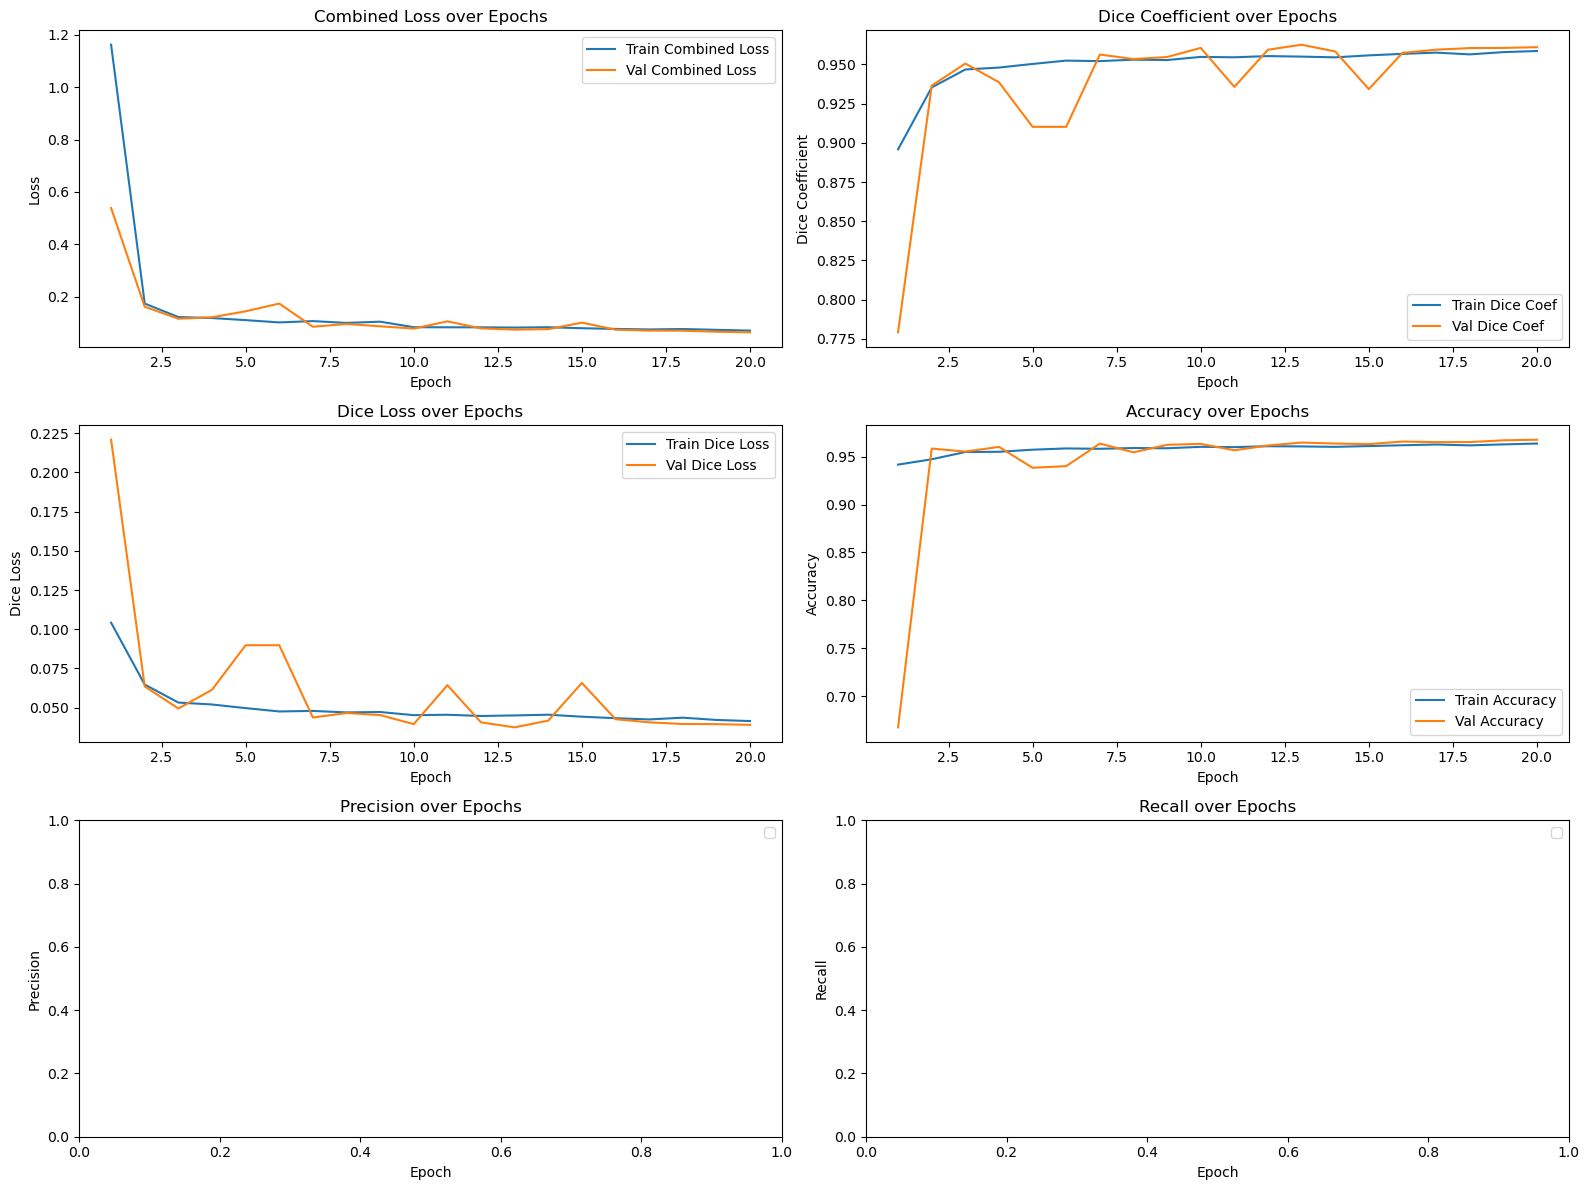


Model and history saved in: C:\Users\jaydb\OneDrive\Documents\Desktop\Github Repos\RMBL_SnowView\models\unet\models\unet\Previous\Model_06.8_2025-03-12-02-13\Model_Data
63/63 [==============================] - 11s 163ms/step - loss: 0.0686 - accuracy: 0.9652 - precision_10: 0.9677 - recall_10: 0.9731 - dice_coef: 0.9591


COMET WARNING: The given value of the metric test_precision was None; ignoring
COMET WARNING: The given value of the metric test_recall was None; ignoring
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Model_06.8
COMET INFO:     url                   : https://www.comet.com/reversedpuppy/unet-snow-model/75a9ea3d2574410b902a89df8ce55709
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     accuracy [20]                     : (0.9415815472602844, 0.9635377526283264)
COMET INFO:     batch_accuracy [880]              : (0.6078088283538818, 0.9809012413024902)
COMET INFO:     batch_dice_coef [880]             : (0.5061403512954712, 0.9749934077262878)
COMET INFO:     batch_loss [880]              

In [16]:
max_training_tiles = 7000
max_validation_tiles = 2000
max_testing_tiles = 1000

low = low_bin.copy()
mid = mid_bin.copy()
high = high_bin.copy()

mid_low_high_ratio_distribution = (0.6, 0.10, 0.30)  # (mid, low, high)     

BATCH_SIZE = 16
EPOCHS = 20
experiment_name = "Model_06.8"

# Run training using the aggregated sites and new target tile numbers.
model, history, eval_results = run_unet_training(
    folder_path=folder_path,
    sites=sites,
    max_training_tiles=max_training_tiles,
    max_validation_tiles=max_validation_tiles,
    max_testing_tiles=max_testing_tiles,
    mid_low_high_ratio_distribution=mid_low_high_ratio_distribution,
    snow_vs_notsnow_ratio_distribution=snow_vs_notsnow_ratio_distribution,
    low_bin=low,
    mid_bin=mid,
    high_bin=high,
    img_height=IMG_HEIGHT,
    img_width=IMG_WIDTH,
    img_channels=IMG_CHANNELS,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    comet_api_key=comet_api_key,
    comet_project_name=comet_project_name,
    comet_workspace=comet_workspace,
    model_instance_name=experiment_name
)